In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import StrMethodFormatter

sns.set_theme(style="whitegrid")

In [ ]:
file_path = "/content/personal_purchase_scenario_results.csv"

price_results = pd.read_csv(file_path)

price_results.head()

,analysis_model,mileage_5k,vehicle_age,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,sample_size,minimum_age,maximum_age,minimum_mileage,maximum_mileage,age_supported,mileage_supported,support_status
0,3 Series,12,3,37448.542187,1348.755486,34805.030011,40092.054363,30606.015789,44291.068585,22,1,6,370,146574,True,True,Within observed range
1,A4,12,3,31713.098418,904.755164,29939.810882,33486.385955,25157.447453,38268.749384,22,2,6,1975,107222,True,True,Within observed range
2,A5 Sportback,12,3,37855.412441,366.694588,37136.704256,38574.120627,31503.361407,44207.463476,14,2,6,27837,115327,True,True,Within observed range
3,Accord Hybrid,12,3,32535.573044,547.809397,31461.886356,33609.259733,26133.634745,38937.511344,24,0,3,402,144795,True,True,Within observed range
4,C300,12,3,40104.054721,1052.353034,38041.480675,42166.628766,33464.309049,46743.800392,14,1,4,5468,127233,True,True,Within observed range


In [ ]:
decision_df = price_results[
    [
        "analysis_model",
        "mean",
        "mean_ci_lower",
        "mean_ci_upper",
        "sample_size",
        "support_status"
    ]
].copy()

decision_df = decision_df.rename(
    columns={
        "mean": "predicted_price",
        "mean_ci_lower": "price_ci_lower",
        "mean_ci_upper": "price_ci_upper"
    }
)

decision_df[
    [
        "predicted_price",
        "price_ci_lower",
        "price_ci_upper"
    ]
] = decision_df[
    [
        "predicted_price",
        "price_ci_lower",
        "price_ci_upper"
    ]
].round(0)

decision_df.sort_values(
    "predicted_price",
    ascending=True
)

,analysis_model,predicted_price,price_ci_lower,price_ci_upper,sample_size,support_status
7,Elantra,18061.0,15957.0,20164.0,18,Within observed range
8,Elantra N Line,18887.0,13485.0,24288.0,2,Extrapolated
12,Sonata,22880.0,21303.0,24456.0,17,Extrapolated
6,Civic Hybrid,24632.0,22980.0,26285.0,20,Extrapolated
13,Sonata N Line,24679.0,22955.0,26404.0,7,Extrapolated
9,G70 2.0T,31008.0,29086.0,32930.0,3,Within observed range
1,A4,31713.0,29940.0,33486.0,22,Within observed range
3,Accord Hybrid,32536.0,31462.0,33609.0,24,Within observed range
5,Camry Hybrid,34873.0,33528.0,36217.0,21,Within observed range
10,G70 2.5T,35954.0,31822.0,40087.0,3,Extrapolated


In [ ]:
highest_price = decision_df["predicted_price"].max()
lowest_price = decision_df["predicted_price"].min()

decision_df["purchase_value_score"] = (
    10
    * (
        highest_price
        - decision_df["predicted_price"]
    )
    / (
        highest_price
        - lowest_price
    )
)

decision_df["purchase_value_score"] = (
    decision_df["purchase_value_score"].round(2)
)

decision_df[
    [
        "analysis_model",
        "predicted_price",
        "purchase_value_score",
        "support_status"
    ]
].sort_values(
    "purchase_value_score",
    ascending=False
)

,analysis_model,predicted_price,purchase_value_score,support_status
7,Elantra,18061.0,10.00,Within observed range
8,Elantra N Line,18887.0,9.63,Extrapolated
12,Sonata,22880.0,7.81,Extrapolated
6,Civic Hybrid,24632.0,7.02,Extrapolated
13,Sonata N Line,24679.0,7.00,Extrapolated
9,G70 2.0T,31008.0,4.13,Within observed range
1,A4,31713.0,3.81,Within observed range
3,Accord Hybrid,32536.0,3.43,Within observed range
5,Camry Hybrid,34873.0,2.37,Within observed range
10,G70 2.5T,35954.0,1.88,Extrapolated


## Insurance Affordability

In [ ]:
insurance_df = pd.DataFrame({
    "analysis_model": decision_df["analysis_model"],
    "insurance_risk_level": np.nan,
    "insurance_source": "IBC How Cars Measure Up",
    "insurance_notes": ""
})

insurance_df.sort_values("analysis_model")

,analysis_model,insurance_risk_level,insurance_source,insurance_notes
0,3 Series,NaN,IBC How Cars Measure Up,
1,A4,NaN,IBC How Cars Measure Up,
2,A5 Sportback,NaN,IBC How Cars Measure Up,
3,Accord Hybrid,NaN,IBC How Cars Measure Up,
4,C300,NaN,IBC How Cars Measure Up,
5,Camry Hybrid,NaN,IBC How Cars Measure Up,
6,Civic Hybrid,NaN,IBC How Cars Measure Up,
7,Elantra,NaN,IBC How Cars Measure Up,
8,Elantra N Line,NaN,IBC How Cars Measure Up,
9,G70 2.0T,NaN,IBC How Cars Measure Up,


In [ ]:
insurance_df[
    [
        "collision_vs_average",
        "comprehensive_vs_average",
        "dcpd_vs_average",
        "accident_benefits_vs_average",
        "theft_frequency_vs_average"
    ]
] = np.nan

In [ ]:
sonata_values = [252, 96, 331, 127, 348]

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["Sonata", "Sonata N Line"]
    ),
    [
        "collision_vs_average",
        "comprehensive_vs_average",
        "dcpd_vs_average",
        "accident_benefits_vs_average",
        "theft_frequency_vs_average"
    ]
] = sonata_values

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["Sonata", "Sonata N Line"]
    ),
    "insurance_notes"
] = "2023 Sonata; IBC does not separate N Line trim."

insurance_df[
    insurance_df["analysis_model"].isin(
        ["Sonata", "Sonata N Line"]
    )
]

,analysis_model,insurance_risk_level,insurance_source,insurance_notes,collision_vs_average,comprehensive_vs_average,dcpd_vs_average,accident_benefits_vs_average,theft_frequency_vs_average
12,Sonata,NaN,IBC How Cars Measure Up,2023 Sonata; IBC does not separate N Line trim.,252.0,96.0,331.0,127.0,348.0
13,Sonata N Line,NaN,IBC How Cars Measure Up,2023 Sonata; IBC does not separate N Line trim.,252.0,96.0,331.0,127.0,348.0


In [ ]:
insurance_df["insurance_model_year"] = np.nan

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["Sonata", "Sonata N Line"]
    ),
    "insurance_model_year"
] = 2023

a4_values = [165, 8, 169, 38, -99]

insurance_df.loc[
    insurance_df["analysis_model"] == "A4",
    [
        "collision_vs_average",
        "comprehensive_vs_average",
        "dcpd_vs_average",
        "accident_benefits_vs_average",
        "theft_frequency_vs_average"
    ]
] = a4_values

insurance_df.loc[
    insurance_df["analysis_model"] == "A4",
    "insurance_model_year"
] = 2021

insurance_df.loc[
    insurance_df["analysis_model"] == "A4",
    "insurance_notes"
] = "Latest model year available in IBC was 2021."

g70_values = [46, -2, 189, 10, -56]

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["G70 2.0T", "G70 2.5T", "G70 3.3T"]
    ),
    [
        "collision_vs_average",
        "comprehensive_vs_average",
        "dcpd_vs_average",
        "accident_benefits_vs_average",
        "theft_frequency_vs_average"
    ]
] = g70_values

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["G70 2.0T", "G70 2.5T", "G70 3.3T"]
    ),
    "insurance_model_year"
] = 2023

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["G70 2.0T", "G70 2.5T", "G70 3.3T"]
    ),
    "insurance_notes"
] = "2023 G70 AWD; IBC does not separate engine variants."

insurance_df[
    insurance_df[
        "analysis_model"
    ].isin(
        [
            "Sonata",
            "Sonata N Line",
            "A4",
            "G70 2.0T",
            "G70 2.5T",
            "G70 3.3T"
        ]
    )
]

,analysis_model,insurance_risk_level,insurance_source,insurance_notes,collision_vs_average,comprehensive_vs_average,dcpd_vs_average,accident_benefits_vs_average,theft_frequency_vs_average,insurance_model_year
1,A4,NaN,IBC How Cars Measure Up,Latest model year available in IBC was 2021.,165.0,8.0,169.0,38.0,-99.0,2021.0
9,G70 2.0T,NaN,IBC How Cars Measure Up,2023 G70 AWD; IBC does not separate engine var...,46.0,-2.0,189.0,10.0,-56.0,2023.0
10,G70 2.5T,NaN,IBC How Cars Measure Up,2023 G70 AWD; IBC does not separate engine var...,46.0,-2.0,189.0,10.0,-56.0,2023.0
11,G70 3.3T,NaN,IBC How Cars Measure Up,2023 G70 AWD; IBC does not separate engine var...,46.0,-2.0,189.0,10.0,-56.0,2023.0
12,Sonata,NaN,IBC How Cars Measure Up,2023 Sonata; IBC does not separate N Line trim.,252.0,96.0,331.0,127.0,348.0,2023.0
13,Sonata N Line,NaN,IBC How Cars Measure Up,2023 Sonata; IBC does not separate N Line trim.,252.0,96.0,331.0,127.0,348.0,2023.0


In [ ]:
insurance_metric_columns = [
    "collision_vs_average",
    "comprehensive_vs_average",
    "dcpd_vs_average",
    "accident_benefits_vs_average",
    "theft_frequency_vs_average"
]

def record_insurance(models, year, values, notes):
    mask = insurance_df["analysis_model"].isin(models)

    insurance_df.loc[
        mask,
        insurance_metric_columns
    ] = values

    insurance_df.loc[
        mask,
        "insurance_model_year"
    ] = year

    insurance_df.loc[
        mask,
        "insurance_notes"
    ] = notes

In [ ]:
record_insurance(
    models=["3 Series"],
    year=2023,
    values=[144, 40, 185, 327, -22],
    notes="2023 BMW 330i 4DR AWD."
)

record_insurance(
    models=["C300"],
    year=2020,
    values=[159, 160, 192, 92, 302],
    notes="Latest model year available in IBC was 2020; C300W/C350 4MATIC 4DR."
)

record_insurance(
    models=["A5 Sportback"],
    year=2021,
    values=[222, 12, 284, -24, -99],
    notes="Latest model year available in IBC was 2021; A5 Quattro 4DR Sportback."
)

insurance_df[
    insurance_df["analysis_model"].isin(
        [
            "3 Series",
            "C300",
            "A5 Sportback"
        ]
    )
][
    [
        "analysis_model",
        "insurance_model_year",
        *insurance_metric_columns,
        "insurance_notes"
    ]
]

,analysis_model,insurance_model_year,collision_vs_average,comprehensive_vs_average,dcpd_vs_average,accident_benefits_vs_average,theft_frequency_vs_average,insurance_notes
0,3 Series,2023.0,144.0,40.0,185.0,327.0,-22.0,2023 BMW 330i 4DR AWD.
2,A5 Sportback,2021.0,222.0,12.0,284.0,-24.0,-99.0,Latest model year available in IBC was 2021; A...
4,C300,2020.0,159.0,160.0,192.0,92.0,302.0,Latest model year available in IBC was 2020; C...


In [ ]:
insurance_df["insurance_data_quality"] = np.where(
    insurance_df["collision_vs_average"].notna(),
    "Direct",
    "Missing"
)

record_insurance(
    models=["Accord Hybrid"],
    year=2019,
    values=[71, 101, 152, -14, 209],
    notes="Latest HEV model year available in IBC was 2019; older generation."
)

insurance_df.loc[
    insurance_df["analysis_model"] == "Accord Hybrid",
    "insurance_data_quality"
] = "Direct"

record_insurance(
    models=["Camry Hybrid"],
    year=2023,
    values=[126, -4, 240, 290, 14],
    notes="2023 Camry HEV 4DR."
)

insurance_df.loc[
    insurance_df["analysis_model"] == "Camry Hybrid",
    "insurance_data_quality"
] = "Direct"

record_insurance(
    models=["Civic Hybrid"],
    year=2024,
    values=[199, 46, 222, 130, 95],
    notes="Proxy: 2024 gasoline Civic 4DR used because current-generation Civic Hybrid data were unavailable."
)

insurance_df.loc[
    insurance_df["analysis_model"] == "Civic Hybrid",
    "insurance_data_quality"
] = "Proxy"

insurance_df[
    insurance_df["analysis_model"].isin(
        [
            "Accord Hybrid",
            "Civic Hybrid",
            "Camry Hybrid"
        ]
    )
][
    [
        "analysis_model",
        "insurance_model_year",
        *insurance_metric_columns,
        "insurance_data_quality",
        "insurance_notes"
    ]
]

,analysis_model,insurance_model_year,collision_vs_average,comprehensive_vs_average,dcpd_vs_average,accident_benefits_vs_average,theft_frequency_vs_average,insurance_data_quality,insurance_notes
3,Accord Hybrid,2019.0,71.0,101.0,152.0,-14.0,209.0,Direct,Latest HEV model year available in IBC was 201...
5,Camry Hybrid,2023.0,126.0,-4.0,240.0,290.0,14.0,Direct,2023 Camry HEV 4DR.
6,Civic Hybrid,2024.0,199.0,46.0,222.0,130.0,95.0,Proxy,Proxy: 2024 gasoline Civic 4DR used because cu...


In [ ]:
record_insurance(
    models=["Elantra", "Elantra N Line"],
    year=2024,
    values=[210, 37, 283, 172, -23],
    notes="2024 Elantra 4DR; IBC does not separate N Line trim."
)

insurance_df.loc[
    insurance_df["analysis_model"].isin(
        ["Elantra", "Elantra N Line"]
    ),
    "insurance_data_quality"
] = "Direct"

In [ ]:
insurance_df[
    insurance_metric_columns
].isna().sum()

,0
collision_vs_average,0
comprehensive_vs_average,0
dcpd_vs_average,0
accident_benefits_vs_average,0
theft_frequency_vs_average,0


In [ ]:
insurance_df["insurance_risk_index"] = (
    insurance_df[
        insurance_metric_columns
    ].mean(axis=1)
)

insurance_df[
    [
        "analysis_model",
        "insurance_risk_index",
        "insurance_data_quality"
    ]
].sort_values(
    "insurance_risk_index",
    ascending=True
)

,analysis_model,insurance_risk_index,insurance_data_quality
10,G70 2.5T,37.4,Direct
11,G70 3.3T,37.4,Direct
9,G70 2.0T,37.4,Direct
1,A4,56.2,Direct
2,A5 Sportback,79.0,Direct
3,Accord Hybrid,103.8,Direct
5,Camry Hybrid,133.2,Direct
0,3 Series,134.8,Direct
7,Elantra,135.8,Direct
8,Elantra N Line,135.8,Direct


In [ ]:
highest_risk = insurance_df[
    "insurance_risk_index"
].max()

lowest_risk = insurance_df[
    "insurance_risk_index"
].min()

insurance_df["insurance_affordability_score"] = (
    10
    * (
        highest_risk
        - insurance_df["insurance_risk_index"]
    )
    / (
        highest_risk
        - lowest_risk
    )
).round(2)

insurance_df[
    [
        "analysis_model",
        "insurance_model_year",
        "insurance_risk_index",
        "insurance_affordability_score",
        "insurance_data_quality"
    ]
].sort_values(
    "insurance_affordability_score",
    ascending=False
)

,analysis_model,insurance_model_year,insurance_risk_index,insurance_affordability_score,insurance_data_quality
10,G70 2.5T,2023.0,37.4,10.00,Direct
9,G70 2.0T,2023.0,37.4,10.00,Direct
11,G70 3.3T,2023.0,37.4,10.00,Direct
1,A4,2021.0,56.2,9.03,Direct
2,A5 Sportback,2021.0,79.0,7.85,Direct
3,Accord Hybrid,2019.0,103.8,6.57,Direct
5,Camry Hybrid,2023.0,133.2,5.05,Direct
0,3 Series,2023.0,134.8,4.96,Direct
8,Elantra N Line,2024.0,135.8,4.91,Direct
7,Elantra,2024.0,135.8,4.91,Direct


In [ ]:
decision_df = decision_df.merge(
    insurance_df[
        [
            "analysis_model",
            "insurance_risk_index",
            "insurance_affordability_score",
            "insurance_model_year",
            "insurance_data_quality",
            "insurance_notes"
        ]
    ],
    on="analysis_model",
    how="left"
)

decision_df[
    [
        "analysis_model",
        "purchase_value_score",
        "insurance_affordability_score"
    ]
].sort_values(
    "insurance_affordability_score",
    ascending=False
)

,analysis_model,purchase_value_score,insurance_affordability_score
10,G70 2.5T,1.88,10.00
9,G70 2.0T,4.13,10.00
11,G70 3.3T,0.70,10.00
1,A4,3.81,9.03
2,A5 Sportback,1.02,7.85
3,Accord Hybrid,3.43,6.57
5,Camry Hybrid,2.37,5.05
0,3 Series,1.20,4.96
8,Elantra N Line,9.63,4.91
7,Elantra,10.00,4.91


In [ ]:
reliability_df = pd.DataFrame({
    "analysis_model": decision_df["analysis_model"].drop_duplicates(),
    "maintenance_cost_5yr_usd": np.nan,
    "major_repair_probability_5yr": np.nan,
    "reliability_data_quality": "",
    "reliability_notes": "",
    "reliability_source": "CarEdge"
})

reliability_df.sort_values("analysis_model")

,analysis_model,maintenance_cost_5yr_usd,major_repair_probability_5yr,reliability_data_quality,reliability_notes,reliability_source
0,3 Series,NaN,NaN,,,CarEdge
1,A4,NaN,NaN,,,CarEdge
2,A5 Sportback,NaN,NaN,,,CarEdge
3,Accord Hybrid,NaN,NaN,,,CarEdge
4,C300,NaN,NaN,,,CarEdge
5,Camry Hybrid,NaN,NaN,,,CarEdge
6,Civic Hybrid,NaN,NaN,,,CarEdge
7,Elantra,NaN,NaN,,,CarEdge
8,Elantra N Line,NaN,NaN,,,CarEdge
9,G70 2.0T,NaN,NaN,,,CarEdge


In [ ]:
def record_reliability(
    models,
    maintenance_cost,
    major_repair_probability,
    notes,
    data_quality="Direct"
):
    mask = reliability_df["analysis_model"].isin(models)

    reliability_df.loc[
        mask, "maintenance_cost_5yr_usd"
    ] = maintenance_cost

    reliability_df.loc[
        mask, "major_repair_probability_5yr"
    ] = major_repair_probability

    reliability_df.loc[
        mask, "reliability_data_quality"
    ] = data_quality

    reliability_df.loc[
        mask, "reliability_notes"
    ] = notes

In [ ]:
record_reliability(
    models=["Sonata", "Sonata N Line"],
    maintenance_cost=2048,
    major_repair_probability=8.56,
    notes="CarEdge model-level Sonata estimate; N Line is not separated."
)

reliability_df[
    reliability_df["analysis_model"].isin(
        ["Sonata", "Sonata N Line"]
    )
]

,analysis_model,maintenance_cost_5yr_usd,major_repair_probability_5yr,reliability_data_quality,reliability_notes,reliability_source
12,Sonata,2048.0,8.56,Direct,CarEdge model-level Sonata estimate; N Line is...,CarEdge
13,Sonata N Line,2048.0,8.56,Direct,CarEdge model-level Sonata estimate; N Line is...,CarEdge


In [ ]:
reliability_df = reliability_df.drop(
    columns=["major_repair_probability_5yr"]
)

reliability_df["jd_power_reliability_score"] = np.nan
reliability_df["jd_power_model_year"] = np.nan

In [ ]:
def record_reliability(
    models,
    maintenance_cost,
    reliability_score,
    jd_power_year,
    notes,
    data_quality="Direct"
):
    mask = reliability_df["analysis_model"].isin(models)

    reliability_df.loc[
        mask, "maintenance_cost_5yr_usd"
    ] = maintenance_cost

    reliability_df.loc[
        mask, "jd_power_reliability_score"
    ] = reliability_score

    reliability_df.loc[
        mask, "jd_power_model_year"
    ] = jd_power_year

    reliability_df.loc[
        mask, "reliability_data_quality"
    ] = data_quality

    reliability_df.loc[
        mask, "reliability_notes"
    ] = notes

In [ ]:
record_reliability(
    models=["Sonata", "Sonata N Line"],
    maintenance_cost=2048,
    reliability_score=81,
    jd_power_year=2023,
    notes=(
        "CarEdge Sonata maintenance estimate and "
        "2023 J.D. Power Sonata reliability score; "
        "N Line is not separately rated."
    )
)

record_reliability(
    models=["G70 2.0T", "G70 2.5T", "G70 3.3T"],
    maintenance_cost=2352,
    reliability_score=84,
    jd_power_year=2023,
    notes=(
        "CarEdge G70 maintenance estimate and "
        "2023 J.D. Power G70 reliability score; "
        "engine variants are not separately rated."
    )
)

reliability_df[
    reliability_df["analysis_model"].isin([
        "Sonata",
        "Sonata N Line",
        "G70 2.0T",
        "G70 2.5T",
        "G70 3.3T"
    ])
]

,analysis_model,maintenance_cost_5yr_usd,reliability_data_quality,reliability_notes,reliability_source,jd_power_reliability_score,jd_power_model_year
9,G70 2.0T,2352.0,Direct,CarEdge G70 maintenance estimate and 2023 J.D....,CarEdge,84.0,2023.0
10,G70 2.5T,2352.0,Direct,CarEdge G70 maintenance estimate and 2023 J.D....,CarEdge,84.0,2023.0
11,G70 3.3T,2352.0,Direct,CarEdge G70 maintenance estimate and 2023 J.D....,CarEdge,84.0,2023.0
12,Sonata,2048.0,Direct,CarEdge Sonata maintenance estimate and 2023 J...,CarEdge,81.0,2023.0
13,Sonata N Line,2048.0,Direct,CarEdge Sonata maintenance estimate and 2023 J...,CarEdge,81.0,2023.0


In [ ]:
record_reliability(
    models=["3 Series"],
    maintenance_cost=4501,
    reliability_score=80,
    jd_power_year=2023,
    notes=(
        "CarEdge BMW 3 Series maintenance estimate and "
        "2023 J.D. Power 3 Series reliability score."
    )
)

record_reliability(
    models=["A4"],
    maintenance_cost=3049,
    reliability_score=77,
    jd_power_year=2023,
    notes=(
        "CarEdge Audi A4 maintenance estimate and "
        "2023 J.D. Power A4 reliability score."
    )
)

record_reliability(
    models=["A5 Sportback"],
    maintenance_cost=3092,
    reliability_score=76,
    jd_power_year=2023,
    notes=(
        "CarEdge Audi A5 Sportback maintenance estimate and "
        "2023 J.D. Power A5 reliability score."
    )
)

record_reliability(
    models=["C300"],
    maintenance_cost=np.nan,
    reliability_score=76,
    jd_power_year=2023,
    notes=(
        "2023 J.D. Power C-Class reliability score; "
        "comparable CarEdge five-year maintenance estimate unavailable."
    ),
    data_quality="Partial"
)

reliability_df[
    reliability_df["analysis_model"].isin([
        "3 Series",
        "A4",
        "A5 Sportback",
        "C300"
    ])
]

,analysis_model,maintenance_cost_5yr_usd,reliability_data_quality,reliability_notes,reliability_source,jd_power_reliability_score,jd_power_model_year
0,3 Series,4501.0,Direct,CarEdge BMW 3 Series maintenance estimate and ...,CarEdge,80.0,2023.0
1,A4,3049.0,Direct,CarEdge Audi A4 maintenance estimate and 2023 ...,CarEdge,77.0,2023.0
2,A5 Sportback,3092.0,Direct,CarEdge Audi A5 Sportback maintenance estimate...,CarEdge,76.0,2023.0
4,C300,NaN,Partial,2023 J.D. Power C-Class reliability score; com...,CarEdge,76.0,2023.0


In [ ]:
record_reliability(
    models=["Accord Hybrid"],
    maintenance_cost=1874,
    reliability_score=80,
    jd_power_year=2023,
    notes=(
        "Honda Accord model-level maintenance and reliability data "
        "used as a proxy for Accord Hybrid."
    ),
    data_quality="Proxy"
)

record_reliability(
    models=["Camry Hybrid"],
    maintenance_cost=1503,
    reliability_score=88,
    jd_power_year=2023,
    notes=(
        "Toyota Camry model-level maintenance and reliability data "
        "used as a proxy for Camry Hybrid."
    ),
    data_quality="Proxy"
)

record_reliability(
    models=["Civic Hybrid"],
    maintenance_cost=1786,
    reliability_score=82,
    jd_power_year=2024,
    notes=(
        "2024 gasoline Civic model-level maintenance and reliability "
        "data used as a proxy because current Civic Hybrid-specific "
        "data were unavailable."
    ),
    data_quality="Proxy"
)

reliability_df[
    reliability_df["analysis_model"].isin([
        "Accord Hybrid",
        "Camry Hybrid",
        "Civic Hybrid"
    ])
]

,analysis_model,maintenance_cost_5yr_usd,reliability_data_quality,reliability_notes,reliability_source,jd_power_reliability_score,jd_power_model_year
3,Accord Hybrid,1874.0,Proxy,Honda Accord model-level maintenance and relia...,CarEdge,80.0,2023.0
5,Camry Hybrid,1503.0,Proxy,Toyota Camry model-level maintenance and relia...,CarEdge,88.0,2023.0
6,Civic Hybrid,1786.0,Proxy,2024 gasoline Civic model-level maintenance an...,CarEdge,82.0,2024.0


In [ ]:
record_reliability(
    models=["Elantra"],
    maintenance_cost=1996,
    reliability_score=86,
    jd_power_year=2024,
    notes=(
        "CarEdge Elantra maintenance estimate and "
        "2024 J.D. Power Elantra reliability score."
    ),
    data_quality="Direct"
)

record_reliability(
    models=["Elantra N Line"],
    maintenance_cost=1996,
    reliability_score=86,
    jd_power_year=2024,
    notes=(
        "Elantra model-level maintenance and reliability data "
        "used as a proxy because N Line is not separately rated."
    ),
    data_quality="Proxy"
)

reliability_df["reliability_source"] = (
    "CarEdge + J.D. Power"
)

reliability_df[
    [
        "maintenance_cost_5yr_usd",
        "jd_power_reliability_score"
    ]
].isna().sum()

,0
maintenance_cost_5yr_usd,1
jd_power_reliability_score,0


In [ ]:
reliability_df[
    [
        "analysis_model",
        "maintenance_cost_5yr_usd",
        "jd_power_reliability_score",
        "jd_power_model_year",
        "reliability_data_quality"
    ]
].sort_values(
    "analysis_model"
)

,analysis_model,maintenance_cost_5yr_usd,jd_power_reliability_score,jd_power_model_year,reliability_data_quality
0,3 Series,4501.0,80.0,2023.0,Direct
1,A4,3049.0,77.0,2023.0,Direct
2,A5 Sportback,3092.0,76.0,2023.0,Direct
3,Accord Hybrid,1874.0,80.0,2023.0,Proxy
4,C300,NaN,76.0,2023.0,Partial
5,Camry Hybrid,1503.0,88.0,2023.0,Proxy
6,Civic Hybrid,1786.0,82.0,2024.0,Proxy
7,Elantra,1996.0,86.0,2024.0,Direct
8,Elantra N Line,1996.0,86.0,2024.0,Proxy
9,G70 2.0T,2352.0,84.0,2023.0,Direct


In [ ]:
luxury_family_costs = [
    4501,  # 3 Series
    3049,  # A4
    3092,  # A5 Sportback
    2352   # G70
]

c300_imputed_cost = np.median(luxury_family_costs)

c300_mask = (
    reliability_df["analysis_model"] == "C300"
)

reliability_df.loc[
    c300_mask,
    "maintenance_cost_5yr_usd"
] = c300_imputed_cost

reliability_df.loc[
    c300_mask,
    "reliability_data_quality"
] = "Imputed"

reliability_df.loc[
    c300_mask,
    "reliability_notes"
] = (
    "Five-year maintenance cost imputed using the median "
    "of comparable luxury model families: 3 Series, A4, "
    "A5 Sportback, and G70. Reliability score is direct "
    "2023 J.D. Power C-Class data."
)

reliability_df[
    reliability_df["analysis_model"] == "C300"
]

,analysis_model,maintenance_cost_5yr_usd,reliability_data_quality,reliability_notes,reliability_source,jd_power_reliability_score,jd_power_model_year
4,C300,3070.5,Imputed,Five-year maintenance cost imputed using the m...,CarEdge + J.D. Power,76.0,2023.0


In [ ]:
lowest_cost = reliability_df[
    "maintenance_cost_5yr_usd"
].min()

highest_cost = reliability_df[
    "maintenance_cost_5yr_usd"
].max()

lowest_reliability = reliability_df[
    "jd_power_reliability_score"
].min()

highest_reliability = reliability_df[
    "jd_power_reliability_score"
].max()


reliability_df["maintenance_affordability_score"] = (
    10
    * (
        highest_cost
        - reliability_df["maintenance_cost_5yr_usd"]
    )
    / (
        highest_cost
        - lowest_cost
    )
)


reliability_df["reliability_score_normalized"] = (
    10
    * (
        reliability_df["jd_power_reliability_score"]
        - lowest_reliability
    )
    / (
        highest_reliability
        - lowest_reliability
    )
)


reliability_df["reliability_maintenance_score"] = (
    0.60
    * reliability_df["maintenance_affordability_score"]
    +
    0.40
    * reliability_df["reliability_score_normalized"]
).round(2)


reliability_df[
    [
        "analysis_model",
        "maintenance_cost_5yr_usd",
        "jd_power_reliability_score",
        "maintenance_affordability_score",
        "reliability_score_normalized",
        "reliability_maintenance_score",
        "reliability_data_quality"
    ]
].sort_values(
    "reliability_maintenance_score",
    ascending=False
).round(2)

,analysis_model,maintenance_cost_5yr_usd,jd_power_reliability_score,maintenance_affordability_score,reliability_score_normalized,reliability_maintenance_score,reliability_data_quality
5,Camry Hybrid,1503.0,88.0,10.00,10.00,10.00,Proxy
7,Elantra,1996.0,86.0,8.36,8.33,8.35,Direct
8,Elantra N Line,1996.0,86.0,8.36,8.33,8.35,Proxy
6,Civic Hybrid,1786.0,82.0,9.06,5.00,7.43,Proxy
9,G70 2.0T,2352.0,84.0,7.17,6.67,6.97,Direct
10,G70 2.5T,2352.0,84.0,7.17,6.67,6.97,Direct
11,G70 3.3T,2352.0,84.0,7.17,6.67,6.97,Direct
3,Accord Hybrid,1874.0,80.0,8.76,3.33,6.59,Proxy
12,Sonata,2048.0,81.0,8.18,4.17,6.58,Direct
13,Sonata N Line,2048.0,81.0,8.18,4.17,6.58,Direct


In [ ]:
# Prevent duplicate columns if this cell is run again
columns_to_remove = [
    "reliability_maintenance_score",
    "maintenance_cost_5yr_usd",
    "jd_power_reliability_score",
    "reliability_data_quality"
]

decision_df = decision_df.drop(
    columns=[
        col for col in columns_to_remove
        if col in decision_df.columns
    ]
)


decision_df = decision_df.merge(
    reliability_df[
        [
            "analysis_model",
            "reliability_maintenance_score",
            "maintenance_cost_5yr_usd",
            "jd_power_reliability_score",
            "reliability_data_quality"
        ]
    ],
    on="analysis_model",
    how="left"
)

In [ ]:
decision_df[
    [
        "analysis_model",
        "purchase_value_score",
        "insurance_affordability_score",
        "reliability_maintenance_score"
    ]
].sort_values(
    "reliability_maintenance_score",
    ascending=False
).round(2)

,analysis_model,purchase_value_score,insurance_affordability_score,reliability_maintenance_score
5,Camry Hybrid,2.37,5.05,10.00
7,Elantra,10.00,4.91,8.35
8,Elantra N Line,9.63,4.91,8.35
6,Civic Hybrid,7.02,4.78,7.43
9,G70 2.0T,4.13,10.00,6.97
10,G70 2.5T,1.88,10.00,6.97
11,G70 3.3T,0.70,10.00,6.97
3,Accord Hybrid,3.43,6.57,6.59
12,Sonata,7.81,0.00,6.58
13,Sonata N Line,7.00,0.00,6.58


In [ ]:
decision_df[
    [
        "purchase_value_score",
        "insurance_affordability_score",
        "reliability_maintenance_score"
    ]
].isna().sum()

,0
purchase_value_score,0
insurance_affordability_score,0
reliability_maintenance_score,0


In [ ]:
performance_df = pd.DataFrame({
    "analysis_model": decision_df[
        "analysis_model"
    ].drop_duplicates(),

    "horsepower": np.nan,
    "zero_to_100_kmh": np.nan,
    "drivetrain": "",
    "handling_architecture_score": np.nan,
    "performance_model_year": np.nan,
    "performance_data_quality": "",
    "performance_notes": "",
    "performance_source": ""
})

performance_df.sort_values(
    "analysis_model"
)

,analysis_model,horsepower,zero_to_100_kmh,drivetrain,handling_architecture_score,performance_model_year,performance_data_quality,performance_notes,performance_source
0,3 Series,NaN,NaN,,NaN,NaN,,,
1,A4,NaN,NaN,,NaN,NaN,,,
2,A5 Sportback,NaN,NaN,,NaN,NaN,,,
3,Accord Hybrid,NaN,NaN,,NaN,NaN,,,
4,C300,NaN,NaN,,NaN,NaN,,,
5,Camry Hybrid,NaN,NaN,,NaN,NaN,,,
6,Civic Hybrid,NaN,NaN,,NaN,NaN,,,
7,Elantra,NaN,NaN,,NaN,NaN,,,
8,Elantra N Line,NaN,NaN,,NaN,NaN,,,
9,G70 2.0T,NaN,NaN,,NaN,NaN,,,


In [ ]:
def record_performance(
    models,
    horsepower,
    zero_to_100,
    drivetrain,
    handling_score,
    model_year,
    notes,
    source,
    data_quality="Direct"
):
    mask = performance_df[
        "analysis_model"
    ].isin(models)

    performance_df.loc[
        mask, "horsepower"
    ] = horsepower

    performance_df.loc[
        mask, "zero_to_100_kmh"
    ] = zero_to_100

    performance_df.loc[
        mask, "drivetrain"
    ] = drivetrain

    performance_df.loc[
        mask, "handling_architecture_score"
    ] = handling_score

    performance_df.loc[
        mask, "performance_model_year"
    ] = model_year

    performance_df.loc[
        mask, "performance_data_quality"
    ] = data_quality

    performance_df.loc[
        mask, "performance_notes"
    ] = notes

    performance_df.loc[
        mask, "performance_source"
    ] = source

In [ ]:
record_performance(
    models=["G70 2.0T"],
    horsepower=252,
    zero_to_100=6.6,
    drivetrain="AWD",
    handling_score=9,
    model_year=2023,
    notes=(
        "252 hp G70 2.0T AWD. Official 0–100 km/h figure. "
        "Rear-biased luxury sport-sedan platform."
    ),
    source="Genesis specifications",
    data_quality="Direct"
)

record_performance(
    models=["G70 2.5T"],
    horsepower=300,
    zero_to_100=6.2,
    drivetrain="AWD",
    handling_score=9,
    model_year=2024,
    notes=(
        "300 hp G70 2.5T AWD. Approximate 0–100 km/h time "
        "converted from Car and Driver's 5.9-second 0–60 mph test."
    ),
    source="Genesis specifications + Car and Driver",
    data_quality="Converted"
)

record_performance(
    models=["G70 3.3T"],
    horsepower=365,
    zero_to_100=4.8,
    drivetrain="AWD",
    handling_score=9,
    model_year=2023,
    notes=(
        "365 hp G70 3.3T AWD. Approximate 0–100 km/h time "
        "converted from Car and Driver's 4.5-second 0–60 mph test."
    ),
    source="Genesis specifications + Car and Driver",
    data_quality="Converted"
)

record_performance(
    models=["Sonata N Line"],
    horsepower=290,
    zero_to_100=5.7,
    drivetrain="FWD",
    handling_score=7,
    model_year=2023,
    notes=(
        "290 hp Sonata N Line with sport-tuned FWD chassis. "
        "Approximate 0–100 km/h time converted from "
        "Car and Driver's 5.4-second 0–60 mph test."
    ),
    source="Hyundai specifications + Car and Driver",
    data_quality="Converted"
)

In [ ]:
performance_df[
    performance_df["analysis_model"].isin([
        "G70 2.0T",
        "G70 2.5T",
        "G70 3.3T",
        "Sonata N Line"
    ])
][
    [
        "analysis_model",
        "horsepower",
        "zero_to_100_kmh",
        "drivetrain",
        "handling_architecture_score",
        "performance_model_year",
        "performance_data_quality"
    ]
]

,analysis_model,horsepower,zero_to_100_kmh,drivetrain,handling_architecture_score,performance_model_year,performance_data_quality
9,G70 2.0T,252.0,6.6,AWD,9.0,2023.0,Direct
10,G70 2.5T,300.0,6.2,AWD,9.0,2024.0,Converted
11,G70 3.3T,365.0,4.8,AWD,9.0,2023.0,Converted
13,Sonata N Line,290.0,5.7,FWD,7.0,2023.0,Converted


In [ ]:
record_performance(
    models=["3 Series"],
    horsepower=255,
    zero_to_100=5.5,
    drivetrain="AWD",
    handling_score=9,
    model_year=2023,
    notes=(
        "BMW 330i xDrive. Approximate 0–100 km/h time "
        "converted from a 5.2-second 0–60 mph test. "
        "Rear-wheel-drive-based sport sedan platform."
    ),
    source="BMW specifications + Car and Driver",
    data_quality="Converted"
)

record_performance(
    models=["A4"],
    horsepower=261,
    zero_to_100=5.1,
    drivetrain="AWD",
    handling_score=8,
    model_year=2023,
    notes=(
        "Audi A4 45 TFSI Quattro. Approximate 0–100 km/h "
        "time converted from a 4.8-second 0–60 mph test."
    ),
    source="Audi specifications + Car and Driver",
    data_quality="Converted"
)

record_performance(
    models=["A5 Sportback"],
    horsepower=261,
    zero_to_100=5.7,
    drivetrain="AWD",
    handling_score=8,
    model_year=2023,
    notes=(
        "Audi A5 Sportback 45 TFSI Quattro. Approximate "
        "0–100 km/h time converted from the manufacturer "
        "5.4-second 0–60 mph figure."
    ),
    source="Audi specifications",
    data_quality="Converted"
)

record_performance(
    models=["C300"],
    horsepower=255,
    zero_to_100=5.6,
    drivetrain="AWD",
    handling_score=8,
    model_year=2023,
    notes=(
        "Mercedes-Benz C300 4MATIC. Approximate 0–100 km/h "
        "time converted from a 5.3-second 0–60 mph test."
    ),
    source="Mercedes-Benz specifications + Car and Driver",
    data_quality="Converted"
)

performance_df[
    performance_df["analysis_model"].isin([
        "3 Series",
        "A4",
        "A5 Sportback",
        "C300"
    ])
][
    [
        "analysis_model",
        "horsepower",
        "zero_to_100_kmh",
        "drivetrain",
        "handling_architecture_score",
        "performance_model_year",
        "performance_data_quality"
    ]
]

,analysis_model,horsepower,zero_to_100_kmh,drivetrain,handling_architecture_score,performance_model_year,performance_data_quality
0,3 Series,255.0,5.5,AWD,9.0,2023.0,Converted
1,A4,261.0,5.1,AWD,8.0,2023.0,Converted
2,A5 Sportback,261.0,5.7,AWD,8.0,2023.0,Converted
4,C300,255.0,5.6,AWD,8.0,2023.0,Converted


In [ ]:
record_performance(
    models=["Elantra"],
    horsepower=147,
    zero_to_100=8.4,
    drivetrain="FWD",
    handling_score=4,
    model_year=2024,
    notes=(
        "147-hp standard Elantra. Approximate 0–100 km/h time "
        "converted from Car and Driver's 8.1-second 0–60 mph result."
    ),
    source="Hyundai specifications + Car and Driver",
    data_quality="Converted"
)

record_performance(
    models=["Elantra N Line"],
    horsepower=201,
    zero_to_100=6.8,
    drivetrain="FWD",
    handling_score=7,
    model_year=2024,
    notes=(
        "201-hp Elantra N Line with sport-tuned FWD chassis. "
        "Approximate 0–100 km/h time based on an estimated "
        "6.5-second 0–60 mph time."
    ),
    source="Hyundai specifications + Car and Driver",
    data_quality="Estimated"
)

record_performance(
    models=["Sonata"],
    horsepower=191,
    zero_to_100=8.2,
    drivetrain="FWD",
    handling_score=5,
    model_year=2023,
    notes=(
        "191-hp standard Sonata. Approximate 0–100 km/h performance "
        "used because an equivalent directly tested result was unavailable."
    ),
    source="Hyundai specifications + published road-test estimates",
    data_quality="Estimated"
)

record_performance(
    models=["Civic Hybrid"],
    horsepower=200,
    zero_to_100=6.5,
    drivetrain="FWD",
    handling_score=5,
    model_year=2025,
    notes=(
        "200-hp Civic Hybrid. Approximate 0–100 km/h time converted "
        "from Car and Driver's 6.2-second 0–60 mph sedan test."
    ),
    source="Honda specifications + Car and Driver",
    data_quality="Converted"
)

performance_df[
    performance_df["analysis_model"].isin([
        "Elantra",
        "Elantra N Line",
        "Sonata",
        "Civic Hybrid"
    ])
][[
    "analysis_model",
    "horsepower",
    "zero_to_100_kmh",
    "drivetrain",
    "handling_architecture_score",
    "performance_model_year",
    "performance_data_quality"
]]

,analysis_model,horsepower,zero_to_100_kmh,drivetrain,handling_architecture_score,performance_model_year,performance_data_quality
6,Civic Hybrid,200.0,6.5,FWD,5.0,2025.0,Converted
7,Elantra,147.0,8.4,FWD,4.0,2024.0,Converted
8,Elantra N Line,201.0,6.8,FWD,7.0,2024.0,Estimated
12,Sonata,191.0,8.2,FWD,5.0,2023.0,Estimated


In [ ]:
record_performance(
    models=["Accord Hybrid"],
    horsepower=204,
    zero_to_100=6.8,
    drivetrain="FWD",
    handling_score=5,
    model_year=2023,
    notes=(
        "204-hp Accord Hybrid. Approximate 0–100 km/h time converted "
        "from published 0–60 mph road-test performance."
    ),
    source="Honda specifications + Car and Driver",
    data_quality="Converted"
)

record_performance(
    models=["Camry Hybrid"],
    horsepower=208,
    zero_to_100=7.8,
    drivetrain="FWD",
    handling_score=5,
    model_year=2023,
    notes=(
        "208-hp 2023 Camry Hybrid. Approximate 0–100 km/h time converted "
        "from published 0–60 mph road-test performance."
    ),
    source="Toyota specifications + published road tests",
    data_quality="Converted"
)

performance_df[[
    "analysis_model",
    "horsepower",
    "zero_to_100_kmh",
    "drivetrain",
    "handling_architecture_score",
    "performance_model_year",
    "performance_data_quality"
]].sort_values("analysis_model")

,analysis_model,horsepower,zero_to_100_kmh,drivetrain,handling_architecture_score,performance_model_year,performance_data_quality
0,3 Series,255.0,5.5,AWD,9.0,2023.0,Converted
1,A4,261.0,5.1,AWD,8.0,2023.0,Converted
2,A5 Sportback,261.0,5.7,AWD,8.0,2023.0,Converted
3,Accord Hybrid,204.0,6.8,FWD,5.0,2023.0,Converted
4,C300,255.0,5.6,AWD,8.0,2023.0,Converted
5,Camry Hybrid,208.0,7.8,FWD,5.0,2023.0,Converted
6,Civic Hybrid,200.0,6.5,FWD,5.0,2025.0,Converted
7,Elantra,147.0,8.4,FWD,4.0,2024.0,Converted
8,Elantra N Line,201.0,6.8,FWD,7.0,2024.0,Estimated
9,G70 2.0T,252.0,6.6,AWD,9.0,2023.0,Direct


In [ ]:
performance_score_columns = [
    "horsepower",
    "zero_to_100_kmh",
    "handling_architecture_score"
]

performance_df[performance_score_columns].isna().sum()

,0
horsepower,0
zero_to_100_kmh,0
handling_architecture_score,0


In [ ]:
# 马力：越高越好，转换为 0–10 分
lowest_hp = performance_df["horsepower"].min()
highest_hp = performance_df["horsepower"].max()

performance_df["horsepower_score"] = (
    10
    * (
        performance_df["horsepower"] - lowest_hp
    )
    / (
        highest_hp - lowest_hp
    )
)

# 加速时间：越低越好，转换为 0–10 分
fastest_time = performance_df["zero_to_100_kmh"].min()
slowest_time = performance_df["zero_to_100_kmh"].max()

performance_df["acceleration_score"] = (
    10
    * (
        slowest_time - performance_df["zero_to_100_kmh"]
    )
    / (
        slowest_time - fastest_time
    )
)

# 综合性能分数：
# 加速 50% + 马力 30% + 操控架构 20%
performance_df["performance_handling_score"] = (
    0.50 * performance_df["acceleration_score"]
    + 0.30 * performance_df["horsepower_score"]
    + 0.20 * performance_df["handling_architecture_score"]
).round(2)

performance_df[[
    "analysis_model",
    "horsepower",
    "zero_to_100_kmh",
    "handling_architecture_score",
    "horsepower_score",
    "acceleration_score",
    "performance_handling_score",
    "performance_data_quality"
]].sort_values(
    "performance_handling_score",
    ascending=False
).round(2)

,analysis_model,horsepower,zero_to_100_kmh,handling_architecture_score,horsepower_score,acceleration_score,performance_handling_score,performance_data_quality
11,G70 3.3T,365.0,4.8,9.0,10.00,10.00,9.80,Converted
1,A4,261.0,5.1,8.0,5.23,9.17,7.75,Converted
0,3 Series,255.0,5.5,9.0,4.95,8.06,7.31,Converted
13,Sonata N Line,290.0,5.7,7.0,6.56,7.50,7.12,Converted
4,C300,255.0,5.6,8.0,4.95,7.78,6.98,Converted
10,G70 2.5T,300.0,6.2,9.0,7.02,6.11,6.96,Converted
2,A5 Sportback,261.0,5.7,8.0,5.23,7.50,6.92,Converted
9,G70 2.0T,252.0,6.6,9.0,4.82,5.00,5.74,Direct
6,Civic Hybrid,200.0,6.5,5.0,2.43,5.28,4.37,Converted
8,Elantra N Line,201.0,6.8,7.0,2.48,4.44,4.37,Estimated


In [ ]:
decision_df = decision_df.merge(
    performance_df[[
        "analysis_model",
        "horsepower",
        "zero_to_100_kmh",
        "drivetrain",
        "handling_architecture_score",
        "performance_handling_score",
        "performance_model_year",
        "performance_data_quality",
        "performance_notes"
    ]],
    on="analysis_model",
    how="left"
)

decision_df[[
    "analysis_model",
    "purchase_value_score",
    "insurance_affordability_score",
    "reliability_maintenance_score",
    "performance_handling_score"
]].sort_values(
    "performance_handling_score",
    ascending=False
).round(2)

,analysis_model,purchase_value_score,insurance_affordability_score,reliability_maintenance_score,performance_handling_score
11,G70 3.3T,0.70,10.00,6.97,9.80
1,A4,3.81,9.03,3.24,7.75
0,3 Series,1.20,4.96,1.33,7.31
13,Sonata N Line,7.00,0.00,6.58,7.12
4,C300,0.00,2.57,2.86,6.98
10,G70 2.5T,1.88,10.00,6.97,6.96
2,A5 Sportback,1.02,7.85,2.82,6.92
9,G70 2.0T,4.13,10.00,6.97,5.74
6,Civic Hybrid,7.02,4.78,7.43,4.37
8,Elantra N Line,9.63,4.91,8.35,4.37


In [ ]:
decision_df[[
    "purchase_value_score",
    "insurance_affordability_score",
    "reliability_maintenance_score",
    "performance_handling_score"
]].isna().sum()

,0
purchase_value_score,0
insurance_affordability_score,0
reliability_maintenance_score,0
performance_handling_score,0


## Dimension 5: Energy Use Cost

This dimension estimates the annual gasoline cost of each vehicle.

Annual driving distance: 7,000 km.

Fuel-price benchmark for Mississauga/GTA on August 29, 2026:

- Regular gasoline: CAD 1.789/L
- Premium gasoline: CAD 2.109/L

Annual energy cost =
Combined fuel consumption × Annual kilometres ÷ 100 × Fuel price

A lower annual energy cost produces a higher score.

Fuel-consumption source:
Natural Resources Canada Fuel Consumption Ratings.

In [ ]:
# ============================================================
# DIMENSION 5: ENERGY USE COST
# ============================================================

# Personal annual driving-distance assumption
ANNUAL_KM = 7000

# Mississauga/GTA gasoline-price benchmark on August 29, 2026.
# Regular gasoline: 178.9 cents per litre.
# Premium gasoline: 210.9 cents per litre.
# These are point-in-time prices and can be sensitivity-tested later.
REGULAR_PRICE_PER_LITRE = 1.789
PREMIUM_PRICE_PER_LITRE = 2.109

FUEL_PRICE_DATE = "2026-08-29"
FUEL_PRICE_LOCATION = "Mississauga/GTA"


# ------------------------------------------------------------
# 1. Record official combined fuel-consumption data
# ------------------------------------------------------------

energy_df = pd.DataFrame({
    "analysis_model": [
        "3 Series",
        "A4",
        "A5 Sportback",
        "Accord Hybrid",
        "C300",
        "Camry Hybrid",
        "Civic Hybrid",
        "Elantra",
        "Elantra N Line",
        "G70 2.0T",
        "G70 2.5T",
        "G70 3.3T",
        "Sonata",
        "Sonata N Line"
    ],

    "energy_model_year": [
        2023,
        2023,
        2023,
        2023,
        2023,
        2023,
        2025,
        2024,
        2024,
        2023,
        2024,
        2023,
        2023,
        2023
    ],

    "nrcan_model": [
        "BMW 330i xDrive Sedan",
        "Audi A4 Sedan 45 TFSI quattro",
        "Audi A5 Sportback 45 TFSI quattro",
        "Honda Accord Hybrid Sport/Touring",
        "Mercedes-Benz C 300 4MATIC Sedan",
        "Toyota Camry Hybrid SE/XLE/XSE",
        "Honda Civic Sedan Hybrid",
        "Hyundai Elantra 2.0 Stop/Start",
        "Hyundai Elantra 1.6T DCT / N Line",
        "Genesis G70 AWD 2.0T",
        "Genesis G70 AWD 2.5T",
        "Genesis G70 AWD 3.3T",
        "Hyundai Sonata 2.5",
        "Hyundai Sonata 2.5T / N Line"
    ],

    # Official NRCan combined fuel consumption in L/100 km
    "combined_l_per_100km": [
        8.6,   # 3 Series: BMW 330i xDrive
        8.7,   # A4: 45 TFSI quattro
        8.7,   # A5 Sportback: 45 TFSI quattro
        5.3,   # Accord Hybrid Sport/Touring
        8.6,   # C300 4MATIC Sedan
        5.1,   # Camry Hybrid SE/XLE/XSE
        4.9,   # Civic Sedan Hybrid
        6.5,   # Elantra 2.0 Stop/Start
        7.6,   # Elantra N Line 1.6T DCT
        10.0,  # G70 2.0T AWD
        10.2,  # G70 2.5T AWD
        11.5,  # G70 3.3T AWD
        7.7,   # Sonata 2.5
        8.8    # Sonata N Line 2.5T
    ],

    "fuel_grade": [
        "Premium",
        "Premium",
        "Premium",
        "Regular",
        "Premium",
        "Regular",
        "Regular",
        "Regular",
        "Regular",
        "Premium",
        "Premium",
        "Premium",
        "Regular",
        "Regular"
    ],

    "energy_source": [
        "Natural Resources Canada"
    ] * 14,

    "energy_data_quality": [
        "Direct"
    ] * 14
})


# ------------------------------------------------------------
# 2. Assign the corresponding gasoline price
# ------------------------------------------------------------

fuel_price_map = {
    "Regular": REGULAR_PRICE_PER_LITRE,
    "Premium": PREMIUM_PRICE_PER_LITRE
}

energy_df["fuel_price_per_litre"] = (
    energy_df["fuel_grade"].map(fuel_price_map)
)

energy_df["fuel_price_date"] = FUEL_PRICE_DATE
energy_df["fuel_price_location"] = FUEL_PRICE_LOCATION


# ------------------------------------------------------------
# 3. Calculate annual gasoline consumption and annual cost
# ------------------------------------------------------------

energy_df["annual_fuel_litres"] = (
    energy_df["combined_l_per_100km"]
    * ANNUAL_KM
    / 100
).round(1)

energy_df["annual_energy_cost_cad"] = (
    energy_df["annual_fuel_litres"]
    * energy_df["fuel_price_per_litre"]
).round(2)


# ------------------------------------------------------------
# 4. Convert annual energy cost into a 0–10 score
#    Lower cost = higher score
# ------------------------------------------------------------

lowest_energy_cost = (
    energy_df["annual_energy_cost_cad"].min()
)

highest_energy_cost = (
    energy_df["annual_energy_cost_cad"].max()
)

energy_df["energy_use_cost_score"] = (
    10
    * (
        highest_energy_cost
        - energy_df["annual_energy_cost_cad"]
    )
    / (
        highest_energy_cost
        - lowest_energy_cost
    )
).round(2)


# ------------------------------------------------------------
# 5. Check the energy-cost ranking
# ------------------------------------------------------------

energy_df[[
    "analysis_model",
    "energy_model_year",
    "combined_l_per_100km",
    "fuel_grade",
    "fuel_price_per_litre",
    "annual_fuel_litres",
    "annual_energy_cost_cad",
    "energy_use_cost_score",
    "energy_data_quality"
]].sort_values(
    "energy_use_cost_score",
    ascending=False
)

,analysis_model,energy_model_year,combined_l_per_100km,fuel_grade,fuel_price_per_litre,annual_fuel_litres,annual_energy_cost_cad,energy_use_cost_score,energy_data_quality
6,Civic Hybrid,2025,4.9,Regular,1.789,343.0,613.63,10.00,Direct
5,Camry Hybrid,2023,5.1,Regular,1.789,357.0,638.67,9.77,Direct
3,Accord Hybrid,2023,5.3,Regular,1.789,371.0,663.72,9.54,Direct
7,Elantra,2024,6.5,Regular,1.789,455.0,814.00,8.15,Direct
8,Elantra N Line,2024,7.6,Regular,1.789,532.0,951.75,6.88,Direct
12,Sonata,2023,7.7,Regular,1.789,539.0,964.27,6.77,Direct
13,Sonata N Line,2023,8.8,Regular,1.789,616.0,1102.02,5.50,Direct
4,C300,2023,8.6,Premium,2.109,602.0,1269.62,3.95,Direct
0,3 Series,2023,8.6,Premium,2.109,602.0,1269.62,3.95,Direct
1,A4,2023,8.7,Premium,2.109,609.0,1284.38,3.81,Direct


In [ ]:
# Remove previously merged energy columns if this cell is rerun
energy_merge_columns = [
    "energy_model_year",
    "nrcan_model",
    "combined_l_per_100km",
    "fuel_grade",
    "fuel_price_per_litre",
    "fuel_price_date",
    "fuel_price_location",
    "annual_fuel_litres",
    "annual_energy_cost_cad",
    "energy_use_cost_score",
    "energy_source",
    "energy_data_quality"
]

decision_df = decision_df.drop(
    columns=energy_merge_columns,
    errors="ignore"
)

decision_df = decision_df.merge(
    energy_df[[
        "analysis_model",
        *energy_merge_columns
    ]],
    on="analysis_model",
    how="left"
)

decision_df[[
    "analysis_model",
    "purchase_value_score",
    "insurance_affordability_score",
    "reliability_maintenance_score",
    "performance_handling_score",
    "energy_use_cost_score",
    "annual_energy_cost_cad"
]].sort_values(
    "energy_use_cost_score",
    ascending=False
).round(2)

,analysis_model,purchase_value_score,insurance_affordability_score,reliability_maintenance_score,performance_handling_score,energy_use_cost_score,annual_energy_cost_cad
6,Civic Hybrid,7.02,4.78,7.43,4.37,10.00,613.63
5,Camry Hybrid,2.37,5.05,10.00,2.67,9.77,638.67
3,Accord Hybrid,3.43,6.57,6.59,4.01,9.54,663.72
7,Elantra,10.00,4.91,8.35,0.80,8.15,814.00
8,Elantra N Line,9.63,4.91,8.35,4.37,6.88,951.75
12,Sonata,7.81,0.00,6.58,1.88,6.77,964.27
13,Sonata N Line,7.00,0.00,6.58,7.12,5.50,1102.02
4,C300,0.00,2.57,2.86,6.98,3.95,1269.62
0,3 Series,1.20,4.96,1.33,7.31,3.95,1269.62
1,A4,3.81,9.03,3.24,7.75,3.81,1284.38


In [ ]:
decision_df[[
    "purchase_value_score",
    "insurance_affordability_score",
    "reliability_maintenance_score",
    "performance_handling_score",
    "energy_use_cost_score"
]].isna().sum()

,0
purchase_value_score,0
insurance_affordability_score,0
reliability_maintenance_score,0
performance_handling_score,0
energy_use_cost_score,0


## Dimension 6: Comfort, Features & Personal Fit

This dimension evaluates four components:

1. Interior Luxury & Features: 40%
2. Rear-seat Space & Comfort: 25%
3. NVH & Ride Quality: 25%
4. Model Appeal: 10%

Configuration rule:

The most common high-volume Canadian-market configuration is used.
When official trim-level sales data are unavailable, the most commonly
listed configuration in the Canadian used-car market is used as a proxy.

Model Appeal:

- Segment market performance: 30%
- Personal exterior-design rating: 70%

In [ ]:
# ============================================================
# DIMENSION 6: COMFORT, FEATURES & PERSONAL FIT
# ============================================================

comfort_df = pd.DataFrame({
    "analysis_model": decision_df[
        "analysis_model"
    ].drop_duplicates(),

    # Representative Canadian-market configuration
    "representative_trim": "",
    "trim_selection_basis": "",
    "comfort_model_year": np.nan,

    # --------------------------------------------------------
    # Part A: Interior Luxury & Features — 40%
    # --------------------------------------------------------

    "seat_material": "",
    "seat_material_score": np.nan,

    "front_heated_seats": np.nan,
    "front_ventilated_seats": np.nan,

    "audio_system": "",
    "audio_speaker_count": np.nan,
    "audio_system_score": np.nan,

    "ambient_lighting": "",
    "ambient_lighting_score": np.nan,

    "climate_zone_count": np.nan,
    "climate_control_score": np.nan,

    "front_seat_adjustment": "",
    "seat_adjustment_score": np.nan,

    # HUD, 360 camera, digital cluster, wireless charging,
    # memory seat, panoramic roof, power steering column, etc.
    "peripheral_equipment_notes": "",
    "peripheral_equipment_score": np.nan,

    "interior_features_score": np.nan,

    # --------------------------------------------------------
    # Part B: Rear-seat Space & Comfort — 25%
    # --------------------------------------------------------

    "rear_legroom_in": np.nan,
    "rear_headroom_in": np.nan,

    "rear_air_vents": np.nan,
    "rear_heated_seats": np.nan,
    "rear_separate_climate_zone": np.nan,

    "rear_usb_ports": np.nan,
    "rear_other_features": "",

    "rear_space_comfort_score": np.nan,

    # --------------------------------------------------------
    # Part C: NVH & Ride Quality — 25%
    # --------------------------------------------------------

    "cabin_noise_db": np.nan,
    "noise_test_condition": "",
    "noise_data_quality": "",

    "active_noise_cancellation": np.nan,
    "acoustic_glass": np.nan,

    "front_suspension": "",
    "rear_suspension": "",
    "suspension_architecture_score": np.nan,

    "wheel_tire_notes": "",
    "professional_ride_score": np.nan,

    "nvh_ride_quality_score": np.nan,

    # --------------------------------------------------------
    # Part D: Model Appeal — 10%
    # --------------------------------------------------------

    "segment_market_measure": np.nan,
    "market_measure_type": "",
    "market_appeal_score": np.nan,

    # Warrick will provide this score later
    "personal_exterior_design_score": np.nan,

    "model_appeal_score": np.nan,

    # --------------------------------------------------------
    # Final score and documentation
    # --------------------------------------------------------

    "comfort_personal_fit_score": np.nan,
    "comfort_data_quality": "",
    "comfort_notes": "",
    "comfort_sources": ""
})

comfort_df.sort_values("analysis_model")

,analysis_model,representative_trim,trim_selection_basis,comfort_model_year,seat_material,seat_material_score,front_heated_seats,front_ventilated_seats,audio_system,audio_speaker_count,...,nvh_ride_quality_score,segment_market_measure,market_measure_type,market_appeal_score,personal_exterior_design_score,model_appeal_score,comfort_personal_fit_score,comfort_data_quality,comfort_notes,comfort_sources
0,3 Series,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
1,A4,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
2,A5 Sportback,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
3,Accord Hybrid,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
4,C300,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
5,Camry Hybrid,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
6,Civic Hybrid,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
7,Elantra,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
8,Elantra N Line,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,
9,G70 2.0T,,,NaN,,NaN,NaN,NaN,,NaN,...,NaN,NaN,,NaN,NaN,NaN,NaN,,,


In [ ]:
comfort_df.shape

(14, 48)

In [ ]:
def record_comfort(models, **values):
    """
    Record Dimension 6 data for one or more analysis models.

    Example:
    record_comfort(
        models=["A4"],
        representative_trim="Progressiv",
        comfort_model_year=2023
    )
    """

    mask = comfort_df[
        "analysis_model"
    ].isin(models)

    if mask.sum() == 0:
        raise ValueError(
            f"No matching models found: {models}"
        )

    invalid_columns = [
        column
        for column in values
        if column not in comfort_df.columns
    ]

    if invalid_columns:
        raise ValueError(
            f"Invalid columns: {invalid_columns}"
        )

    for column, value in values.items():
        comfort_df.loc[
            mask,
            column
        ] = value

In [ ]:
# ============================================================
# PART A SCORING RULES: INTERIOR LUXURY & FEATURES
# ============================================================

seat_material_score_map = {
    "Basic cloth": 2.0,
    "Premium cloth": 3.0,
    "Cloth and leatherette": 4.0,
    "Leatherette": 5.5,
    "Leather and synthetic mix": 6.5,
    "Genuine leather": 8.0,
    "Premium leather": 9.0,
    "Nappa leather": 10.0
}

# Heated and ventilated seats are recorded separately.
binary_feature_score_map = {
    0: 0.0,
    1: 10.0
}

# Audio-system scoring
audio_score_rules = {
    "Basic unbranded, 6 speakers or fewer": 3.0,
    "Standard unbranded, 7–9 speakers": 5.0,
    "Upgraded unbranded system": 6.0,
    "Branded premium, 10–14 speakers": 7.5,
    "Branded premium, 15 speakers or more": 9.0,
    "Flagship high-end system": 10.0
}

# Ambient-lighting scoring
ambient_lighting_score_rules = {
    "None": 0.0,
    "Basic single-colour": 3.0,
    "Limited multi-colour": 6.0,
    "Extended multi-colour": 8.0,
    "Full-cabin configurable multi-colour": 10.0
}

# Climate-control scoring
climate_control_score_map = {
    0: 0.0,
    1: 4.0,
    2: 7.0,
    3: 9.0,
    4: 10.0
}

# Seat-adjustment scoring
seat_adjustment_score_rules = {
    "Manual adjustment": 2.0,
    "Basic driver power seat": 5.0,
    "Power front seats": 6.5,
    "Power front seats with lumbar support": 7.5,
    "Power front seats with driver memory": 9.0,
    "Power seats with memory and massage": 10.0
}

# Peripheral-equipment checklist:
# Each available feature receives 1.25 points.
peripheral_equipment_items = [
    "Head-up display",
    "360-degree camera",
    "Digital instrument cluster",
    "Wireless phone charging",
    "Driver memory seat",
    "Panoramic sunroof",
    "Power steering-column adjustment",
    "Wireless Apple CarPlay / Android Auto"
]

PERIPHERAL_ITEM_POINTS = 1.25

In [ ]:
# ============================================================
# PART A — FIRST GROUP: INTERIOR LUXURY & FEATURES
# Representative high-volume Canadian configurations
# ============================================================

record_comfort(
    models=["3 Series"],

    representative_trim=(
        "2023 BMW 330i xDrive with Premium Essential"
    ),
    trim_selection_basis=(
        "Proxy: common Canadian used-market configuration; "
        "official package-level sales were unavailable."
    ),
    comfort_model_year=2023,

    seat_material="Leatherette (BMW Sensatec)",
    seat_material_score=5.5,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="BMW HiFi unbranded 10-speaker system",
    audio_speaker_count=10,
    audio_system_score=6.0,

    ambient_lighting="Configurable multi-colour ambient lighting",
    ambient_lighting_score=8.0,

    climate_zone_count=3,
    climate_control_score=9.0,

    front_seat_adjustment=(
        "Power front sport seats with lumbar support "
        "and driver memory"
    ),
    seat_adjustment_score=9.0,

    peripheral_equipment_notes=(
        "Digital instrument display; driver memory; sunroof; "
        "wireless Apple CarPlay/Android Auto. No representative-"
        "trim credit for HUD, 360 camera, wireless charging, "
        "or power steering-column adjustment."
    ),
    peripheral_equipment_score=5.0,

    comfort_data_quality="Proxy",
    comfort_notes=(
        "Premium Essential is used as the representative "
        "Canadian-market configuration."
    ),
    comfort_sources=(
        "AutoTrader Canada 2023 BMW 3 Series research; "
        "BMW Canada equipment information."
    )
)


record_comfort(
    models=["A4"],

    representative_trim=(
        "2023 Audi A4 Sedan 45 TFSI quattro Progressiv"
    ),
    trim_selection_basis=(
        "Proxy: Progressiv used as the mainstream Canadian "
        "mid-level configuration; official trim sales unavailable."
    ),
    comfort_model_year=2023,

    seat_material="Genuine leather",
    seat_material_score=8.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Bang & Olufsen 3D premium audio",
    audio_speaker_count=19,
    audio_system_score=9.0,

    ambient_lighting="Limited multi-colour ambient lighting",
    ambient_lighting_score=6.0,

    climate_zone_count=3,
    climate_control_score=9.0,

    front_seat_adjustment=(
        "Power front seats with lumbar support and driver memory"
    ),
    seat_adjustment_score=9.0,

    peripheral_equipment_notes=(
        "Audi Virtual Cockpit; wireless phone charging; "
        "driver memory; sunroof; wireless smartphone integration. "
        "No representative-trim credit for HUD, 360 camera, "
        "or power steering-column adjustment."
    ),
    peripheral_equipment_score=6.25,

    comfort_data_quality="Proxy",
    comfort_notes=(
        "Progressiv is used instead of the top Technik trim. "
        "Ventilated seats, HUD and 360 camera are not credited."
    ),
    comfort_sources=(
        "Audi Canada/dealer 2023 A4 specification information; "
        "AutoTrader Canada research."
    )
)


record_comfort(
    models=["A5 Sportback"],

    representative_trim=(
        "2023 Audi A5 Sportback 45 TFSI quattro Progressiv"
    ),
    trim_selection_basis=(
        "Proxy: Progressiv used as the mainstream Canadian "
        "mid-level configuration; official trim sales unavailable."
    ),
    comfort_model_year=2023,

    seat_material="Genuine leather",
    seat_material_score=8.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Bang & Olufsen 3D premium audio",
    audio_speaker_count=19,
    audio_system_score=9.0,

    ambient_lighting="Limited multi-colour ambient lighting",
    ambient_lighting_score=6.0,

    climate_zone_count=3,
    climate_control_score=9.0,

    front_seat_adjustment=(
        "Power front sport seats with lumbar support "
        "and driver memory"
    ),
    seat_adjustment_score=9.0,

    peripheral_equipment_notes=(
        "Audi Virtual Cockpit; wireless phone charging; "
        "driver memory; panoramic sunroof; power liftgate; "
        "wireless smartphone integration. No representative-trim "
        "credit for HUD, 360 camera, or power steering column."
    ),
    peripheral_equipment_score=6.25,

    comfort_data_quality="Proxy",
    comfort_notes=(
        "Progressiv is used instead of the top Technik trim. "
        "The power liftgate is documented but is not an additional "
        "checklist point, preventing an unfair body-style advantage."
    ),
    comfort_sources=(
        "Audi Canada A5 information; Edmunds 2023 A5 "
        "equipment reference."
    )
)


record_comfort(
    models=["C300"],

    representative_trim=(
        "2023 Mercedes-Benz C300 4MATIC Premium/Base configuration"
    ),
    trim_selection_basis=(
        "Proxy: common non-AMG Canadian configuration without "
        "assuming the higher Exclusive or Pinnacle packages."
    ),
    comfort_model_year=2023,

    seat_material="Leatherette (Mercedes MB-Tex)",
    seat_material_score=5.5,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Mercedes-Benz standard unbranded audio",
    audio_speaker_count=np.nan,
    audio_system_score=5.0,

    ambient_lighting="Full-cabin 64-colour ambient lighting",
    ambient_lighting_score=10.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power front seats with lumbar support and driver memory"
    ),
    seat_adjustment_score=9.0,

    peripheral_equipment_notes=(
        "Digital instrument cluster; wireless phone charging; "
        "driver memory; panoramic roof; wireless Apple CarPlay/"
        "Android Auto. No representative-trim credit for HUD, "
        "360 camera or Burmester audio."
    ),
    peripheral_equipment_score=6.25,

    comfort_data_quality="Proxy",
    comfort_notes=(
        "The common Premium/base configuration is used. "
        "Optional ventilated seats, Burmester audio, HUD and "
        "surround-view camera are not credited."
    ),
    comfort_sources=(
        "AutoTrader Canada 2023 Mercedes-Benz C-Class research; "
        "Mercedes-Benz C-Class equipment information."
    )
)

In [ ]:
first_luxury_group = [
    "3 Series",
    "A4",
    "A5 Sportback",
    "C300"
]

first_group_mask = comfort_df[
    "analysis_model"
].isin(first_luxury_group)

comfort_df.loc[
    first_group_mask,
    "interior_features_score"
] = (
    # Seat material: 15%
    0.15 * comfort_df.loc[
        first_group_mask,
        "seat_material_score"
    ]

    # Heated front seats: 8%
    + 0.08 * (
        comfort_df.loc[
            first_group_mask,
            "front_heated_seats"
        ] * 10
    )

    # Ventilated front seats: 10%
    + 0.10 * (
        comfort_df.loc[
            first_group_mask,
            "front_ventilated_seats"
        ] * 10
    )

    # Audio system: 15%
    + 0.15 * comfort_df.loc[
        first_group_mask,
        "audio_system_score"
    ]

    # Ambient lighting: 10%
    + 0.10 * comfort_df.loc[
        first_group_mask,
        "ambient_lighting_score"
    ]

    # Climate control: 10%
    + 0.10 * comfort_df.loc[
        first_group_mask,
        "climate_control_score"
    ]

    # Seat adjustment: 17%
    + 0.17 * comfort_df.loc[
        first_group_mask,
        "seat_adjustment_score"
    ]

    # Peripheral equipment: 15%
    + 0.15 * comfort_df.loc[
        first_group_mask,
        "peripheral_equipment_score"
    ]
).round(2)

comfort_df.loc[
    first_group_mask,
    [
        "analysis_model",
        "representative_trim",
        "seat_material",
        "front_heated_seats",
        "front_ventilated_seats",
        "audio_system",
        "ambient_lighting",
        "climate_zone_count",
        "peripheral_equipment_score",
        "interior_features_score",
        "comfort_data_quality"
    ]
].sort_values(
    "interior_features_score",
    ascending=False
)

,analysis_model,representative_trim,seat_material,front_heated_seats,front_ventilated_seats,audio_system,ambient_lighting,climate_zone_count,peripheral_equipment_score,interior_features_score,comfort_data_quality
1,A4,2023 Audi A4 Sedan 45 TFSI quattro Progressiv,Genuine leather,1.0,0.0,Bang & Olufsen 3D premium audio,Limited multi-colour ambient lighting,3.0,6.25,7.32,Proxy
2,A5 Sportback,2023 Audi A5 Sportback 45 TFSI quattro Progressiv,Genuine leather,1.0,0.0,Bang & Olufsen 3D premium audio,Limited multi-colour ambient lighting,3.0,6.25,7.32,Proxy
4,C300,2023 Mercedes-Benz C300 4MATIC Premium/Base co...,Leatherette (Mercedes MB-Tex),1.0,0.0,Mercedes-Benz standard unbranded audio,Full-cabin 64-colour ambient lighting,2.0,6.25,6.54,Proxy
0,3 Series,2023 BMW 330i xDrive with Premium Essential,Leatherette (BMW Sensatec),1.0,0.0,BMW HiFi unbranded 10-speaker system,Configurable multi-colour ambient lighting,3.0,5.00,6.51,Proxy


In [ ]:
# ============================================================
# UPDATE FIRST GROUP TO STANDARD-EQUIPMENT METHODOLOGY
#
# Rule:
# Use standard Canadian equipment for the selected powertrain
# and body style. Optional packages receive no credit.
# ============================================================


# ------------------------------------------------------------
# BMW 330i xDrive — standard Canadian equipment
# ------------------------------------------------------------

record_comfort(
    models=["3 Series"],

    representative_trim=(
        "2023 BMW 330i xDrive — standard Canadian equipment"
    ),
    trim_selection_basis=(
        "Standard-equipment method. Optional Premium Essential, "
        "Premium Enhanced and M Sport packages receive no credit."
    ),

    ambient_lighting="Not standard; available through option package",
    ambient_lighting_score=0.0,

    front_seat_adjustment=(
        "Standard power-adjustable front sport seats"
    ),
    seat_adjustment_score=6.5,

    peripheral_equipment_notes=(
        "Credit: digital instrument display, sunroof, and "
        "wireless Apple CarPlay/Android Auto. No credit for "
        "HUD, 360 camera, wireless charging, memory seat, "
        "panoramic roof or power steering-column adjustment."
    ),
    peripheral_equipment_score=3.75,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Revised to standard-equipment methodology. "
        "Premium Essential package equipment is excluded."
    )
)


# ------------------------------------------------------------
# Audi A4 Komfort — standard Canadian configuration
# ------------------------------------------------------------

record_comfort(
    models=["A4"],

    representative_trim=(
        "2023 Audi A4 Sedan 45 TFSI quattro Komfort"
    ),
    trim_selection_basis=(
        "Standard-equipment method using the entry Canadian "
        "Komfort configuration. Progressiv and Technik equipment "
        "receives no credit."
    ),

    audio_system="Audi standard unbranded audio system",
    audio_speaker_count=10,
    audio_system_score=6.0,

    ambient_lighting="Basic single-colour ambient lighting",
    ambient_lighting_score=3.0,

    peripheral_equipment_notes=(
        "Credit: driver memory, sunroof and wireless smartphone "
        "integration. No credit for HUD, 360 camera, wireless "
        "charging, full digital Virtual Cockpit, panoramic roof "
        "or power steering-column adjustment."
    ),
    peripheral_equipment_score=3.75,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Revised from Progressiv proxy to the standard Canadian "
        "Komfort configuration. Bang & Olufsen audio and upgraded "
        "multi-colour lighting are excluded."
    )
)


# ------------------------------------------------------------
# Audi A5 Sportback Komfort — standard Canadian configuration
# ------------------------------------------------------------

record_comfort(
    models=["A5 Sportback"],

    representative_trim=(
        "2023 Audi A5 Sportback 45 TFSI quattro Komfort"
    ),
    trim_selection_basis=(
        "Standard-equipment method using the entry Canadian "
        "Komfort configuration. Progressiv and Technik equipment "
        "receives no credit."
    ),

    audio_system="Audi standard unbranded audio system",
    audio_speaker_count=10,
    audio_system_score=6.0,

    ambient_lighting="Basic single-colour ambient lighting",
    ambient_lighting_score=3.0,

    peripheral_equipment_notes=(
        "Credit: digital instrument display, driver memory, "
        "panoramic sunroof and wireless smartphone integration. "
        "No credit for HUD, 360 camera, wireless charging or "
        "power steering-column adjustment."
    ),
    peripheral_equipment_score=5.0,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Revised from Progressiv proxy to the standard Canadian "
        "Komfort configuration. Bang & Olufsen audio and upgraded "
        "multi-colour lighting are excluded."
    )
)


# ------------------------------------------------------------
# Mercedes-Benz C300 4MATIC — standard configuration
# ------------------------------------------------------------

record_comfort(
    models=["C300"],

    representative_trim=(
        "2023 Mercedes-Benz C300 4MATIC — standard equipment"
    ),
    trim_selection_basis=(
        "Standard-equipment method. Premium Plus, AMG Line and "
        "other option packages receive no credit."
    ),

    peripheral_equipment_notes=(
        "Credit: digital instrument cluster, driver memory, "
        "panoramic roof and wireless Apple CarPlay/Android Auto. "
        "No credit for HUD, 360 camera, wireless charging or "
        "power steering-column adjustment."
    ),
    peripheral_equipment_score=5.0,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Standard C300 equipment only. Burmester audio, "
        "ventilated seats, HUD and 360 camera are excluded."
    )
)

In [ ]:
part_a_complete = comfort_df[[
    "seat_material_score",
    "front_heated_seats",
    "front_ventilated_seats",
    "audio_system_score",
    "ambient_lighting_score",
    "climate_control_score",
    "seat_adjustment_score",
    "peripheral_equipment_score"
]].notna().all(axis=1)

comfort_df.loc[
    part_a_complete,
    "interior_features_score"
] = (
    0.15 * comfort_df.loc[
        part_a_complete,
        "seat_material_score"
    ]
    + 0.08 * (
        comfort_df.loc[
            part_a_complete,
            "front_heated_seats"
        ] * 10
    )
    + 0.10 * (
        comfort_df.loc[
            part_a_complete,
            "front_ventilated_seats"
        ] * 10
    )
    + 0.15 * comfort_df.loc[
        part_a_complete,
        "audio_system_score"
    ]
    + 0.10 * comfort_df.loc[
        part_a_complete,
        "ambient_lighting_score"
    ]
    + 0.10 * comfort_df.loc[
        part_a_complete,
        "climate_control_score"
    ]
    + 0.17 * comfort_df.loc[
        part_a_complete,
        "seat_adjustment_score"
    ]
    + 0.15 * comfort_df.loc[
        part_a_complete,
        "peripheral_equipment_score"
    ]
).round(2)

comfort_df.loc[
    comfort_df["analysis_model"].isin([
        "3 Series",
        "A4",
        "A5 Sportback",
        "C300"
    ]),
    [
        "analysis_model",
        "representative_trim",
        "audio_system",
        "ambient_lighting",
        "peripheral_equipment_score",
        "interior_features_score",
        "comfort_data_quality"
    ]
].sort_values(
    "interior_features_score",
    ascending=False
)

,analysis_model,representative_trim,audio_system,ambient_lighting,peripheral_equipment_score,interior_features_score,comfort_data_quality
2,A5 Sportback,2023 Audi A5 Sportback 45 TFSI quattro Komfort,Audi standard unbranded audio system,Basic single-colour ambient lighting,5.00,6.38,Direct
4,C300,2023 Mercedes-Benz C300 4MATIC — standard equi...,Mercedes-Benz standard unbranded audio,Full-cabin 64-colour ambient lighting,5.00,6.36,Direct
1,A4,2023 Audi A4 Sedan 45 TFSI quattro Komfort,Audi standard unbranded audio system,Basic single-colour ambient lighting,3.75,6.19,Direct
0,3 Series,2023 BMW 330i xDrive — standard Canadian equip...,BMW HiFi unbranded 10-speaker system,Not standard; available through option package,3.75,5.09,Direct


In [ ]:
# ============================================================
# PART A — GENESIS G70 GROUP
# Standard Canadian configuration for each powertrain
# ============================================================

record_comfort(
    models=["G70 2.0T"],

    representative_trim=(
        "2023 Genesis G70 2.0T Select AWD"
    ),
    trim_selection_basis=(
        "Standard-equipment method using the entry Canadian "
        "2.0T Select AWD configuration."
    ),
    comfort_model_year=2023,

    seat_material="Leatherette",
    seat_material_score=5.5,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Genesis standard 6-speaker audio",
    audio_speaker_count=6,
    audio_system_score=3.0,

    ambient_lighting="None",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power front seats with driver lumbar support"
    ),
    seat_adjustment_score=7.5,

    peripheral_equipment_notes=(
        "No checklist credit assigned conservatively. "
        "Higher Advanced and Prestige equipment—including "
        "Lexicon audio, wide sunroof, wireless charging, HUD "
        "and surround-view camera—is excluded."
    ),
    peripheral_equipment_score=0.0,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Entry 2.0T Select AWD equipment only. Optional and "
        "higher-trim features receive no credit."
    ),
    comfort_sources=(
        "Genesis Canada 2023 model-year packaging; "
        "Canadian G70 trim and equipment references."
    )
)


record_comfort(
    models=["G70 2.5T"],

    representative_trim=(
        "2024 Genesis G70 2.5T Advanced AWD"
    ),
    trim_selection_basis=(
        "Standard-equipment method. Advanced AWD was the entry "
        "2.5T configuration offered by Genesis Canada for 2024."
    ),
    comfort_model_year=2024,

    seat_material="Genuine leather",
    seat_material_score=8.0,

    front_heated_seats=1,
    front_ventilated_seats=1,

    audio_system="Lexicon premium audio",
    audio_speaker_count=15,
    audio_system_score=9.0,

    ambient_lighting="None",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power front seats with lumbar support and driver memory"
    ),
    seat_adjustment_score=9.0,

    peripheral_equipment_notes=(
        "Credit: digital instrument display, 360-degree camera, "
        "wireless charging, driver memory, wide sunroof and "
        "power steering-column adjustment. No credit for HUD "
        "or wireless Apple CarPlay/Android Auto."
    ),
    peripheral_equipment_score=7.5,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Canadian 2.5T Advanced AWD standard equipment. "
        "No higher 3.3T Sport equipment is transferred."
    ),
    comfort_sources=(
        "Genesis Canada 2024 G70 pricing and packaging release."
    )
)


record_comfort(
    models=["G70 3.3T"],

    representative_trim=(
        "2023 Genesis G70 3.3T Advanced AWD"
    ),
    trim_selection_basis=(
        "Standard-equipment method using the entry Canadian "
        "3.3T Advanced AWD configuration."
    ),
    comfort_model_year=2023,

    seat_material="Genuine leather",
    seat_material_score=8.0,

    front_heated_seats=1,
    front_ventilated_seats=1,

    audio_system="Lexicon premium audio",
    audio_speaker_count=15,
    audio_system_score=9.0,

    ambient_lighting="None",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power front seats with lumbar support and driver memory"
    ),
    seat_adjustment_score=9.0,

    peripheral_equipment_notes=(
        "Credit: wireless charging, driver memory, wide sunroof "
        "and power steering-column adjustment. No credit for "
        "Sport Prestige-only HUD, 360 camera, Nappa leather "
        "or full digital 3D cluster."
    ),
    peripheral_equipment_score=5.0,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Entry Canadian 3.3T Advanced AWD equipment only. "
        "Sport Prestige equipment is excluded."
    ),
    comfort_sources=(
        "Genesis Canada 2023 packaging information; "
        "Genesis G70 standard-equipment references."
    )
)

In [ ]:
part_a_complete = comfort_df[[
    "seat_material_score",
    "front_heated_seats",
    "front_ventilated_seats",
    "audio_system_score",
    "ambient_lighting_score",
    "climate_control_score",
    "seat_adjustment_score",
    "peripheral_equipment_score"
]].notna().all(axis=1)

comfort_df.loc[
    part_a_complete,
    "interior_features_score"
] = (
    0.15 * comfort_df.loc[
        part_a_complete, "seat_material_score"
    ]
    + 0.08 * (
        comfort_df.loc[
            part_a_complete, "front_heated_seats"
        ] * 10
    )
    + 0.10 * (
        comfort_df.loc[
            part_a_complete, "front_ventilated_seats"
        ] * 10
    )
    + 0.15 * comfort_df.loc[
        part_a_complete, "audio_system_score"
    ]
    + 0.10 * comfort_df.loc[
        part_a_complete, "ambient_lighting_score"
    ]
    + 0.10 * comfort_df.loc[
        part_a_complete, "climate_control_score"
    ]
    + 0.17 * comfort_df.loc[
        part_a_complete, "seat_adjustment_score"
    ]
    + 0.15 * comfort_df.loc[
        part_a_complete, "peripheral_equipment_score"
    ]
).round(2)

comfort_df.loc[
    comfort_df["analysis_model"].isin([
        "G70 2.0T",
        "G70 2.5T",
        "G70 3.3T"
    ]),
    [
        "analysis_model",
        "representative_trim",
        "seat_material",
        "front_ventilated_seats",
        "audio_system",
        "peripheral_equipment_score",
        "interior_features_score"
    ]
].sort_values(
    "interior_features_score",
    ascending=False
)

,analysis_model,representative_trim,seat_material,front_ventilated_seats,audio_system,peripheral_equipment_score,interior_features_score
10,G70 2.5T,2024 Genesis G70 2.5T Advanced AWD,Genuine leather,1.0,Lexicon premium audio,7.5,7.70
11,G70 3.3T,2023 Genesis G70 3.3T Advanced AWD,Genuine leather,1.0,Lexicon premium audio,5.0,7.33
9,G70 2.0T,2023 Genesis G70 2.0T Select AWD,Leatherette,0.0,Genesis standard 6-speaker audio,0.0,4.05


In [ ]:
# ============================================================
# PART A — HYUNDAI GROUP
# Standard Canadian configurations
# ============================================================

record_comfort(
    models=["Elantra"],

    representative_trim="2024 Hyundai Elantra Essential",
    trim_selection_basis=(
        "Standard-equipment method using the entry Canadian "
        "Elantra Essential configuration."
    ),
    comfort_model_year=2024,

    seat_material="Premium cloth",
    seat_material_score=3.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Hyundai standard 6-speaker audio",
    audio_speaker_count=6,
    audio_system_score=3.0,

    ambient_lighting="None",
    ambient_lighting_score=0.0,

    climate_zone_count=1,
    climate_control_score=4.0,

    front_seat_adjustment="Manual front-seat adjustment",
    seat_adjustment_score=2.0,

    peripheral_equipment_notes=(
        "Credit: wireless Apple CarPlay/Android Auto. "
        "No credit for HUD, 360 camera, full digital cluster, "
        "wireless charging, memory seat, panoramic sunroof "
        "or power steering-column adjustment."
    ),
    peripheral_equipment_score=1.25,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Entry Elantra Essential equipment only. Preferred "
        "and Luxury equipment is excluded."
    ),
    comfort_sources=(
        "Hyundai Canada Elantra specifications."
    )
)


record_comfort(
    models=["Elantra N Line"],

    representative_trim=(
        "2024 Hyundai Elantra N Line Ultimate"
    ),
    trim_selection_basis=(
        "Standard-equipment method. N Line Ultimate was the "
        "Canadian N Line configuration."
    ),
    comfort_model_year=2024,

    seat_material=(
        "Leatherette and cloth sport-seat combination"
    ),
    seat_material_score=4.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Bose premium 8-speaker audio",
    audio_speaker_count=8,
    audio_system_score=7.0,

    ambient_lighting=(
        "Full-cabin configurable multi-colour lighting"
    ),
    ambient_lighting_score=10.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power-adjustable driver seat; manual passenger seat"
    ),
    seat_adjustment_score=5.0,

    peripheral_equipment_notes=(
        "Credit: digital instrument cluster, wireless charging "
        "and sunroof. No credit for HUD, 360 camera, memory seat, "
        "power steering column or wireless smartphone integration "
        "because the navigation system uses a wired connection."
    ),
    peripheral_equipment_score=3.75,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Canadian N Line Ultimate standard equipment. "
        "No front-seat ventilation is credited."
    ),
    comfort_sources=(
        "Hyundai Canada Elantra N Line specifications."
    )
)


record_comfort(
    models=["Sonata"],

    representative_trim=(
        "2023 Hyundai Sonata Preferred 2.5L"
    ),
    trim_selection_basis=(
        "Standard-equipment method using the entry Canadian "
        "Sonata Preferred 2.5L configuration."
    ),
    comfort_model_year=2023,

    seat_material="Premium cloth",
    seat_material_score=3.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Hyundai standard 6-speaker audio",
    audio_speaker_count=6,
    audio_system_score=3.0,

    ambient_lighting="None",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power-adjustable driver seat; manual passenger seat"
    ),
    seat_adjustment_score=5.0,

    peripheral_equipment_notes=(
        "Credit: wireless charging. No credit for HUD, "
        "360 camera, full digital cluster, memory seat, "
        "panoramic sunroof, power steering column or "
        "wireless smartphone integration."
    ),
    peripheral_equipment_score=1.25,

    comfort_data_quality="Direct",
    comfort_notes=(
        "Standard Preferred 2.5L equipment. "
        "Higher Trend and Ultimate equipment is excluded."
    ),
    comfort_sources=(
        "AutoTrader Canada 2023 Hyundai Sonata research."
    )
)


record_comfort(
    models=["Sonata N Line"],

    representative_trim="2023 Hyundai Sonata N Line",
    trim_selection_basis=(
        "Standard-equipment method. N Line is a distinct "
        "Canadian powertrain and equipment configuration."
    ),
    comfort_model_year=2023,

    seat_material=(
        "Leatherette and Dinamica-style microfiber sport seats"
    ),
    seat_material_score=6.5,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Bose premium 12-speaker audio",
    audio_speaker_count=12,
    audio_system_score=7.5,

    ambient_lighting=(
        "Full-cabin configurable 64-colour ambient lighting"
    ),
    ambient_lighting_score=10.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power driver seat with lumbar support; "
        "manual passenger seat"
    ),
    seat_adjustment_score=7.5,

    peripheral_equipment_notes=(
        "Credit: digital instrument cluster, wireless charging "
        "and panoramic sunroof. No credit for HUD, 360 camera, "
        "memory seat, power steering column or wireless "
        "smartphone integration."
    ),
    peripheral_equipment_score=3.75,

    comfort_data_quality="Direct",
    comfort_notes=(
        "North American 2023 N Line does not receive credit "
        "for ventilated front seats or Limited-trim cameras."
    ),
    comfort_sources=(
        "Hyundai 2023 Sonata equipment information; "
        "Hyundai Sonata N Line specification references."
    )
)

In [ ]:
part_a_complete = comfort_df[[
    "seat_material_score",
    "front_heated_seats",
    "front_ventilated_seats",
    "audio_system_score",
    "ambient_lighting_score",
    "climate_control_score",
    "seat_adjustment_score",
    "peripheral_equipment_score"
]].notna().all(axis=1)

comfort_df.loc[
    part_a_complete,
    "interior_features_score"
] = (
    0.15 * comfort_df.loc[
        part_a_complete, "seat_material_score"
    ]
    + 0.08 * (
        comfort_df.loc[
            part_a_complete, "front_heated_seats"
        ] * 10
    )
    + 0.10 * (
        comfort_df.loc[
            part_a_complete, "front_ventilated_seats"
        ] * 10
    )
    + 0.15 * comfort_df.loc[
        part_a_complete, "audio_system_score"
    ]
    + 0.10 * comfort_df.loc[
        part_a_complete, "ambient_lighting_score"
    ]
    + 0.10 * comfort_df.loc[
        part_a_complete, "climate_control_score"
    ]
    + 0.17 * comfort_df.loc[
        part_a_complete, "seat_adjustment_score"
    ]
    + 0.15 * comfort_df.loc[
        part_a_complete, "peripheral_equipment_score"
    ]
).round(2)

comfort_df.loc[
    comfort_df["analysis_model"].isin([
        "Elantra",
        "Elantra N Line",
        "Sonata",
        "Sonata N Line"
    ]),
    [
        "analysis_model",
        "representative_trim",
        "seat_material",
        "front_ventilated_seats",
        "audio_system",
        "ambient_lighting",
        "interior_features_score"
    ]
].sort_values(
    "interior_features_score",
    ascending=False
)

,analysis_model,representative_trim,seat_material,front_ventilated_seats,audio_system,ambient_lighting,interior_features_score
13,Sonata N Line,2023 Hyundai Sonata N Line,Leatherette and Dinamica-style microfiber spor...,0.0,Bose premium 12-speaker audio,Full-cabin configurable 64-colour ambient ligh...,6.44
8,Elantra N Line,2024 Hyundai Elantra N Line Ultimate,Leatherette and cloth sport-seat combination,0.0,Bose premium 8-speaker audio,Full-cabin configurable multi-colour lighting,5.56
12,Sonata,2023 Hyundai Sonata Preferred 2.5L,Premium cloth,0.0,Hyundai standard 6-speaker audio,None,3.44
7,Elantra,2024 Hyundai Elantra Essential,Premium cloth,0.0,Hyundai standard 6-speaker audio,None,2.63


In [ ]:
# ============================================================
# DIMENSION 6 — PART A
# Final three hybrid models
#
# Rule:
# Use the entry Canadian trim for the selected powertrain.
# Optional packages and dealer-installed accessories get no credit.
# ============================================================


# ------------------------------------------------------------
# 1. 2023 Honda Accord Sport Hybrid
# ------------------------------------------------------------

record_comfort(
    models=["Accord Hybrid"],

    representative_trim="2023 Honda Accord Sport Hybrid",
    trim_selection_basis=(
        "Entry Canadian hybrid configuration; "
        "optional packages receive no credit."
    ),
    comfort_model_year=2023,

    seat_material="Black cloth sport seats",
    seat_material_score=3.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Honda standard 8-speaker audio system",
    audio_speaker_count=8,
    audio_system_score=5.0,

    ambient_lighting="None credited",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power-adjustable driver seat"
    ),
    seat_adjustment_score=7.5,

    # Counted items:
    # digital instrument display
    # power moonroof
    # wireless Apple CarPlay / Android Auto
    peripheral_equipment_score=3.75,

    comfort_data_quality="Direct",

    comfort_notes=(
        "Canadian Accord Sport Hybrid standard equipment. "
        "Touring-only leather, ventilated seats, Bose audio, HUD "
        "and other optional equipment are excluded."
    ),

    comfort_sources=(
        "Honda Canada 2023 Accord launch information "
        "and Canadian specifications"
    )
)


# ------------------------------------------------------------
# 2. 2023 Toyota Camry Hybrid LE
# ------------------------------------------------------------

record_comfort(
    models=["Camry Hybrid"],

    representative_trim="2023 Toyota Camry Hybrid LE",
    trim_selection_basis=(
        "Entry Canadian hybrid configuration; "
        "XLE and SE Upgrade equipment excluded."
    ),
    comfort_model_year=2023,

    seat_material="Fabric seats",
    seat_material_score=3.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Toyota standard 6-speaker audio system",
    audio_speaker_count=6,
    audio_system_score=3.0,

    ambient_lighting="None",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "8-way power-adjustable driver seat"
    ),
    seat_adjustment_score=7.5,

    # No qualifying standard item from our
    # eight-item peripheral-equipment checklist
    peripheral_equipment_score=0.0,

    comfort_data_quality="Direct",

    comfort_notes=(
        "Canadian Camry Hybrid LE standard equipment. "
        "Moonroof, JBL audio, ventilated seats, HUD, "
        "360-degree camera, wireless charging and "
        "XLE/SE Upgrade equipment are excluded."
    ),

    comfort_sources=(
        "Toyota Canada 2023 Camry and Camry Hybrid model release"
    )
)


# ------------------------------------------------------------
# 3. 2025 Honda Civic Sport Hybrid Sedan
# ------------------------------------------------------------

record_comfort(
    models=["Civic Hybrid"],

    representative_trim="2025 Honda Civic Sport Hybrid Sedan",
    trim_selection_basis=(
        "Entry Canadian Civic hybrid sedan configuration; "
        "Sport Touring equipment excluded."
    ),
    comfort_model_year=2025,

    seat_material="Synthetic leather and fabric combination",
    seat_material_score=4.0,

    front_heated_seats=1,
    front_ventilated_seats=0,

    audio_system="Honda standard 8-speaker audio system",
    audio_speaker_count=8,
    audio_system_score=5.0,

    ambient_lighting="None credited",
    ambient_lighting_score=0.0,

    climate_zone_count=2,
    climate_control_score=7.0,

    front_seat_adjustment=(
        "Power-adjustable driver seat"
    ),
    seat_adjustment_score=5.0,

    # Counted standard item:
    # power moonroof
    #
    # Equipment whose standard availability is uncertain
    # receives no credit.
    peripheral_equipment_score=1.25,

    comfort_data_quality="Direct",

    comfort_notes=(
        "Canadian Civic Sport Hybrid standard equipment. "
        "Sport Touring Bose audio, upgraded leather seating "
        "and additional premium technology are excluded."
    ),

    comfort_sources=(
        "Honda Canada 2025 Civic Sedan specifications "
        "and Canadian launch release"
    )
)


# ============================================================
# Recalculate Part A — Interior Luxury & Features
# ============================================================

comfort_df["interior_features_score"] = (
      0.15 * comfort_df["seat_material_score"]
    + 0.08 * comfort_df["front_heated_seats"] * 10
    + 0.10 * comfort_df["front_ventilated_seats"] * 10
    + 0.15 * comfort_df["audio_system_score"]
    + 0.10 * comfort_df["ambient_lighting_score"]
    + 0.10 * comfort_df["climate_control_score"]
    + 0.17 * comfort_df["seat_adjustment_score"]
    + 0.15 * comfort_df["peripheral_equipment_score"]
).round(2)


# ============================================================
# Validation
# ============================================================

print(
    "Missing Part A scores:",
    comfort_df["interior_features_score"].isna().sum()
)

print(
    "Completed models:",
    comfort_df["interior_features_score"].notna().sum(),
    "/",
    len(comfort_df)
)


# ============================================================
# Final Part A table — all 14 models
# ============================================================

comfort_df[
    [
        "analysis_model",
        "representative_trim",
        "seat_material",
        "front_heated_seats",
        "front_ventilated_seats",
        "audio_system",
        "ambient_lighting",
        "climate_zone_count",
        "front_seat_adjustment",
        "peripheral_equipment_score",
        "interior_features_score",
        "comfort_data_quality",
    ]
].sort_values(
    "interior_features_score",
    ascending=False
).round(2)

Missing Part A scores: 0
Completed models: 14 / 14


,analysis_model,representative_trim,seat_material,front_heated_seats,front_ventilated_seats,audio_system,ambient_lighting,climate_zone_count,front_seat_adjustment,peripheral_equipment_score,interior_features_score,comfort_data_quality
10,G70 2.5T,2024 Genesis G70 2.5T Advanced AWD,Genuine leather,1.0,1.0,Lexicon premium audio,None,2.0,Power front seats with lumbar support and driv...,7.50,7.70,Direct
11,G70 3.3T,2023 Genesis G70 3.3T Advanced AWD,Genuine leather,1.0,1.0,Lexicon premium audio,None,2.0,Power front seats with lumbar support and driv...,5.00,7.33,Direct
13,Sonata N Line,2023 Hyundai Sonata N Line,Leatherette and Dinamica-style microfiber spor...,1.0,0.0,Bose premium 12-speaker audio,Full-cabin configurable 64-colour ambient ligh...,2.0,Power driver seat with lumbar support; manual ...,3.75,6.44,Direct
2,A5 Sportback,2023 Audi A5 Sportback 45 TFSI quattro Komfort,Genuine leather,1.0,0.0,Audi standard unbranded audio system,Basic single-colour ambient lighting,3.0,Power front sport seats with lumbar support an...,5.00,6.38,Direct
4,C300,2023 Mercedes-Benz C300 4MATIC — standard equi...,Leatherette (Mercedes MB-Tex),1.0,0.0,Mercedes-Benz standard unbranded audio,Full-cabin 64-colour ambient lighting,2.0,Power front seats with lumbar support and driv...,5.00,6.36,Direct
1,A4,2023 Audi A4 Sedan 45 TFSI quattro Komfort,Genuine leather,1.0,0.0,Audi standard unbranded audio system,Basic single-colour ambient lighting,3.0,Power front seats with lumbar support and driv...,3.75,6.19,Direct
8,Elantra N Line,2024 Hyundai Elantra N Line Ultimate,Leatherette and cloth sport-seat combination,1.0,0.0,Bose premium 8-speaker audio,Full-cabin configurable multi-colour lighting,2.0,Power-adjustable driver seat; manual passenger...,3.75,5.56,Direct
0,3 Series,2023 BMW 330i xDrive — standard Canadian equip...,Leatherette (BMW Sensatec),1.0,0.0,BMW HiFi unbranded 10-speaker system,Not standard; available through option package,3.0,Standard power-adjustable front sport seats,3.75,5.09,Direct
3,Accord Hybrid,2023 Honda Accord Sport Hybrid,Black cloth sport seats,1.0,0.0,Honda standard 8-speaker audio system,None credited,2.0,Power-adjustable driver seat,3.75,4.54,Direct
9,G70 2.0T,2023 Genesis G70 2.0T Select AWD,Leatherette,1.0,0.0,Genesis standard 6-speaker audio,None,2.0,Power front seats with driver lumbar support,0.00,4.05,Direct


In [ ]:
# ============================================================
# CORRECTION — DIMENSION 5
# 2023 Toyota Camry Hybrid LE fuel consumption
#
# Previous value: 5.1 L/100 km
# Correct LE combined value: 4.9 L/100 km
# ============================================================

camry_energy_mask = (
    energy_df["analysis_model"] == "Camry Hybrid"
)

energy_df.loc[
    camry_energy_mask,
    "energy_model_year"
] = 2023

energy_df.loc[
    camry_energy_mask,
    "combined_l_per_100km"
] = 4.9

energy_df.loc[
    camry_energy_mask,
    "fuel_grade"
] = "Regular"

energy_df.loc[
    camry_energy_mask,
    "fuel_price_per_litre"
] = 1.789

energy_df.loc[
    camry_energy_mask,
    "energy_data_quality"
] = "Direct"

energy_df.loc[
    camry_energy_mask,
    "energy_notes"
] = (
    "2023 Toyota Camry Hybrid LE Canadian combined fuel "
    "consumption. Corrected from 5.1 to 4.9 L/100 km to match "
    "the representative LE configuration."
)

energy_df.loc[
    camry_energy_mask,
    "energy_sources"
] = (
    "Natural Resources Canada fuel-consumption ratings; "
    "Toyota Canada 2023 Camry Hybrid model information"
)


# Recalculate annual fuel use and annual cost
energy_df["annual_fuel_litres"] = (
    ANNUAL_KM
    * energy_df["combined_l_per_100km"]
    / 100
)

energy_df["annual_energy_cost_cad"] = (
    energy_df["annual_fuel_litres"]
    * energy_df["fuel_price_per_litre"]
).round(2)


# Recalculate the Dimension 5 score for all models
lowest_energy_cost = energy_df[
    "annual_energy_cost_cad"
].min()

highest_energy_cost = energy_df[
    "annual_energy_cost_cad"
].max()

energy_df["energy_use_cost_score"] = (
    10
    * (
        highest_energy_cost
        - energy_df["annual_energy_cost_cad"]
    )
    / (
        highest_energy_cost
        - lowest_energy_cost
    )
).round(2)


# Remove the old energy columns from decision_df
# before merging the corrected results
energy_columns_to_replace = [
    "energy_model_year",
    "combined_l_per_100km",
    "fuel_grade",
    "fuel_price_per_litre",
    "annual_fuel_litres",
    "annual_energy_cost_cad",
    "energy_use_cost_score",
    "energy_data_quality",
    "energy_notes",
    "energy_sources",
]

decision_df = decision_df.drop(
    columns=[
        column
        for column in energy_columns_to_replace
        if column in decision_df.columns
    ]
)


# Merge corrected energy data
decision_df = decision_df.merge(
    energy_df[
        ["analysis_model"] + energy_columns_to_replace
    ],
    on="analysis_model",
    how="left",
    validate="one_to_one",
)


# Show corrected result
decision_df[
    [
        "analysis_model",
        "combined_l_per_100km",
        "annual_fuel_litres",
        "annual_energy_cost_cad",
        "energy_use_cost_score",
    ]
].sort_values(
    "energy_use_cost_score",
    ascending=False
).round(2)

,analysis_model,combined_l_per_100km,annual_fuel_litres,annual_energy_cost_cad,energy_use_cost_score
5,Camry Hybrid,4.9,343.0,613.63,10.00
6,Civic Hybrid,4.9,343.0,613.63,10.00
3,Accord Hybrid,5.3,371.0,663.72,9.54
7,Elantra,6.5,455.0,814.00,8.15
8,Elantra N Line,7.6,532.0,951.75,6.88
12,Sonata,7.7,539.0,964.27,6.77
13,Sonata N Line,8.8,616.0,1102.02,5.50
4,C300,8.6,602.0,1269.62,3.95
0,3 Series,8.6,602.0,1269.62,3.95
1,A4,8.7,609.0,1284.38,3.81


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Inspect existing rear-seat-related columns
# ============================================================

part_b_keywords = [
    "rear",
    "legroom",
    "headroom",
    "shoulder",
    "space",
    "seat",
    "comfort",
]

part_b_existing_columns = [
    column
    for column in comfort_df.columns
    if any(
        keyword in column.lower()
        for keyword in part_b_keywords
    )
]

print("Possible Part B columns:")
print()

for column in part_b_existing_columns:
    print(column)

Possible Part B columns:

comfort_model_year
seat_material
seat_material_score
front_heated_seats
front_ventilated_seats
front_seat_adjustment
seat_adjustment_score
rear_legroom_in
rear_headroom_in
rear_air_vents
rear_heated_seats
rear_separate_climate_zone
rear_usb_ports
rear_other_features
rear_space_comfort_score
rear_suspension
comfort_personal_fit_score
comfort_data_quality
comfort_notes
comfort_sources


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Rear-seat Space & Comfort
#
# Internal weights:
#   Rear legroom                  30%
#   Rear headroom                 15%
#   Rear shoulder room            10%
#   Rear comfort equipment        20%
#   Practical rear-seat comfort   25%
# ============================================================


# ------------------------------------------------------------
# Add the two missing Part B columns
# ------------------------------------------------------------

part_b_new_columns = {
    "rear_shoulder_room_in": np.nan,
    "rear_practical_comfort_score": np.nan,
    "rear_comfort_notes": "",
    "rear_comfort_sources": "",
}

for column, default_value in part_b_new_columns.items():
    if column not in comfort_df.columns:
        comfort_df[column] = default_value


# ------------------------------------------------------------
# Part B data-entry helper
# ------------------------------------------------------------

def record_rear_comfort(
    models,
    rear_legroom_in,
    rear_headroom_in,
    rear_shoulder_room_in,
    rear_air_vents,
    rear_heated_seats,
    rear_separate_climate_zone,
    rear_usb_ports,
    rear_other_features,
    rear_practical_comfort_score,
    notes,
    sources,
):
    """
    Record rear-seat space and comfort information.

    Binary fields:
        1 = standard equipment
        0 = unavailable or optional only

    rear_practical_comfort_score:
        Manual evidence-based score from 0 to 10.
    """

    mask = comfort_df["analysis_model"].isin(models)

    unmatched_models = [
        model
        for model in models
        if model not in comfort_df["analysis_model"].values
    ]

    if unmatched_models:
        raise ValueError(
            f"Models not found in comfort_df: {unmatched_models}"
        )

    comfort_df.loc[mask, "rear_legroom_in"] = rear_legroom_in
    comfort_df.loc[mask, "rear_headroom_in"] = rear_headroom_in
    comfort_df.loc[
        mask,
        "rear_shoulder_room_in"
    ] = rear_shoulder_room_in

    comfort_df.loc[mask, "rear_air_vents"] = rear_air_vents
    comfort_df.loc[mask, "rear_heated_seats"] = rear_heated_seats

    comfort_df.loc[
        mask,
        "rear_separate_climate_zone"
    ] = rear_separate_climate_zone

    comfort_df.loc[mask, "rear_usb_ports"] = rear_usb_ports
    comfort_df.loc[mask, "rear_other_features"] = rear_other_features

    comfort_df.loc[
        mask,
        "rear_practical_comfort_score"
    ] = rear_practical_comfort_score

    comfort_df.loc[mask, "rear_comfort_notes"] = notes
    comfort_df.loc[mask, "rear_comfort_sources"] = sources


# ------------------------------------------------------------
# Practical comfort scoring rubric
# ------------------------------------------------------------

rear_practical_comfort_rubric = pd.DataFrame(
    {
        "criterion": [
            "Centre floor hump",
            "Seat cushion support",
            "Backrest comfort",
            "Entry and exit",
        ],
        "maximum_points": [
            2.5,
            2.5,
            2.5,
            2.5,
        ],
        "scoring_rule": [
            "2.5 = nearly flat; 0 = large transmission tunnel",
            "2.5 = long cushion and good thigh support",
            "2.5 = comfortable angle and useful padding",
            "2.5 = wide door opening and easy roof clearance",
        ],
    }
)


# ------------------------------------------------------------
# Confirm Part B structure
# ------------------------------------------------------------

print("Part B columns are ready:")
print()

part_b_columns = [
    "rear_legroom_in",
    "rear_headroom_in",
    "rear_shoulder_room_in",
    "rear_air_vents",
    "rear_heated_seats",
    "rear_separate_climate_zone",
    "rear_usb_ports",
    "rear_other_features",
    "rear_practical_comfort_score",
    "rear_space_comfort_score",
    "rear_comfort_notes",
    "rear_comfort_sources",
]

for column in part_b_columns:
    print(column)

print()
print("Practical comfort rubric:")

rear_practical_comfort_rubric

Part B columns are ready:

rear_legroom_in
rear_headroom_in
rear_shoulder_room_in
rear_air_vents
rear_heated_seats
rear_separate_climate_zone
rear_usb_ports
rear_other_features
rear_practical_comfort_score
rear_space_comfort_score
rear_comfort_notes
rear_comfort_sources

Practical comfort rubric:


,criterion,maximum_points,scoring_rule
0,Centre floor hump,2.5,2.5 = nearly flat; 0 = large transmission tunnel
1,Seat cushion support,2.5,2.5 = long cushion and good thigh support
2,Backrest comfort,2.5,2.5 = comfortable angle and useful padding
3,Entry and exit,2.5,2.5 = wide door opening and easy roof clearance


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Group 1: German luxury sedans
#
# rear_practical_comfort_score rubric:
#   Floor hump            2.5
#   Seat cushion support  2.5
#   Backrest comfort      2.5
#   Entry and exit        2.5
# ============================================================


# ------------------------------------------------------------
# 2023 BMW 330i xDrive
# ------------------------------------------------------------

record_rear_comfort(
    models=["3 Series"],

    rear_legroom_in=35.2,
    rear_headroom_in=37.6,
    rear_shoulder_room_in=54.6,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=1,
    rear_usb_ports=2,

    rear_other_features=(
        "Folding centre armrest; cupholders; "
        "40/20/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=6.50,

    notes=(
        "Good rear headroom and adequate legroom for a compact "
        "luxury sedan. The large AWD/driveline floor hump makes "
        "the centre position uncomfortable. Rear heated seats "
        "are not counted because they are optional."
    ),

    sources=(
        "BMW technical specifications; "
        "Canadian standard-equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Audi A4 45 TFSI quattro
# ------------------------------------------------------------

record_rear_comfort(
    models=["A4"],

    rear_legroom_in=35.7,
    rear_headroom_in=37.4,
    rear_shoulder_room_in=54.5,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=1,
    rear_usb_ports=2,

    rear_other_features=(
        "Folding centre armrest; cupholders; "
        "40/20/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=7.00,

    notes=(
        "Slightly more rear legroom than the 3 Series. "
        "The conventional sedan roof improves entry and head "
        "clearance, but the quattro driveline creates a large "
        "centre floor hump. Rear heated seats are optional."
    ),

    sources=(
        "Audi A4 published interior dimensions; "
        "Canadian standard-equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Audi A5 Sportback 45 TFSI quattro
# ------------------------------------------------------------

record_rear_comfort(
    models=["A5 Sportback"],

    rear_legroom_in=35.1,
    rear_headroom_in=37.0,
    rear_shoulder_room_in=54.5,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=1,
    rear_usb_ports=2,

    rear_other_features=(
        "Folding centre armrest; cupholders; "
        "40/20/40 split-folding rear seat; hatchback cargo access"
    ),

    rear_practical_comfort_score=5.75,

    notes=(
        "The Sportback roofline reduces rear head clearance and "
        "makes entry and exit less convenient than in the A4. "
        "Rear legroom remains adequate, but the large centre "
        "floor hump limits the middle seat. Rear heated seats "
        "are optional and receive no credit."
    ),

    sources=(
        "Audi A5 Sportback published interior dimensions; "
        "Canadian standard-equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Mercedes-Benz C300 4MATIC
# ------------------------------------------------------------

record_rear_comfort(
    models=["C300"],

    rear_legroom_in=36.0,
    rear_headroom_in=37.5,
    rear_shoulder_room_in=55.6,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Folding centre armrest; cupholders; "
        "split-folding rear seat"
    ),

    rear_practical_comfort_score=7.50,

    notes=(
        "The W206 C-Class has the largest published rear legroom "
        "and shoulder room in this four-car group. Seat comfort "
        "and door access are good, although the driveline tunnel "
        "still compromises the centre position. Separate rear "
        "climate control and heated rear seats are not counted "
        "as standard equipment."
    ),

    sources=(
        "Mercedes-Benz C-Class published interior dimensions; "
        "Canadian standard-equipment information"
    )
)


# ------------------------------------------------------------
# Display Group 1
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "3 Series",
            "A4",
            "A5 Sportback",
            "C300",
        ]
    )
][
    [
        "analysis_model",
        "rear_legroom_in",
        "rear_headroom_in",
        "rear_shoulder_room_in",
        "rear_air_vents",
        "rear_heated_seats",
        "rear_separate_climate_zone",
        "rear_usb_ports",
        "rear_practical_comfort_score",
        "rear_other_features",
    ]
].sort_values(
    "rear_practical_comfort_score",
    ascending=False
)

,analysis_model,rear_legroom_in,rear_headroom_in,rear_shoulder_room_in,rear_air_vents,rear_heated_seats,rear_separate_climate_zone,rear_usb_ports,rear_practical_comfort_score,rear_other_features
4,C300,36.0,37.5,55.6,1.0,0.0,0.0,2.0,7.50,Folding centre armrest; cupholders; split-fold...
1,A4,35.7,37.4,54.5,1.0,0.0,1.0,2.0,7.00,Folding centre armrest; cupholders; 40/20/40 s...
0,3 Series,35.2,37.6,54.6,1.0,0.0,1.0,2.0,6.50,Folding centre armrest; cupholders; 40/20/40 s...
2,A5 Sportback,35.1,37.0,54.5,1.0,0.0,1.0,2.0,5.75,Folding centre armrest; cupholders; 40/20/40 s...


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Group 2: Genesis G70
#
# All three models use the same basic body and rear cabin.
# Equipment differences are recorded by representative trim.
# ============================================================


# ------------------------------------------------------------
# 2023 Genesis G70 2.0T Select AWD
# ------------------------------------------------------------

record_rear_comfort(
    models=["G70 2.0T"],

    rear_legroom_in=34.8,
    rear_headroom_in=36.9,
    rear_shoulder_room_in=54.6,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Folding centre armrest; cupholders; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=5.25,

    notes=(
        "Rear width is competitive, but legroom is limited. "
        "The low seating position, large rear-drive floor hump "
        "and restricted foot space beneath the front seats make "
        "the rear seat best suited to two passengers or shorter "
        "journeys. Heated rear seats are not standard on the "
        "2.0T Select configuration."
    ),

    sources=(
        "Genesis G70 published interior dimensions; "
        "2023 Canadian G70 equipment information"
    )
)


# ------------------------------------------------------------
# 2024 Genesis G70 2.5T Advanced AWD
# ------------------------------------------------------------

record_rear_comfort(
    models=["G70 2.5T"],

    rear_legroom_in=34.8,
    rear_headroom_in=36.9,
    rear_shoulder_room_in=54.6,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Folding centre armrest; cupholders; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=5.25,

    notes=(
        "The 2024 2.5T uses the same rear cabin as the other "
        "G70 variants. Rear legroom and foot space are limited, "
        "and the centre floor hump makes the middle position "
        "unsuitable for longer journeys. Heated rear seats are "
        "not standard on the 2.5T Advanced configuration."
    ),

    sources=(
        "Genesis G70 published interior dimensions; "
        "Genesis Canada 2024 G70 equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Genesis G70 3.3T Advanced AWD
# ------------------------------------------------------------

record_rear_comfort(
    models=["G70 3.3T"],

    rear_legroom_in=34.8,
    rear_headroom_in=36.9,
    rear_shoulder_room_in=54.6,

    rear_air_vents=1,
    rear_heated_seats=1,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Heated outboard rear seats; folding centre armrest; "
        "cupholders; 60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=5.25,

    notes=(
        "The 3.3T Advanced has the same limited physical rear "
        "space as the other G70 variants, but standard heated "
        "outboard rear seats improve passenger comfort. "
        "A large driveline tunnel still compromises the centre seat."
    ),

    sources=(
        "Genesis G70 published interior dimensions; "
        "2023 Canadian G70 Advanced equipment information"
    )
)


# ------------------------------------------------------------
# Display Genesis group
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "G70 2.0T",
            "G70 2.5T",
            "G70 3.3T",
        ]
    )
][
    [
        "analysis_model",
        "rear_legroom_in",
        "rear_headroom_in",
        "rear_shoulder_room_in",
        "rear_air_vents",
        "rear_heated_seats",
        "rear_separate_climate_zone",
        "rear_usb_ports",
        "rear_practical_comfort_score",
        "rear_other_features",
    ]
].sort_values(
    [
        "rear_heated_seats",
        "analysis_model",
    ],
    ascending=[
        False,
        True,
    ]
)

,analysis_model,rear_legroom_in,rear_headroom_in,rear_shoulder_room_in,rear_air_vents,rear_heated_seats,rear_separate_climate_zone,rear_usb_ports,rear_practical_comfort_score,rear_other_features
11,G70 3.3T,34.8,36.9,54.6,1.0,1.0,0.0,2.0,5.25,Heated outboard rear seats; folding centre arm...
9,G70 2.0T,34.8,36.9,54.6,1.0,0.0,0.0,2.0,5.25,Folding centre armrest; cupholders; 60/40 spli...
10,G70 2.5T,34.8,36.9,54.6,1.0,0.0,0.0,2.0,5.25,Folding centre armrest; cupholders; 60/40 spli...


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Group 3: Hyundai sedans
# ============================================================


# ------------------------------------------------------------
# 2024 Hyundai Elantra Essential
# ------------------------------------------------------------

record_rear_comfort(
    models=["Elantra"],

    rear_legroom_in=38.0,
    rear_headroom_in=37.3,
    rear_shoulder_room_in=55.6,

    rear_air_vents=0,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Rear USB charging ports; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=7.75,

    notes=(
        "Very strong published rear legroom for a compact sedan "
        "and a relatively small centre floor hump. The rear bench "
        "is spacious, but the seat cushion and padding are basic. "
        "The Essential trim does not receive rear console air vents, "
        "heated rear seats or a rear centre armrest."
    ),

    sources=(
        "Hyundai Elantra published interior dimensions; "
        "2024 Canadian Elantra Essential equipment information"
    )
)


# ------------------------------------------------------------
# 2024 Hyundai Elantra N Line Ultimate
# ------------------------------------------------------------

record_rear_comfort(
    models=["Elantra N Line"],

    rear_legroom_in=38.0,
    rear_headroom_in=37.3,
    rear_shoulder_room_in=55.6,

    rear_air_vents=0,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Rear centre armrest with cupholders; "
        "rear USB charging ports; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=7.75,

    notes=(
        "Uses the same spacious rear cabin as the regular Elantra. "
        "The centre armrest improves two-passenger comfort, but the "
        "Canadian N Line Ultimate does not include rear air vents "
        "or heated rear seats. The sunroof and sporty roof design "
        "slightly limit perceived head clearance."
    ),

    sources=(
        "Hyundai Elantra published interior dimensions; "
        "2024 Canadian Elantra N Line Ultimate equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Hyundai Sonata Preferred 2.5L
# ------------------------------------------------------------

record_rear_comfort(
    models=["Sonata"],

    rear_legroom_in=34.8,
    rear_headroom_in=38.4,
    rear_shoulder_room_in=56.1,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=1,

    rear_other_features=(
        "Rear centre armrest with cupholders; "
        "rear console air vents; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=8.50,

    notes=(
        "The official legroom figure is lower than the Elantra's, "
        "but the Sonata provides a wider bench, better seat-cushion "
        "support, more shoulder room and a more relaxed rear-seat "
        "position. The nearly flat front-drive floor improves the "
        "middle-seat usability. Heated rear seats and separate rear "
        "climate control are not standard."
    ),

    sources=(
        "Hyundai Sonata published interior dimensions; "
        "2023 Canadian Sonata Preferred equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Hyundai Sonata N Line
# ------------------------------------------------------------

record_rear_comfort(
    models=["Sonata N Line"],

    rear_legroom_in=34.8,
    rear_headroom_in=37.4,
    rear_shoulder_room_in=56.1,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=1,

    rear_other_features=(
        "Rear centre armrest with cupholders; "
        "rear console air vents; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=8.00,

    notes=(
        "The wide rear bench and supportive cushion make the N Line "
        "comfortable for two adults. Its panoramic roof and sloping "
        "roofline reduce rear headroom by approximately one inch "
        "relative to the regular Sonata. The sport suspension will "
        "be assessed separately in Part C, not in this score. "
        "Canadian-spec rear heated seats are not standard."
    ),

    sources=(
        "Hyundai Sonata N Line published interior dimensions; "
        "2023 Canadian Sonata N Line equipment information"
    )
)


# ------------------------------------------------------------
# Display Hyundai group
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "Elantra",
            "Elantra N Line",
            "Sonata",
            "Sonata N Line",
        ]
    )
][
    [
        "analysis_model",
        "rear_legroom_in",
        "rear_headroom_in",
        "rear_shoulder_room_in",
        "rear_air_vents",
        "rear_heated_seats",
        "rear_separate_climate_zone",
        "rear_usb_ports",
        "rear_practical_comfort_score",
        "rear_other_features",
    ]
].sort_values(
    "rear_practical_comfort_score",
    ascending=False
)

,analysis_model,rear_legroom_in,rear_headroom_in,rear_shoulder_room_in,rear_air_vents,rear_heated_seats,rear_separate_climate_zone,rear_usb_ports,rear_practical_comfort_score,rear_other_features
12,Sonata,34.8,38.4,56.1,1.0,0.0,0.0,1.0,8.50,Rear centre armrest with cupholders; rear cons...
13,Sonata N Line,34.8,37.4,56.1,1.0,0.0,0.0,1.0,8.00,Rear centre armrest with cupholders; rear cons...
8,Elantra N Line,38.0,37.3,55.6,0.0,0.0,0.0,2.0,7.75,Rear centre armrest with cupholders; rear USB ...
7,Elantra,38.0,37.3,55.6,0.0,0.0,0.0,2.0,7.75,Rear USB charging ports; 60/40 split-folding r...


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Group 4: Hybrid sedans
# ============================================================


# ------------------------------------------------------------
# 2023 Honda Accord Sport Hybrid
# ------------------------------------------------------------

record_rear_comfort(
    models=["Accord Hybrid"],

    rear_legroom_in=40.8,
    rear_headroom_in=37.2,
    rear_shoulder_room_in=56.5,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Rear centre armrest with cupholders; "
        "rear console air vents; rear USB charging ports; "
        "split-folding rear seat"
    ),

    rear_practical_comfort_score=9.25,

    notes=(
        "The Accord has the strongest published rear legroom in "
        "this comparison. Its wide bench, long seat cushion, "
        "comfortable backrest angle and nearly flat front-drive "
        "floor make it suitable for adult passengers on long trips. "
        "Rear heated seats and separate rear climate control are "
        "not standard on the Sport Hybrid."
    ),

    sources=(
        "Honda Accord published interior dimensions; "
        "2023 Canadian Accord Sport Hybrid equipment information"
    )
)


# ------------------------------------------------------------
# 2023 Toyota Camry Hybrid LE
# ------------------------------------------------------------

record_rear_comfort(
    models=["Camry Hybrid"],

    rear_legroom_in=38.0,
    rear_headroom_in=37.6,
    rear_shoulder_room_in=55.7,

    rear_air_vents=1,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=2,

    rear_other_features=(
        "Rear centre armrest with cupholders; "
        "rear air ducts; rear USB charging ports; "
        "60/40 split-folding rear seat"
    ),

    rear_practical_comfort_score=8.75,

    notes=(
        "The Camry Hybrid LE has strong rear legroom, a supportive "
        "bench and easy entry. The front-drive layout keeps the "
        "centre floor obstruction relatively small. Rear heated "
        "seats and separate rear climate control are not standard "
        "on the LE configuration."
    ),

    sources=(
        "Toyota Camry published interior dimensions; "
        "Toyota Canada 2023 Camry Hybrid LE information"
    )
)


# ------------------------------------------------------------
# 2025 Honda Civic Sport Hybrid Sedan
# ------------------------------------------------------------

record_rear_comfort(
    models=["Civic Hybrid"],

    # Honda Canada gives 950 mm rear legroom
    rear_legroom_in=37.4,

    # Honda Canada gives 942 mm rear headroom
    rear_headroom_in=37.1,

    # Honda Canada gives 1,422 mm rear shoulder room
    rear_shoulder_room_in=56.0,

    rear_air_vents=0,
    rear_heated_seats=0,
    rear_separate_climate_zone=0,
    rear_usb_ports=0,

    rear_other_features=(
        "Rear centre armrest with cupholders; "
        "split-folding rear seat"
    ),

    rear_practical_comfort_score=8.00,

    notes=(
        "Efficient cabin packaging provides strong rear space for "
        "a compact sedan. The floor hump is relatively small and "
        "the seating position is comfortable, although the seat "
        "cushion is lower and shorter than those in the Accord and "
        "Camry. Canadian Sport Hybrid sedan receives no credit for "
        "rear console vents, rear USB ports or heated rear seats."
    ),

    sources=(
        "Honda Canada 2025 Civic Sedan specifications; "
        "Canadian Civic Sport Hybrid standard-equipment information"
    )
)


# ============================================================
# Validate all Part B raw data
# ============================================================

part_b_required_columns = [
    "rear_legroom_in",
    "rear_headroom_in",
    "rear_shoulder_room_in",
    "rear_air_vents",
    "rear_heated_seats",
    "rear_separate_climate_zone",
    "rear_usb_ports",
    "rear_practical_comfort_score",
]

print("Missing Part B values:")

print(
    comfort_df[
        part_b_required_columns
    ].isna().sum()
)

print()

complete_part_b_rows = (
    comfort_df[
        part_b_required_columns
    ]
    .notna()
    .all(axis=1)
    .sum()
)

print(
    "Completed Part B models:",
    complete_part_b_rows,
    "/",
    len(comfort_df)
)


# ============================================================
# Display the final hybrid group
# ============================================================

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "Accord Hybrid",
            "Camry Hybrid",
            "Civic Hybrid",
        ]
    )
][
    [
        "analysis_model",
        "rear_legroom_in",
        "rear_headroom_in",
        "rear_shoulder_room_in",
        "rear_air_vents",
        "rear_heated_seats",
        "rear_separate_climate_zone",
        "rear_usb_ports",
        "rear_practical_comfort_score",
        "rear_other_features",
    ]
].sort_values(
    "rear_practical_comfort_score",
    ascending=False
)

Missing Part B values:
rear_legroom_in                 0
rear_headroom_in                0
rear_shoulder_room_in           0
rear_air_vents                  0
rear_heated_seats               0
rear_separate_climate_zone      0
rear_usb_ports                  0
rear_practical_comfort_score    0
dtype: int64

Completed Part B models: 14 / 14


,analysis_model,rear_legroom_in,rear_headroom_in,rear_shoulder_room_in,rear_air_vents,rear_heated_seats,rear_separate_climate_zone,rear_usb_ports,rear_practical_comfort_score,rear_other_features
3,Accord Hybrid,40.8,37.2,56.5,1.0,0.0,0.0,2.0,9.25,Rear centre armrest with cupholders; rear cons...
5,Camry Hybrid,38.0,37.6,55.7,1.0,0.0,0.0,2.0,8.75,Rear centre armrest with cupholders; rear air ...
6,Civic Hybrid,37.4,37.1,56.0,0.0,0.0,0.0,0.0,8.00,Rear centre armrest with cupholders; split-fol...


In [ ]:
# ============================================================
# DIMENSION 6 — PART B
# Calculate Rear-seat Space & Comfort Score
#
# Internal weights:
#   Rear legroom                  30%
#   Rear headroom                 15%
#   Rear shoulder room            10%
#   Rear comfort equipment        20%
#   Practical rear-seat comfort   25%
# ============================================================


# ------------------------------------------------------------
# Safe min-max normalization function
# Higher raw value = higher score
# ------------------------------------------------------------

def normalize_higher_is_better(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            10.0,
            index=series.index,
        )

    return (
        10
        * (series - minimum)
        / (maximum - minimum)
    )


# ------------------------------------------------------------
# 1. Normalize physical dimensions to 0–10
# ------------------------------------------------------------

comfort_df["rear_legroom_score"] = (
    normalize_higher_is_better(
        comfort_df["rear_legroom_in"]
    )
).round(2)

comfort_df["rear_headroom_score"] = (
    normalize_higher_is_better(
        comfort_df["rear_headroom_in"]
    )
).round(2)

comfort_df["rear_shoulder_room_score"] = (
    normalize_higher_is_better(
        comfort_df["rear_shoulder_room_in"]
    )
).round(2)


# ------------------------------------------------------------
# 2. Rear comfort-equipment score
#
# Rear air vents:             3.5 points
# Heated rear seats:          3.0 points
# Separate rear climate zone: 2.0 points
# Rear USB ports:             0.75 each, maximum 1.5
# ------------------------------------------------------------

comfort_df["rear_equipment_score"] = (
      3.5 * comfort_df["rear_air_vents"]
    + 3.0 * comfort_df["rear_heated_seats"]
    + 2.0 * comfort_df["rear_separate_climate_zone"]
    + 0.75 * comfort_df["rear_usb_ports"].clip(
        lower=0,
        upper=2,
    )
).clip(
    lower=0,
    upper=10,
).round(2)


# ------------------------------------------------------------
# 3. Calculate final Part B score
# ------------------------------------------------------------

comfort_df["rear_space_comfort_score"] = (
      0.30 * comfort_df["rear_legroom_score"]
    + 0.15 * comfort_df["rear_headroom_score"]
    + 0.10 * comfort_df["rear_shoulder_room_score"]
    + 0.20 * comfort_df["rear_equipment_score"]
    + 0.25 * comfort_df["rear_practical_comfort_score"]
).round(2)


# ------------------------------------------------------------
# 4. Validate result
# ------------------------------------------------------------

part_b_score_columns = [
    "rear_legroom_score",
    "rear_headroom_score",
    "rear_shoulder_room_score",
    "rear_equipment_score",
    "rear_practical_comfort_score",
    "rear_space_comfort_score",
]

print("Missing Part B scores:")

print(
    comfort_df[
        part_b_score_columns
    ].isna().sum()
)


# ------------------------------------------------------------
# 5. Display complete Part B ranking
# ------------------------------------------------------------

comfort_df[
    [
        "analysis_model",
        "rear_legroom_in",
        "rear_legroom_score",
        "rear_headroom_in",
        "rear_headroom_score",
        "rear_shoulder_room_in",
        "rear_shoulder_room_score",
        "rear_equipment_score",
        "rear_practical_comfort_score",
        "rear_space_comfort_score",
    ]
].sort_values(
    "rear_space_comfort_score",
    ascending=False
).round(2)

Missing Part B scores:
rear_legroom_score              0
rear_headroom_score             0
rear_shoulder_room_score        0
rear_equipment_score            0
rear_practical_comfort_score    0
rear_space_comfort_score        0
dtype: int64


,analysis_model,rear_legroom_in,rear_legroom_score,rear_headroom_in,rear_headroom_score,rear_shoulder_room_in,rear_shoulder_room_score,rear_equipment_score,rear_practical_comfort_score,rear_space_comfort_score
3,Accord Hybrid,40.8,10.00,37.2,2.00,56.5,10.0,5.00,9.25,7.61
5,Camry Hybrid,38.0,5.33,37.6,4.67,55.7,6.0,5.00,8.75,6.09
12,Sonata,34.8,0.00,38.4,10.00,56.1,8.0,4.25,8.50,5.28
7,Elantra,38.0,5.33,37.3,2.67,55.6,5.5,1.50,7.75,4.79
8,Elantra N Line,38.0,5.33,37.3,2.67,55.6,5.5,1.50,7.75,4.79
4,C300,36.0,2.00,37.5,4.00,55.6,5.5,5.00,7.50,4.62
6,Civic Hybrid,37.4,4.33,37.1,1.33,56.0,7.5,0.00,8.00,4.25
13,Sonata N Line,34.8,0.00,37.4,3.33,56.1,8.0,4.25,8.00,4.15
1,A4,35.7,1.50,37.4,3.33,54.5,0.0,7.00,7.00,4.10
0,3 Series,35.2,0.67,37.6,4.67,54.6,0.5,7.00,6.50,3.98


In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# Inspect existing NVH and ride-quality columns
# ============================================================

part_c_keywords = [
    "nvh",
    "noise",
    "ride",
    "suspension",
    "wheel",
    "tire",
    "acoustic",
    "comfort",
]

part_c_existing_columns = [
    column
    for column in comfort_df.columns
    if any(
        keyword in column.lower()
        for keyword in part_c_keywords
    )
]

print("Possible Part C columns:")
print()

for column in part_c_existing_columns:
    print(column)

Possible Part C columns:

comfort_model_year
rear_space_comfort_score
cabin_noise_db
noise_test_condition
noise_data_quality
active_noise_cancellation
acoustic_glass
front_suspension
rear_suspension
suspension_architecture_score
wheel_tire_notes
professional_ride_score
nvh_ride_quality_score
comfort_personal_fit_score
comfort_data_quality
comfort_notes
comfort_sources
rear_practical_comfort_score
rear_comfort_notes
rear_comfort_sources


In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# NVH & Ride Quality
#
# Internal weights:
#   Cabin quietness / NVH       40%
#   Suspension architecture     20%
#   Professional ride quality   30%
#   Wheel and tire comfort      10%
# ============================================================


# ------------------------------------------------------------
# Add missing calculation columns
# ------------------------------------------------------------

part_c_new_columns = {
    "cabin_noise_score": np.nan,
    "wheel_tire_comfort_score": np.nan,
    "nvh_ride_notes": "",
    "nvh_ride_sources": "",
}

for column, default_value in part_c_new_columns.items():
    if column not in comfort_df.columns:
        comfort_df[column] = default_value


# ------------------------------------------------------------
# Part C data-entry helper
# ------------------------------------------------------------

def record_nvh_ride(
    models,
    cabin_noise_db,
    noise_test_condition,
    cabin_noise_score,
    nvh_data_quality,
    active_noise_cancellation,
    acoustic_glass,
    front_suspension,
    rear_suspension,
    suspension_architecture_score,
    wheel_tire_notes,
    wheel_tire_comfort_score,
    professional_ride_score,
    notes,
    sources,
):
    """
    Record NVH and ride-quality information.

    cabin_noise_db:
        Numeric dB result when a comparable formal test exists.
        Use np.nan when no reliable comparable measurement exists.

    cabin_noise_score:
        0–10.
        Based on comparable measured noise where available.
        Otherwise based on a clearly labelled professional-media
        consensus.

    suspension_architecture_score:
        0–10 hardware-potential score.
        This does not automatically reward stiffness or sportiness.

    wheel_tire_comfort_score:
        0–10.
        Higher score means more sidewall and lower comfort penalty.

    professional_ride_score:
        0–10 professional road-test consensus.
    """

    mask = comfort_df["analysis_model"].isin(models)

    unmatched_models = [
        model
        for model in models
        if model not in comfort_df["analysis_model"].values
    ]

    if unmatched_models:
        raise ValueError(
            f"Models not found in comfort_df: {unmatched_models}"
        )

    comfort_df.loc[mask, "cabin_noise_db"] = cabin_noise_db

    comfort_df.loc[
        mask,
        "noise_test_condition"
    ] = noise_test_condition

    comfort_df.loc[
        mask,
        "cabin_noise_score"
    ] = cabin_noise_score

    comfort_df.loc[
        mask,
        "nvh_data_quality"
    ] = nvh_data_quality

    comfort_df.loc[
        mask,
        "active_noise_cancellation"
    ] = active_noise_cancellation

    comfort_df.loc[
        mask,
        "acoustic_glass"
    ] = acoustic_glass

    comfort_df.loc[
        mask,
        "front_suspension"
    ] = front_suspension

    comfort_df.loc[
        mask,
        "rear_suspension"
    ] = rear_suspension

    comfort_df.loc[
        mask,
        "suspension_architecture_score"
    ] = suspension_architecture_score

    comfort_df.loc[
        mask,
        "wheel_tire_notes"
    ] = wheel_tire_notes

    comfort_df.loc[
        mask,
        "wheel_tire_comfort_score"
    ] = wheel_tire_comfort_score

    comfort_df.loc[
        mask,
        "professional_ride_score"
    ] = professional_ride_score

    comfort_df.loc[
        mask,
        "nvh_ride_notes"
    ] = notes

    comfort_df.loc[
        mask,
        "nvh_ride_sources"
    ] = sources


# ------------------------------------------------------------
# Scoring reference tables
# ------------------------------------------------------------

suspension_scoring_reference = pd.DataFrame(
    {
        "architecture": [
            "Double wishbone / advanced multi-link",
            "Multi-link front and rear",
            "MacPherson front + multi-link rear",
            "MacPherson front + torsion beam rear",
        ],
        "base_score_range": [
            "8.5–10.0",
            "8.0–9.5",
            "6.5–8.5",
            "4.0–6.5",
        ],
        "important_note": [
            "Final tuning still matters",
            "Final tuning still matters",
            "Common balanced sedan layout",
            "Simple and efficient but less independent wheel control",
        ],
    }
)

wheel_tire_scoring_reference = pd.DataFrame(
    {
        "typical_configuration": [
            "16–17 inch with tall sidewall",
            "18 inch with moderate sidewall",
            "19 inch performance tire",
            "19–20 inch low-profile or run-flat tire",
        ],
        "comfort_score_range": [
            "8.5–10.0",
            "7.0–8.5",
            "5.0–7.0",
            "3.0–5.5",
        ],
    }
)


# ------------------------------------------------------------
# Confirm Part C structure
# ------------------------------------------------------------

part_c_columns = [
    "cabin_noise_db",
    "noise_test_condition",
    "cabin_noise_score",
    "nvh_data_quality",
    "active_noise_cancellation",
    "acoustic_glass",
    "front_suspension",
    "rear_suspension",
    "suspension_architecture_score",
    "wheel_tire_notes",
    "wheel_tire_comfort_score",
    "professional_ride_score",
    "nvh_ride_quality_score",
    "nvh_ride_notes",
    "nvh_ride_sources",
]

print("Part C columns are ready:")
print()

for column in part_c_columns:
    print(column)

print()
print("Suspension scoring reference:")

display(suspension_scoring_reference)

print()
print("Wheel and tire scoring reference:")

display(wheel_tire_scoring_reference)

Part C columns are ready:

cabin_noise_db
noise_test_condition
cabin_noise_score
nvh_data_quality
active_noise_cancellation
acoustic_glass
front_suspension
rear_suspension
suspension_architecture_score
wheel_tire_notes
wheel_tire_comfort_score
professional_ride_score
nvh_ride_quality_score
nvh_ride_notes
nvh_ride_sources

Suspension scoring reference:


,architecture,base_score_range,important_note
0,Double wishbone / advanced multi-link,8.5–10.0,Final tuning still matters
1,Multi-link front and rear,8.0–9.5,Final tuning still matters
2,MacPherson front + multi-link rear,6.5–8.5,Common balanced sedan layout
3,MacPherson front + torsion beam rear,4.0–6.5,Simple and efficient but less independent whee...



Wheel and tire scoring reference:


,typical_configuration,comfort_score_range
0,16–17 inch with tall sidewall,8.5–10.0
1,18 inch with moderate sidewall,7.0–8.5
2,19 inch performance tire,5.0–7.0
3,19–20 inch low-profile or run-flat tire,3.0–5.5


In [ ]:
cabin_noise_db = np.nan
nvh_data_quality = "Professional media synthesis"

In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# Group 1: German luxury sedans
#
# No cabin dB value is entered because no comparable
# same-condition test was found for all four vehicles.
# ============================================================


# ------------------------------------------------------------
# 2023 BMW 330i xDrive
# Standard suspension and standard 18-inch configuration
# ------------------------------------------------------------

record_nvh_ride(
    models=["3 Series"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.75,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "Double-joint spring-strut front suspension"
    ),
    rear_suspension=(
        "Five-link independent rear suspension"
    ),
    suspension_architecture_score=8.50,

    wheel_tire_notes=(
        "Standard 18-inch wheels with run-flat all-season tires; "
        "run-flat sidewalls increase sharp-impact harshness"
    ),
    wheel_tire_comfort_score=6.50,

    professional_ride_score=7.50,

    notes=(
        "The standard suspension is controlled and reasonably "
        "comfortable, but the G20 remains firmly tuned. Run-flat "
        "tires transmit more small bumps and road texture than "
        "conventional tires. Optional M Sport suspension and "
        "19-inch wheels are excluded."
    ),

    sources=(
        "BMW technical specifications; MotorWeek road test; "
        "professional BMW 3 Series road-test consensus"
    )
)


# ------------------------------------------------------------
# 2023 Audi A4 45 TFSI quattro Komfort
# ------------------------------------------------------------

record_nvh_ride(
    models=["A4"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=8.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "Five-link independent front suspension"
    ),
    rear_suspension=(
        "Five-link independent rear suspension"
    ),
    suspension_architecture_score=9.00,

    wheel_tire_notes=(
        "Standard 18-inch wheels with moderate-profile "
        "all-season tires"
    ),
    wheel_tire_comfort_score=7.50,

    professional_ride_score=8.50,

    notes=(
        "The A4 combines controlled body motion with supple "
        "damping and strong cabin isolation. The standard "
        "18-inch configuration avoids most of the harshness "
        "associated with optional 19-inch wheels and the "
        "stiffer sport setup."
    ),

    sources=(
        "Audi suspension specifications; Car and Driver A4 review; "
        "professional Audi A4 road-test consensus"
    )
)


# ------------------------------------------------------------
# 2023 Audi A5 Sportback 45 TFSI quattro Komfort
# ------------------------------------------------------------

record_nvh_ride(
    models=["A5 Sportback"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=8.25,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "Five-link independent front suspension"
    ),
    rear_suspension=(
        "Five-link independent rear suspension"
    ),
    suspension_architecture_score=9.00,

    wheel_tire_notes=(
        "Standard 18-inch wheels; Sportback/S line tuning is "
        "slightly firmer than the comfort-oriented A4 setup"
    ),
    wheel_tire_comfort_score=7.00,

    professional_ride_score=8.00,

    notes=(
        "The A5 Sportback remains refined and well controlled, "
        "but its sportier tuning is slightly firmer over broken "
        "surfaces than the A4. The hatchback cargo area can also "
        "allow marginally more rear road noise into the cabin."
    ),

    sources=(
        "Audi suspension specifications; professional A5 Sportback "
        "road tests; Top Gear A5 driving assessment"
    )
)


# ------------------------------------------------------------
# 2023 Mercedes-Benz C300 4MATIC
# Standard equipment and standard 18-inch wheels
# ------------------------------------------------------------

record_nvh_ride(
    models=["C300"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=8.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "Four-link independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension"
    ),
    suspension_architecture_score=9.00,

    wheel_tire_notes=(
        "Standard 18-inch wheels with moderate-profile tires; "
        "optional 19-inch AMG wheels excluded"
    ),
    wheel_tire_comfort_score=7.00,

    professional_ride_score=7.25,

    notes=(
        "Cabin isolation and perceived refinement are strong, "
        "but the W206 C300 rides more firmly over sharp urban "
        "imperfections than its luxury positioning suggests. "
        "The standard 18-inch configuration is materially more "
        "comfortable than the optional 19-inch setup."
    ),

    sources=(
        "Mercedes-Benz suspension specifications; TFLcar C300 "
        "road test; professional W206 C-Class review consensus"
    )
)


# ------------------------------------------------------------
# Display Group 1
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "3 Series",
            "A4",
            "A5 Sportback",
            "C300",
        ]
    )
][
    [
        "analysis_model",
        "cabin_noise_db",
        "cabin_noise_score",
        "nvh_data_quality",
        "active_noise_cancellation",
        "acoustic_glass",
        "front_suspension",
        "rear_suspension",
        "suspension_architecture_score",
        "wheel_tire_comfort_score",
        "professional_ride_score",
    ]
].sort_values(
    "professional_ride_score",
    ascending=False
)

,analysis_model,cabin_noise_db,cabin_noise_score,nvh_data_quality,active_noise_cancellation,acoustic_glass,front_suspension,rear_suspension,suspension_architecture_score,wheel_tire_comfort_score,professional_ride_score
1,A4,NaN,8.50,Professional media synthesis,0.0,1.0,Five-link independent front suspension,Five-link independent rear suspension,9.0,7.5,8.50
2,A5 Sportback,NaN,8.25,Professional media synthesis,0.0,1.0,Five-link independent front suspension,Five-link independent rear suspension,9.0,7.0,8.00
0,3 Series,NaN,7.75,Professional media synthesis,0.0,1.0,Double-joint spring-strut front suspension,Five-link independent rear suspension,8.5,6.5,7.50
4,C300,NaN,8.50,Professional media synthesis,0.0,1.0,Four-link independent front suspension,Multi-link independent rear suspension,9.0,7.0,7.25


In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# Group 2: Genesis G70
#
# Important:
# The selected 2023 G70 3.3T Advanced is not treated as
# having the higher-trim electronically controlled suspension.
# ============================================================


# ------------------------------------------------------------
# 2023 Genesis G70 2.0T Select AWD
# ------------------------------------------------------------

record_nvh_ride(
    models=["G70 2.0T"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "18-inch alloy wheels with higher-profile all-season tires; "
        "most comfort-oriented G70 wheel configuration"
    ),
    wheel_tire_comfort_score=7.50,

    professional_ride_score=7.75,

    notes=(
        "The 2.0T Select uses the smallest wheels and most compliant "
        "tire configuration in the G70 group. The suspension remains "
        "sporty and controlled but generally absorbs uneven surfaces "
        "well. Some coarse-road and tire noise remains noticeable."
    ),

    sources=(
        "Genesis G70 suspension specifications; "
        "professional G70 road-test consensus"
    )
)


# ------------------------------------------------------------
# 2024 Genesis G70 2.5T Advanced AWD
# ------------------------------------------------------------

record_nvh_ride(
    models=["G70 2.5T"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.75,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "19-inch alloy wheels with lower-profile tires; "
        "more impact harshness than the 2.0T 18-inch setup"
    ),
    wheel_tire_comfort_score=5.75,

    professional_ride_score=7.50,

    notes=(
        "The 2024 2.5T benefits from strong cabin isolation and "
        "acoustic glass, but its standard 19-inch tires transmit "
        "more sharp-edge impacts than the 2.0T configuration. "
        "The passive suspension remains composed and well controlled."
    ),

    sources=(
        "Genesis Canada 2024 G70 specifications; "
        "professional G70 2.5T road-test consensus"
    )
)


# ------------------------------------------------------------
# 2023 Genesis G70 3.3T Advanced AWD
# ------------------------------------------------------------

record_nvh_ride(
    models=["G70 3.3T"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension; "
        "sport-oriented passive damper tuning"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "19-inch staggered performance tires; low-profile rear "
        "tires increase impact harshness and tire noise"
    ),
    wheel_tire_comfort_score=5.25,

    professional_ride_score=7.00,

    notes=(
        "The 3.3T Advanced has the firmest standard setup in this "
        "G70 group. Its sport suspension and staggered 19-inch "
        "performance tires improve body control but transmit more "
        "broken-pavement impacts. Engine and exhaust sound are also "
        "more audible under acceleration. No electronic suspension "
        "credit is assigned to this representative trim."
    ),

    sources=(
        "Genesis G70 suspension and Canadian packaging information; "
        "professional G70 3.3T road-test consensus"
    )
)


# ------------------------------------------------------------
# Display Genesis group
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "G70 2.0T",
            "G70 2.5T",
            "G70 3.3T",
        ]
    )
][
    [
        "analysis_model",
        "cabin_noise_db",
        "cabin_noise_score",
        "nvh_data_quality",
        "active_noise_cancellation",
        "acoustic_glass",
        "front_suspension",
        "rear_suspension",
        "suspension_architecture_score",
        "wheel_tire_comfort_score",
        "professional_ride_score",
    ]
].sort_values(
    "professional_ride_score",
    ascending=False
)

,analysis_model,cabin_noise_db,cabin_noise_score,nvh_data_quality,active_noise_cancellation,acoustic_glass,front_suspension,rear_suspension,suspension_architecture_score,wheel_tire_comfort_score,professional_ride_score
9,G70 2.0T,NaN,7.50,Professional media synthesis,0.0,1.0,MacPherson-strut independent front suspension,Multi-link independent rear suspension,7.5,7.50,7.75
10,G70 2.5T,NaN,7.75,Professional media synthesis,0.0,1.0,MacPherson-strut independent front suspension,Multi-link independent rear suspension,7.5,5.75,7.50
11,G70 3.3T,NaN,7.50,Professional media synthesis,0.0,1.0,MacPherson-strut independent front suspension,Multi-link independent rear suspension; sport-...,7.5,5.25,7.00


In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# Group 3: Hyundai sedans
# ============================================================


# ------------------------------------------------------------
# 2024 Hyundai Elantra Essential
# ------------------------------------------------------------

record_nvh_ride(
    models=["Elantra"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=6.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=0,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Coupled torsion-beam rear suspension"
    ),
    suspension_architecture_score=5.00,

    wheel_tire_notes=(
        "Standard 15-inch wheels with tall-sidewall all-season tires; "
        "strong isolation from sharp pothole impacts"
    ),
    wheel_tire_comfort_score=9.50,

    professional_ride_score=7.25,

    notes=(
        "The tall-sidewall tires absorb sharp impacts well and make "
        "the Essential comfortable in urban driving. The torsion-beam "
        "rear suspension is simple and effective, but becomes less "
        "composed than a multi-link layout over uneven mid-corner "
        "surfaces. Wind and coarse-road noise remain noticeable."
    ),

    sources=(
        "Hyundai Elantra chassis specifications; "
        "professional Elantra road-test consensus"
    )
)


# ------------------------------------------------------------
# 2024 Hyundai Elantra N Line Ultimate
# ------------------------------------------------------------

record_nvh_ride(
    models=["Elantra N Line"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=6.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=0,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "18-inch wheels with low-profile performance-oriented tires; "
        "more road noise and impact harshness than the Essential"
    ),
    wheel_tire_comfort_score=5.50,

    professional_ride_score=6.25,

    notes=(
        "The multi-link rear suspension improves wheel control and "
        "handling potential, but the N Line's firmer springs, dampers "
        "and 18-inch low-profile tires make broken pavement feel "
        "busier and more abrupt. Highway comfort remains acceptable."
    ),

    sources=(
        "Hyundai Elantra N Line chassis specifications; "
        "professional N Line road-test consensus"
    )
)


# ------------------------------------------------------------
# 2023 Hyundai Sonata Preferred 2.5L
# ------------------------------------------------------------

record_nvh_ride(
    models=["Sonata"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "17-inch wheels with comfort-oriented all-season tires "
        "and useful tire sidewall"
    ),
    wheel_tire_comfort_score=8.50,

    professional_ride_score=8.00,

    notes=(
        "The Preferred configuration offers the best comfort balance "
        "in this Hyundai group. Its 17-inch tires soften sharp impacts, "
        "while the independent rear suspension remains controlled over "
        "larger road undulations. Some engine and road noise remains "
        "more noticeable than in the German luxury models."
    ),

    sources=(
        "Hyundai Sonata chassis and wheel specifications; "
        "professional Sonata road-test consensus"
    )
)


# ------------------------------------------------------------
# 2023 Hyundai Sonata N Line
# ------------------------------------------------------------

record_nvh_ride(
    models=["Sonata N Line"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.00,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=1,

    front_suspension=(
        "MacPherson-strut independent front suspension; "
        "N Line sport tuning"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension; "
        "N Line sport tuning"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "19-inch wheels with 245/40R19 performance-oriented tires; "
        "reduced sidewall and greater road-noise transmission"
    ),
    wheel_tire_comfort_score=5.00,

    professional_ride_score=6.75,

    notes=(
        "The N Line remains usable as a daily sedan, but its 19-inch "
        "tires and firmer suspension transmit more sharp impacts and "
        "road texture than the Preferred model. Body control is better, "
        "but that handling benefit is scored in Dimension 4 rather than "
        "being treated as extra comfort here."
    ),

    sources=(
        "Hyundai Sonata N Line chassis and tire specifications; "
        "professional Sonata N Line road-test consensus"
    )
)


# ------------------------------------------------------------
# Display Hyundai group
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "Elantra",
            "Elantra N Line",
            "Sonata",
            "Sonata N Line",
        ]
    )
][
    [
        "analysis_model",
        "cabin_noise_db",
        "cabin_noise_score",
        "nvh_data_quality",
        "active_noise_cancellation",
        "acoustic_glass",
        "front_suspension",
        "rear_suspension",
        "suspension_architecture_score",
        "wheel_tire_comfort_score",
        "professional_ride_score",
    ]
].sort_values(
    "professional_ride_score",
    ascending=False
)

,analysis_model,cabin_noise_db,cabin_noise_score,nvh_data_quality,active_noise_cancellation,acoustic_glass,front_suspension,rear_suspension,suspension_architecture_score,wheel_tire_comfort_score,professional_ride_score
12,Sonata,NaN,7.5,Professional media synthesis,0.0,1.0,MacPherson-strut independent front suspension,Multi-link independent rear suspension,7.5,8.5,8.00
7,Elantra,NaN,6.5,Professional media synthesis,0.0,0.0,MacPherson-strut independent front suspension,Coupled torsion-beam rear suspension,5.0,9.5,7.25
13,Sonata N Line,NaN,7.0,Professional media synthesis,0.0,1.0,MacPherson-strut independent front suspension;...,Multi-link independent rear suspension; N Line...,7.5,5.0,6.75
8,Elantra N Line,NaN,6.5,Professional media synthesis,0.0,0.0,MacPherson-strut independent front suspension,Multi-link independent rear suspension,7.5,5.5,6.25


In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# Group 4: Hybrid sedans
# ============================================================


# ------------------------------------------------------------
# 2023 Honda Accord Sport Hybrid
# ------------------------------------------------------------

record_nvh_ride(
    models=["Accord Hybrid"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=8.25,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=1,
    acoustic_glass=1,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "19-inch Sport Hybrid wheels with low-profile tires; "
        "good body control but more sharp-impact harshness "
        "than an Accord equipped with 17-inch wheels"
    ),
    wheel_tire_comfort_score=5.00,

    professional_ride_score=8.25,

    notes=(
        "The Accord has strong structural refinement, effective "
        "noise suppression and well-controlled suspension movement. "
        "The Sport Hybrid's 19-inch wheels reduce its ability to "
        "round off sharp pothole edges, but the underlying ride "
        "remains mature and composed."
    ),

    sources=(
        "Honda Accord engineering and specification information; "
        "professional Accord Hybrid road-test consensus"
    )
)


# ------------------------------------------------------------
# 2023 Toyota Camry Hybrid LE
# ------------------------------------------------------------

record_nvh_ride(
    models=["Camry Hybrid"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=0,
    acoustic_glass=0,

    front_suspension=(
        "MacPherson-strut independent front suspension"
    ),
    rear_suspension=(
        "Double-wishbone-style independent rear suspension"
    ),
    suspension_architecture_score=8.00,

    wheel_tire_notes=(
        "17-inch wheels with tall-sidewall efficiency-oriented tires; "
        "strong isolation from broken pavement"
    ),
    wheel_tire_comfort_score=9.00,

    professional_ride_score=8.50,

    notes=(
        "The Hybrid LE is the most comfort-oriented Camry "
        "configuration. Its 17-inch tires and compliant suspension "
        "absorb sharp impacts well while maintaining stable body "
        "control. Engine noise can become noticeable under strong "
        "acceleration, but cruising refinement is good."
    ),

    sources=(
        "Toyota Camry Hybrid chassis and wheel specifications; "
        "professional Camry Hybrid LE road-test consensus"
    )
)


# ------------------------------------------------------------
# 2025 Honda Civic Sport Hybrid Sedan
# ------------------------------------------------------------

record_nvh_ride(
    models=["Civic Hybrid"],

    cabin_noise_db=np.nan,
    noise_test_condition=(
        "No directly comparable same-condition dB test available"
    ),
    cabin_noise_score=7.50,
    nvh_data_quality="Professional media synthesis",

    active_noise_cancellation=1,
    acoustic_glass=0,

    front_suspension=(
        "MacPherson-strut independent front suspension; "
        "hybrid-specific tuning"
    ),
    rear_suspension=(
        "Multi-link independent rear suspension; "
        "hybrid-specific tuning"
    ),
    suspension_architecture_score=7.50,

    wheel_tire_notes=(
        "18-inch wheels with 235/40R18 tires; lower sidewall "
        "than the Camry LE but less extreme than 19-inch setups"
    ),
    wheel_tire_comfort_score=6.25,

    professional_ride_score=8.00,

    notes=(
        "The Civic Hybrid receives additional noise-reduction "
        "measures, active noise cancellation and hybrid-specific "
        "suspension tuning. It feels controlled and refined for a "
        "compact sedan, although coarse-road tire noise and the "
        "18-inch tires keep it below the larger Accord and the "
        "softer-riding Camry LE."
    ),

    sources=(
        "Honda 2025 Civic Hybrid engineering information; "
        "Honda Civic specifications; professional road-test consensus"
    )
)


# ============================================================
# Validate all Part C scoring inputs
#
# cabin_noise_db is intentionally excluded because comparable
# same-condition measurements were not available.
# ============================================================

part_c_required_columns = [
    "cabin_noise_score",
    "active_noise_cancellation",
    "acoustic_glass",
    "front_suspension",
    "rear_suspension",
    "suspension_architecture_score",
    "wheel_tire_comfort_score",
    "professional_ride_score",
    "nvh_data_quality",
]

print("Missing Part C scoring inputs:")

print(
    comfort_df[
        part_c_required_columns
    ].isna().sum()
)

print()

complete_part_c_rows = (
    comfort_df[
        part_c_required_columns
    ]
    .notna()
    .all(axis=1)
    .sum()
)

print(
    "Completed Part C models:",
    complete_part_c_rows,
    "/",
    len(comfort_df)
)


# ------------------------------------------------------------
# Display final hybrid group
# ------------------------------------------------------------

comfort_df[
    comfort_df["analysis_model"].isin(
        [
            "Accord Hybrid",
            "Camry Hybrid",
            "Civic Hybrid",
        ]
    )
][
    [
        "analysis_model",
        "cabin_noise_db",
        "cabin_noise_score",
        "nvh_data_quality",
        "active_noise_cancellation",
        "acoustic_glass",
        "front_suspension",
        "rear_suspension",
        "suspension_architecture_score",
        "wheel_tire_comfort_score",
        "professional_ride_score",
    ]
].sort_values(
    "professional_ride_score",
    ascending=False
)

Missing Part C scoring inputs:
cabin_noise_score                0
active_noise_cancellation        0
acoustic_glass                   0
front_suspension                 0
rear_suspension                  0
suspension_architecture_score    0
wheel_tire_comfort_score         0
professional_ride_score          0
nvh_data_quality                 0
dtype: int64

Completed Part C models: 14 / 14


,analysis_model,cabin_noise_db,cabin_noise_score,nvh_data_quality,active_noise_cancellation,acoustic_glass,front_suspension,rear_suspension,suspension_architecture_score,wheel_tire_comfort_score,professional_ride_score
5,Camry Hybrid,NaN,7.50,Professional media synthesis,0.0,0.0,MacPherson-strut independent front suspension,Double-wishbone-style independent rear suspension,8.0,9.00,8.50
3,Accord Hybrid,NaN,8.25,Professional media synthesis,1.0,1.0,MacPherson-strut independent front suspension,Multi-link independent rear suspension,7.5,5.00,8.25
6,Civic Hybrid,NaN,7.50,Professional media synthesis,1.0,0.0,MacPherson-strut independent front suspension;...,Multi-link independent rear suspension; hybrid...,7.5,6.25,8.00


In [ ]:
# ============================================================
# DIMENSION 6 — PART C
# Calculate final NVH & Ride Quality Score
#
# Internal weights:
#   Cabin quietness / NVH       40%
#   Suspension architecture     20%
#   Professional ride quality   30%
#   Wheel and tire comfort      10%
#
# ANC and acoustic glass are supporting evidence only.
# Their effects are already reflected in cabin_noise_score.
# ============================================================


# ------------------------------------------------------------
# 1. Calculate final Part C score
# ------------------------------------------------------------

comfort_df["nvh_ride_quality_score"] = (
      0.40 * comfort_df["cabin_noise_score"]
    + 0.20 * comfort_df["suspension_architecture_score"]
    + 0.30 * comfort_df["professional_ride_score"]
    + 0.10 * comfort_df["wheel_tire_comfort_score"]
).round(2)


# ------------------------------------------------------------
# 2. Validate Part C scores
# ------------------------------------------------------------

part_c_score_columns = [
    "cabin_noise_score",
    "suspension_architecture_score",
    "professional_ride_score",
    "wheel_tire_comfort_score",
    "nvh_ride_quality_score",
]

print("Missing Part C scores:")

print(
    comfort_df[
        part_c_score_columns
    ].isna().sum()
)

print()

print(
    "Completed Part C scores:",
    comfort_df["nvh_ride_quality_score"].notna().sum(),
    "/",
    len(comfort_df)
)


# ------------------------------------------------------------
# 3. Check score range
# ------------------------------------------------------------

assert comfort_df[
    "nvh_ride_quality_score"
].between(
    0,
    10,
).all(), "Part C score outside the 0–10 range"


# ------------------------------------------------------------
# 4. Display complete Part C ranking
# ------------------------------------------------------------

comfort_df[
    [
        "analysis_model",
        "cabin_noise_score",
        "active_noise_cancellation",
        "acoustic_glass",
        "suspension_architecture_score",
        "wheel_tire_comfort_score",
        "professional_ride_score",
        "nvh_ride_quality_score",
        "nvh_data_quality",
    ]
].sort_values(
    "nvh_ride_quality_score",
    ascending=False
).round(2)

Missing Part C scores:
cabin_noise_score                0
suspension_architecture_score    0
professional_ride_score          0
wheel_tire_comfort_score         0
nvh_ride_quality_score           0
dtype: int64

Completed Part C scores: 14 / 14


,analysis_model,cabin_noise_score,active_noise_cancellation,acoustic_glass,suspension_architecture_score,wheel_tire_comfort_score,professional_ride_score,nvh_ride_quality_score,nvh_data_quality
1,A4,8.50,0.0,1.0,9.0,7.50,8.50,8.50,Professional media synthesis
2,A5 Sportback,8.25,0.0,1.0,9.0,7.00,8.00,8.20,Professional media synthesis
4,C300,8.50,0.0,1.0,9.0,7.00,7.25,8.07,Professional media synthesis
5,Camry Hybrid,7.50,0.0,0.0,8.0,9.00,8.50,8.05,Professional media synthesis
3,Accord Hybrid,8.25,1.0,1.0,7.5,5.00,8.25,7.78,Professional media synthesis
12,Sonata,7.50,0.0,1.0,7.5,8.50,8.00,7.75,Professional media synthesis
0,3 Series,7.75,0.0,1.0,8.5,6.50,7.50,7.70,Professional media synthesis
9,G70 2.0T,7.50,0.0,1.0,7.5,7.50,7.75,7.57,Professional media synthesis
6,Civic Hybrid,7.50,1.0,0.0,7.5,6.25,8.00,7.52,Professional media synthesis
10,G70 2.5T,7.75,0.0,1.0,7.5,5.75,7.50,7.42,Professional media synthesis


In [ ]:
# ============================================================
# DIMENSION 6 — PART D
# Inspect existing model-appeal columns
# ============================================================

part_d_keywords = [
    "market",
    "sales",
    "appeal",
    "design",
    "exterior",
    "subjective",
    "personal",
]

part_d_existing_columns = [
    column
    for column in comfort_df.columns
    if any(
        keyword in column.lower()
        for keyword in part_d_keywords
    )
]

print("Possible Part D columns:")
print()

for column in part_d_existing_columns:
    print(column)

Possible Part D columns:

segment_market_measure
market_measure_type
market_appeal_score
personal_exterior_design_score
model_appeal_score
comfort_personal_fit_score


In [ ]:
# ============================================================
# DIMENSION 6 — PART D
# Model Appeal
#
# Internal weights:
#   Canadian segment market performance   30%
#   Warrick exterior-design preference    70%
#
# Market rule:
#   Use a three-year Canadian model-family average.
#   Different powertrains of the same model family share
#   the same market measure.
# ============================================================


# ------------------------------------------------------------
# Add Part D audit fields
# ------------------------------------------------------------

part_d_new_columns = {
    "market_segment": "",
    "market_measure_period": "",
    "market_data_quality": "",
    "market_notes": "",
    "market_sources": "",
    "exterior_design_notes": "",
}

for column, default_value in part_d_new_columns.items():
    if column not in comfort_df.columns:
        comfort_df[column] = default_value


# ------------------------------------------------------------
# Model-family and segment mapping
# ------------------------------------------------------------

model_family_map = {
    "3 Series": "BMW 3 Series",
    "A4": "Audi A4",
    "A5 Sportback": "Audi A5",
    "C300": "Mercedes-Benz C-Class",

    "G70 2.0T": "Genesis G70",
    "G70 2.5T": "Genesis G70",
    "G70 3.3T": "Genesis G70",

    "Elantra": "Hyundai Elantra",
    "Elantra N Line": "Hyundai Elantra",

    "Sonata": "Hyundai Sonata",
    "Sonata N Line": "Hyundai Sonata",

    "Accord Hybrid": "Honda Accord",
    "Camry Hybrid": "Toyota Camry",
    "Civic Hybrid": "Honda Civic",
}


market_segment_map = {
    "BMW 3 Series": "Compact luxury / sport",
    "Audi A4": "Compact luxury / sport",
    "Audi A5": "Compact luxury / sport",
    "Mercedes-Benz C-Class": "Compact luxury / sport",
    "Genesis G70": "Compact luxury / sport",

    "Hyundai Elantra": "Mainstream compact",
    "Honda Civic": "Mainstream compact",

    "Hyundai Sonata": "Mainstream midsize",
    "Honda Accord": "Mainstream midsize",
    "Toyota Camry": "Mainstream midsize",
}


comfort_df["model_family"] = (
    comfort_df["analysis_model"]
    .map(model_family_map)
)

comfort_df["market_segment"] = (
    comfort_df["model_family"]
    .map(market_segment_map)
)


# ------------------------------------------------------------
# Market-data entry helper
# ------------------------------------------------------------

def record_market_measure(
    model_family,
    market_measure,
    measure_type,
    period,
    data_quality,
    notes,
    sources,
):
    mask = (
        comfort_df["model_family"]
        == model_family
    )

    if not mask.any():
        raise ValueError(
            f"Model family not found: {model_family}"
        )

    comfort_df.loc[
        mask,
        "segment_market_measure"
    ] = market_measure

    comfort_df.loc[
        mask,
        "market_measure_type"
    ] = measure_type

    comfort_df.loc[
        mask,
        "market_measure_period"
    ] = period

    comfort_df.loc[
        mask,
        "market_data_quality"
    ] = data_quality

    comfort_df.loc[
        mask,
        "market_notes"
    ] = notes

    comfort_df.loc[
        mask,
        "market_sources"
    ] = sources


# ------------------------------------------------------------
# Personal exterior-design entry helper
# ------------------------------------------------------------

def record_exterior_design_score(
    models,
    score,
    notes="",
):
    if not 0 <= score <= 10:
        raise ValueError(
            "Exterior-design score must be between 0 and 10."
        )

    mask = comfort_df[
        "analysis_model"
    ].isin(models)

    unmatched_models = [
        model
        for model in models
        if model not in comfort_df["analysis_model"].values
    ]

    if unmatched_models:
        raise ValueError(
            f"Models not found: {unmatched_models}"
        )

    comfort_df.loc[
        mask,
        "personal_exterior_design_score"
    ] = score

    comfort_df.loc[
        mask,
        "exterior_design_notes"
    ] = notes


# ------------------------------------------------------------
# Confirm Part D structure
# ------------------------------------------------------------

part_d_columns = [
    "analysis_model",
    "model_family",
    "market_segment",
    "segment_market_measure",
    "market_measure_type",
    "market_measure_period",
    "market_appeal_score",
    "personal_exterior_design_score",
    "model_appeal_score",
    "market_data_quality",
    "market_notes",
    "market_sources",
    "exterior_design_notes",
]

print("Part D structure is ready:")
print()

comfort_df[
    [
        "analysis_model",
        "model_family",
        "market_segment",
    ]
].sort_values(
    [
        "market_segment",
        "model_family",
        "analysis_model",
    ]
)

Part D structure is ready:



,analysis_model,model_family,market_segment
1,A4,Audi A4,Compact luxury / sport
2,A5 Sportback,Audi A5,Compact luxury / sport
0,3 Series,BMW 3 Series,Compact luxury / sport
9,G70 2.0T,Genesis G70,Compact luxury / sport
10,G70 2.5T,Genesis G70,Compact luxury / sport
11,G70 3.3T,Genesis G70,Compact luxury / sport
4,C300,Mercedes-Benz C-Class,Compact luxury / sport
6,Civic Hybrid,Honda Civic,Mainstream compact
7,Elantra,Hyundai Elantra,Mainstream compact
8,Elantra N Line,Hyundai Elantra,Mainstream compact


In [ ]:
# ============================================================
# Part D1 — Canadian model-family market performance
# Period: completed calendar years 2022–2024
#
# Method:
# 1. Use Canadian model-family sales, not trim-level sales.
# 2. Average the three completed years to reduce one-year noise.
# 3. Score within each market segment:
#       market_appeal_score =
#           10 × model_family_3yr_average / segment_leader_average
#
# This ratio-to-leader method avoids assigning an automatic zero
# merely because a vehicle ranks last in a small comparison group.
#
# Source type:
# GoodCarBadCar Canadian annual model-sales database.
# ============================================================

import numpy as np
import pandas as pd

market_sales_2022_2024 = {
    # Compact luxury / sport
    "BMW 3 Series": {
        "sales": [3471, 3256, 2046],
        "source": "https://www.goodcarbadcar.net/bmw-3-series-sales-figures/",
    },
    "Audi A4": {
        "sales": [1655, 2217, 1840],
        "source": "https://www.goodcarbadcar.net/audi-a4-sales-figures/",
    },
    "Audi A5": {
        "sales": [2949, 2884, 2739],
        "source": "https://www.goodcarbadcar.net/audi-a5-sales-figures/",
    },
    "Mercedes-Benz C-Class": {
        "sales": [1463, 2462, 1981],
        "source": "https://www.goodcarbadcar.net/mercedes-benz-c-class-sales-figures/",
    },
    "Genesis G70": {
        "sales": [1129, 1019, 818],
        "source": "https://www.goodcarbadcar.net/genesis-g70-sales-figures/",
    },

    # Mainstream compact
    "Honda Civic": {
        "sales": [29722, 27803, 31774],
        "source": "https://www.goodcarbadcar.net/honda-civic-sales-figures/",
    },
    "Hyundai Elantra": {
        "sales": [24559, 20459, 20427],
        "source": "https://www.goodcarbadcar.net/hyundai-elantra-sales-figures/",
    },

    # Mainstream midsize
    "Honda Accord": {
        "sales": [3706, 3899, 3038],
        "source": "https://www.goodcarbadcar.net/honda-accord-sales-figures/",
    },
    "Toyota Camry": {
        "sales": [10226, 8547, 10026],
        "source": "https://www.goodcarbadcar.net/toyota-camry-sales-figures/",
    },
    "Hyundai Sonata": {
        "sales": [2744, 1606, 2135],
        "source": "https://www.goodcarbadcar.net/hyundai-sonata-sales-figures/",
    },
}

# Create model-family lookup tables
market_average_map = {
    family: np.mean(values["sales"])
    for family, values in market_sales_2022_2024.items()
}

market_source_map = {
    family: values["source"]
    for family, values in market_sales_2022_2024.items()
}

market_year_values_map = {
    family: (
        f"2022={values['sales'][0]}; "
        f"2023={values['sales'][1]}; "
        f"2024={values['sales'][2]}"
    )
    for family, values in market_sales_2022_2024.items()
}

# Assign family-level information to every analysis model
comfort_df["segment_market_measure"] = (
    comfort_df["model_family"].map(market_average_map)
)

comfort_df["market_measure_type"] = (
    "Canadian model-family annual sales — 3-year average"
)

comfort_df["market_measure_period"] = "2022–2024 calendar years"

comfort_df["market_data_quality"] = (
    "Consistent third-party Canadian model-sales series"
)

comfort_df["market_sources"] = (
    comfort_df["model_family"].map(market_source_map)
)

comfort_df["market_notes"] = (
    comfort_df["model_family"].map(market_year_values_map)
    + "; model-family total shared by all analysed variants"
)

# Score separately inside each market segment
segment_leader_measure = comfort_df.groupby(
    "market_segment"
)["segment_market_measure"].transform("max")

comfort_df["market_appeal_score"] = (
    10
    * comfort_df["segment_market_measure"]
    / segment_leader_measure
).clip(0, 10).round(2)

# Validation
required_market_columns = [
    "segment_market_measure",
    "market_appeal_score",
    "market_sources",
]

print("Missing Part D1 values:")
print(comfort_df[required_market_columns].isna().sum())

comfort_df[
    [
        "analysis_model",
        "model_family",
        "market_segment",
        "segment_market_measure",
        "market_appeal_score",
        "market_measure_period",
        "market_data_quality",
    ]
].sort_values(
    ["market_segment", "market_appeal_score"],
    ascending=[True, False],
).round(2)

Missing Part D1 values:
segment_market_measure    0
market_appeal_score       0
market_sources            0
dtype: int64


,analysis_model,model_family,market_segment,segment_market_measure,market_appeal_score,market_measure_period,market_data_quality
0,3 Series,BMW 3 Series,Compact luxury / sport,2924.33,10.00,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
2,A5 Sportback,Audi A5,Compact luxury / sport,2857.33,9.77,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
4,C300,Mercedes-Benz C-Class,Compact luxury / sport,1968.67,6.73,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
1,A4,Audi A4,Compact luxury / sport,1904.00,6.51,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
9,G70 2.0T,Genesis G70,Compact luxury / sport,988.67,3.38,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
10,G70 2.5T,Genesis G70,Compact luxury / sport,988.67,3.38,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
11,G70 3.3T,Genesis G70,Compact luxury / sport,988.67,3.38,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
6,Civic Hybrid,Honda Civic,Mainstream compact,29766.33,10.00,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
7,Elantra,Hyundai Elantra,Mainstream compact,21815.00,7.33,2022–2024 calendar years,Consistent third-party Canadian model-sales se...
8,Elantra N Line,Hyundai Elantra,Mainstream compact,21815.00,7.33,2022–2024 calendar years,Consistent third-party Canadian model-sales se...


In [ ]:
# ============================================================
# Part D2 — Warrick's personal exterior-design scores
#
# Scale:
# 0–2   = strongly dislike
# 3–4   = not very appealing
# 5–6   = acceptable / average
# 7–8   = clearly attractive
# 9–10  = extremely attractive; "look back after parking"
#
# This is intentionally subjective because Part D represents
# the buyer's own emotional attraction to each exact vehicle.
# ============================================================

design_score_order = [
    "3 Series",
    "A4",
    "A5 Sportback",
    "C300",
    "G70 2.0T",
    "G70 2.5T",
    "G70 3.3T",
    "Civic Hybrid",
    "Elantra",
    "Elantra N Line",
    "Accord Hybrid",
    "Camry Hybrid",
    "Sonata",
    "Sonata N Line",
]

personal_design_scores = {}

print("Please enter an exterior-design score from 0 to 10.\n")

for model in design_score_order:
    while True:
        try:
            score = float(input(f"{model}: "))

            if 0 <= score <= 10:
                personal_design_scores[model] = score
                break

            print("Please enter a number between 0 and 10.")

        except ValueError:
            print("Invalid input. Please enter a number, such as 7.5.")

# Write scores into comfort_df
comfort_df["personal_exterior_design_score"] = (
    comfort_df["analysis_model"].map(personal_design_scores)
)

# Notes make clear that these scores are Warrick's own judgement
comfort_df["exterior_design_notes"] = (
    "Warrick subjective exterior-design assessment; "
    "0–10 scale; exact analysed model/variant"
)

# Validation and display
print("\nMissing exterior-design scores:")
print(
    comfort_df[
        ["personal_exterior_design_score"]
    ].isna().sum()
)

comfort_df[
    [
        "analysis_model",
        "model_family",
        "market_appeal_score",
        "personal_exterior_design_score",
    ]
].sort_values(
    "personal_exterior_design_score",
    ascending=False,
).round(2)

Please enter an exterior-design score from 0 to 10.

3 Series: 8.5
A4: 8
A5 Sportback: 9.3
C300: 9.1
G70 2.0T: 8.7
G70 2.5T: 9.2
G70 3.3T: 9.2
Civic Hybrid: 7
Elantra: 6.5
Elantra N Line: 6.8
Accord Hybrid: 7.7
Camry Hybrid: 7.5
Sonata: 7.7
Sonata N Line: 8.5

Missing exterior-design scores:
personal_exterior_design_score    0
dtype: int64


,analysis_model,model_family,market_appeal_score,personal_exterior_design_score
2,A5 Sportback,Audi A5,9.77,9.3
11,G70 3.3T,Genesis G70,3.38,9.2
10,G70 2.5T,Genesis G70,3.38,9.2
4,C300,Mercedes-Benz C-Class,6.73,9.1
9,G70 2.0T,Genesis G70,3.38,8.7
0,3 Series,BMW 3 Series,10.00,8.5
13,Sonata N Line,Hyundai Sonata,2.25,8.5
1,A4,Audi A4,6.51,8.0
12,Sonata,Hyundai Sonata,2.25,7.7
3,Accord Hybrid,Honda Accord,3.70,7.7


In [ ]:
# ============================================================
# Part D3 — Final Model Appeal score
#
# Internal Part D weights:
# 30% = Canadian segment market performance
# 70% = Warrick's personal exterior-design preference
# ============================================================

comfort_df["model_appeal_score"] = (
    0.30 * comfort_df["market_appeal_score"]
    + 0.70 * comfort_df["personal_exterior_design_score"]
).round(2)

# Part D data-quality label
comfort_df["model_appeal_data_quality"] = (
    "30% Canadian model-family sales proxy + "
    "70% buyer subjective exterior-design score"
)

# Detailed audit note
comfort_df["model_appeal_notes"] = (
    "Market score normalized against the segment leader; "
    "exterior-design score supplied directly by Warrick"
)

# Validation
part_d_columns = [
    "market_appeal_score",
    "personal_exterior_design_score",
    "model_appeal_score",
]

print("Missing Part D scores:")
print(comfort_df[part_d_columns].isna().sum())

print(
    "\nFormula check:",
    np.allclose(
        comfort_df["model_appeal_score"],
        (
            0.30 * comfort_df["market_appeal_score"]
            + 0.70 * comfort_df["personal_exterior_design_score"]
        ).round(2),
    )
)

comfort_df[
    [
        "analysis_model",
        "market_segment",
        "market_appeal_score",
        "personal_exterior_design_score",
        "model_appeal_score",
        "model_appeal_data_quality",
    ]
].sort_values(
    "model_appeal_score",
    ascending=False,
).round(2)

Missing Part D scores:
market_appeal_score               0
personal_exterior_design_score    0
model_appeal_score                0
dtype: int64

Formula check: True


,analysis_model,market_segment,market_appeal_score,personal_exterior_design_score,model_appeal_score,model_appeal_data_quality
2,A5 Sportback,Compact luxury / sport,9.77,9.3,9.44,30% Canadian model-family sales proxy + 70% bu...
0,3 Series,Compact luxury / sport,10.00,8.5,8.95,30% Canadian model-family sales proxy + 70% bu...
4,C300,Compact luxury / sport,6.73,9.1,8.39,30% Canadian model-family sales proxy + 70% bu...
5,Camry Hybrid,Mainstream midsize,10.00,7.5,8.25,30% Canadian model-family sales proxy + 70% bu...
6,Civic Hybrid,Mainstream compact,10.00,7.0,7.90,30% Canadian model-family sales proxy + 70% bu...
1,A4,Compact luxury / sport,6.51,8.0,7.55,30% Canadian model-family sales proxy + 70% bu...
11,G70 3.3T,Compact luxury / sport,3.38,9.2,7.45,30% Canadian model-family sales proxy + 70% bu...
10,G70 2.5T,Compact luxury / sport,3.38,9.2,7.45,30% Canadian model-family sales proxy + 70% bu...
9,G70 2.0T,Compact luxury / sport,3.38,8.7,7.10,30% Canadian model-family sales proxy + 70% bu...
8,Elantra N Line,Mainstream compact,7.33,6.8,6.96,30% Canadian model-family sales proxy + 70% bu...


In [ ]:
# ============================================================
# Dimension 6 — Comfort, Features & Personal Fit
#
# Internal weights:
# Part A: Interior Luxury & Features       40%
# Part B: Rear-seat Space & Comfort        25%
# Part C: NVH & Ride Quality               25%
# Part D: Model Appeal                     10%
# ============================================================

dimension_6_components = [
    "interior_features_score",
    "rear_space_comfort_score",
    "nvh_ride_quality_score",
    "model_appeal_score",
]

# Check component completeness before calculating
print("Missing Dimension 6 component scores:")
print(comfort_df[dimension_6_components].isna().sum())

# Calculate final sixth-dimension score
comfort_df["comfort_personal_fit_score"] = (
    0.40 * comfort_df["interior_features_score"]
    + 0.25 * comfort_df["rear_space_comfort_score"]
    + 0.25 * comfort_df["nvh_ride_quality_score"]
    + 0.10 * comfort_df["model_appeal_score"]
).round(2)

# Record methodology
comfort_df["comfort_personal_fit_formula"] = (
    "40% interior features + 25% rear space/comfort + "
    "25% NVH/ride quality + 10% model appeal"
)

# Overall data-quality summary
comfort_df["comfort_personal_fit_data_quality"] = np.select(
    [
        comfort_df["comfort_data_quality"].eq("Direct")
        & comfort_df["nvh_data_quality"].str.contains(
            "Professional media", na=False
        ),
        comfort_df["comfort_data_quality"].eq("Direct"),
    ],
    [
        "Direct equipment/specification data plus professional-media NVH synthesis",
        "Primarily direct specification data",
    ],
    default="Mixed direct and proxy evidence",
)

# Independent formula verification
calculated_dimension_6 = (
    0.40 * comfort_df["interior_features_score"]
    + 0.25 * comfort_df["rear_space_comfort_score"]
    + 0.25 * comfort_df["nvh_ride_quality_score"]
    + 0.10 * comfort_df["model_appeal_score"]
).round(2)

print(
    "\nDimension 6 formula check:",
    np.allclose(
        comfort_df["comfort_personal_fit_score"],
        calculated_dimension_6,
    ),
)

print(
    "Completed Dimension 6 scores:",
    comfort_df["comfort_personal_fit_score"].notna().sum(),
    "/",
    len(comfort_df),
)

# Display final Dimension 6 ranking
comfort_df[
    [
        "analysis_model",
        "interior_features_score",
        "rear_space_comfort_score",
        "nvh_ride_quality_score",
        "model_appeal_score",
        "comfort_personal_fit_score",
        "comfort_personal_fit_data_quality",
    ]
].sort_values(
    "comfort_personal_fit_score",
    ascending=False,
).round(2)

Missing Dimension 6 component scores:
interior_features_score     0
rear_space_comfort_score    0
nvh_ride_quality_score      0
model_appeal_score          0
dtype: int64

Dimension 6 formula check: True
Completed Dimension 6 scores: 14 / 14


,analysis_model,interior_features_score,rear_space_comfort_score,nvh_ride_quality_score,model_appeal_score,comfort_personal_fit_score,comfort_personal_fit_data_quality
4,C300,6.36,4.62,8.07,8.39,6.56,Direct equipment/specification data plus profe...
1,A4,6.19,4.10,8.50,7.55,6.38,Direct equipment/specification data plus profe...
2,A5 Sportback,6.38,3.09,8.20,9.44,6.32,Direct equipment/specification data plus profe...
3,Accord Hybrid,4.54,7.61,7.78,6.50,6.31,Direct equipment/specification data plus profe...
10,G70 2.5T,7.70,2.36,7.42,7.45,6.27,Direct equipment/specification data plus profe...
11,G70 3.3T,7.33,2.96,7.12,7.45,6.20,Direct equipment/specification data plus profe...
13,Sonata N Line,6.44,4.15,6.83,6.62,5.98,Direct equipment/specification data plus profe...
0,3 Series,5.09,3.98,7.70,8.95,5.85,Direct equipment/specification data plus profe...
5,Camry Hybrid,3.68,6.09,8.05,8.25,5.83,Direct equipment/specification data plus profe...
8,Elantra N Line,5.56,4.79,6.52,6.96,5.75,Direct equipment/specification data plus profe...


In [ ]:
# ============================================================
# Merge Dimension 6 into decision_df
#
# This cell is safe to rerun:
# existing Dimension 6 columns are removed before merging.
# ============================================================

dimension_6_merge_columns = [
    "analysis_model",
    "interior_features_score",
    "rear_space_comfort_score",
    "nvh_ride_quality_score",
    "model_appeal_score",
    "comfort_personal_fit_score",
    "comfort_personal_fit_formula",
    "comfort_personal_fit_data_quality",
]

# Confirm one row per model before merging
assert comfort_df["analysis_model"].is_unique, (
    "comfort_df contains duplicate analysis_model values."
)

assert decision_df["analysis_model"].is_unique, (
    "decision_df contains duplicate analysis_model values."
)

# Remove previously merged Dimension 6 columns if rerunning
existing_dimension_6_columns = [
    column
    for column in dimension_6_merge_columns
    if column != "analysis_model"
    and column in decision_df.columns
]

decision_df = decision_df.drop(
    columns=existing_dimension_6_columns,
    errors="ignore",
)

# Preserve original row count for validation
rows_before_merge = len(decision_df)

# Merge Dimension 6
decision_df = decision_df.merge(
    comfort_df[dimension_6_merge_columns],
    on="analysis_model",
    how="left",
    validate="one_to_one",
)

assert len(decision_df) == rows_before_merge, (
    "Row count changed during Dimension 6 merge."
)

# The six final decision dimensions
six_dimension_columns = [
    "purchase_value_score",
    "insurance_affordability_score",
    "reliability_maintenance_score",
    "performance_handling_score",
    "energy_use_cost_score",
    "comfort_personal_fit_score",
]

print("Missing values across all six dimensions:")
print(decision_df[six_dimension_columns].isna().sum())

print(
    "\nCompleted models:",
    decision_df[six_dimension_columns].notna().all(axis=1).sum(),
    "/",
    len(decision_df),
)

decision_df[
    ["analysis_model"] + six_dimension_columns
].sort_values(
    "comfort_personal_fit_score",
    ascending=False,
).round(2)

Missing values across all six dimensions:
purchase_value_score             0
insurance_affordability_score    0
reliability_maintenance_score    0
performance_handling_score       0
energy_use_cost_score            0
comfort_personal_fit_score       0
dtype: int64

Completed models: 14 / 14


,analysis_model,purchase_value_score,insurance_affordability_score,reliability_maintenance_score,performance_handling_score,energy_use_cost_score,comfort_personal_fit_score
4,C300,0.00,2.57,2.86,6.98,3.95,6.56
1,A4,3.81,9.03,3.24,7.75,3.81,6.38
2,A5 Sportback,1.02,7.85,2.82,6.92,3.81,6.32
3,Accord Hybrid,3.43,6.57,6.59,4.01,9.54,6.31
10,G70 2.5T,1.88,10.00,6.97,6.96,1.77,6.27
11,G70 3.3T,0.70,10.00,6.97,9.80,0.00,6.20
13,Sonata N Line,7.00,0.00,6.58,7.12,5.50,5.98
0,3 Series,1.20,4.96,1.33,7.31,3.95,5.85
5,Camry Hybrid,2.37,5.05,10.00,2.67,10.00,5.83
8,Elantra N Line,9.63,4.91,8.35,4.37,6.88,5.75


In [ ]:
# ============================================================
# Final weighted purchase-decision score
#
# Overall weights:
# Purchase Value                         20%
# Insurance Affordability                25%
# Reliability & Maintenance              15%
# Performance & Handling                 15%
# Energy Use Cost                        10%
# Comfort, Features & Personal Fit       15%
# ============================================================

final_dimension_weights = {
    "purchase_value_score": 0.20,
    "insurance_affordability_score": 0.25,
    "reliability_maintenance_score": 0.15,
    "performance_handling_score": 0.15,
    "energy_use_cost_score": 0.10,
    "comfort_personal_fit_score": 0.15,
}

# Confirm weights total exactly 100%
weight_total = sum(final_dimension_weights.values())

print("Total weight:", round(weight_total, 4))

assert np.isclose(weight_total, 1.0), (
    "Final dimension weights do not add up to 100%."
)

# Confirm all inputs are complete
final_score_columns = list(final_dimension_weights.keys())

assert decision_df[final_score_columns].notna().all().all(), (
    "At least one model has a missing six-dimension score."
)

# Calculate each dimension's weighted contribution
contribution_columns = []

for score_column, weight in final_dimension_weights.items():
    contribution_column = score_column.replace(
        "_score",
        "_contribution",
    )

    decision_df[contribution_column] = (
        decision_df[score_column] * weight
    ).round(3)

    contribution_columns.append(contribution_column)

# Calculate final weighted score
decision_df["final_weighted_score"] = (
    sum(
        decision_df[score_column] * weight
        for score_column, weight
        in final_dimension_weights.items()
    )
).round(2)

# Rank: highest score receives rank 1
decision_df["final_rank"] = (
    decision_df["final_weighted_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Validation: recalculate from the contribution columns
decision_df["contribution_total_check"] = (
    decision_df[contribution_columns].sum(axis=1)
).round(2)

print(
    "Final-score formula check:",
    np.allclose(
        decision_df["final_weighted_score"],
        decision_df["contribution_total_check"],
        atol=0.01,
    ),
)

print(
    "Completed final scores:",
    decision_df["final_weighted_score"].notna().sum(),
    "/",
    len(decision_df),
)

# Final ranking
final_ranking_df = (
    decision_df[
        [
            "final_rank",
            "analysis_model",
            "purchase_value_score",
            "insurance_affordability_score",
            "reliability_maintenance_score",
            "performance_handling_score",
            "energy_use_cost_score",
            "comfort_personal_fit_score",
            "final_weighted_score",
        ]
    ]
    .sort_values(
        ["final_weighted_score", "analysis_model"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

final_ranking_df.round(2)

Total weight: 1.0
Final-score formula check: True
Completed final scores: 14 / 14


,final_rank,analysis_model,purchase_value_score,insurance_affordability_score,reliability_maintenance_score,performance_handling_score,energy_use_cost_score,comfort_personal_fit_score,final_weighted_score
0,1,Elantra N Line,9.63,4.91,8.35,4.37,6.88,5.75,6.61
1,2,Civic Hybrid,7.02,4.78,7.43,4.37,10.00,5.29,6.16
2,2,G70 2.0T,4.13,10.00,6.97,5.74,2.04,4.81,6.16
3,4,Elantra,10.00,4.91,8.35,0.80,8.15,4.60,6.10
4,5,G70 3.3T,0.70,10.00,6.97,9.80,0.00,6.20,6.09
5,6,G70 2.5T,1.88,10.00,6.97,6.96,1.77,6.27,6.08
6,7,A4,3.81,9.03,3.24,7.75,3.81,6.38,6.01
7,8,Accord Hybrid,3.43,6.57,6.59,4.01,9.54,6.31,5.82
8,9,Camry Hybrid,2.37,5.05,10.00,2.67,10.00,5.83,5.51
9,10,A5 Sportback,1.02,7.85,2.82,6.92,3.81,6.32,4.96


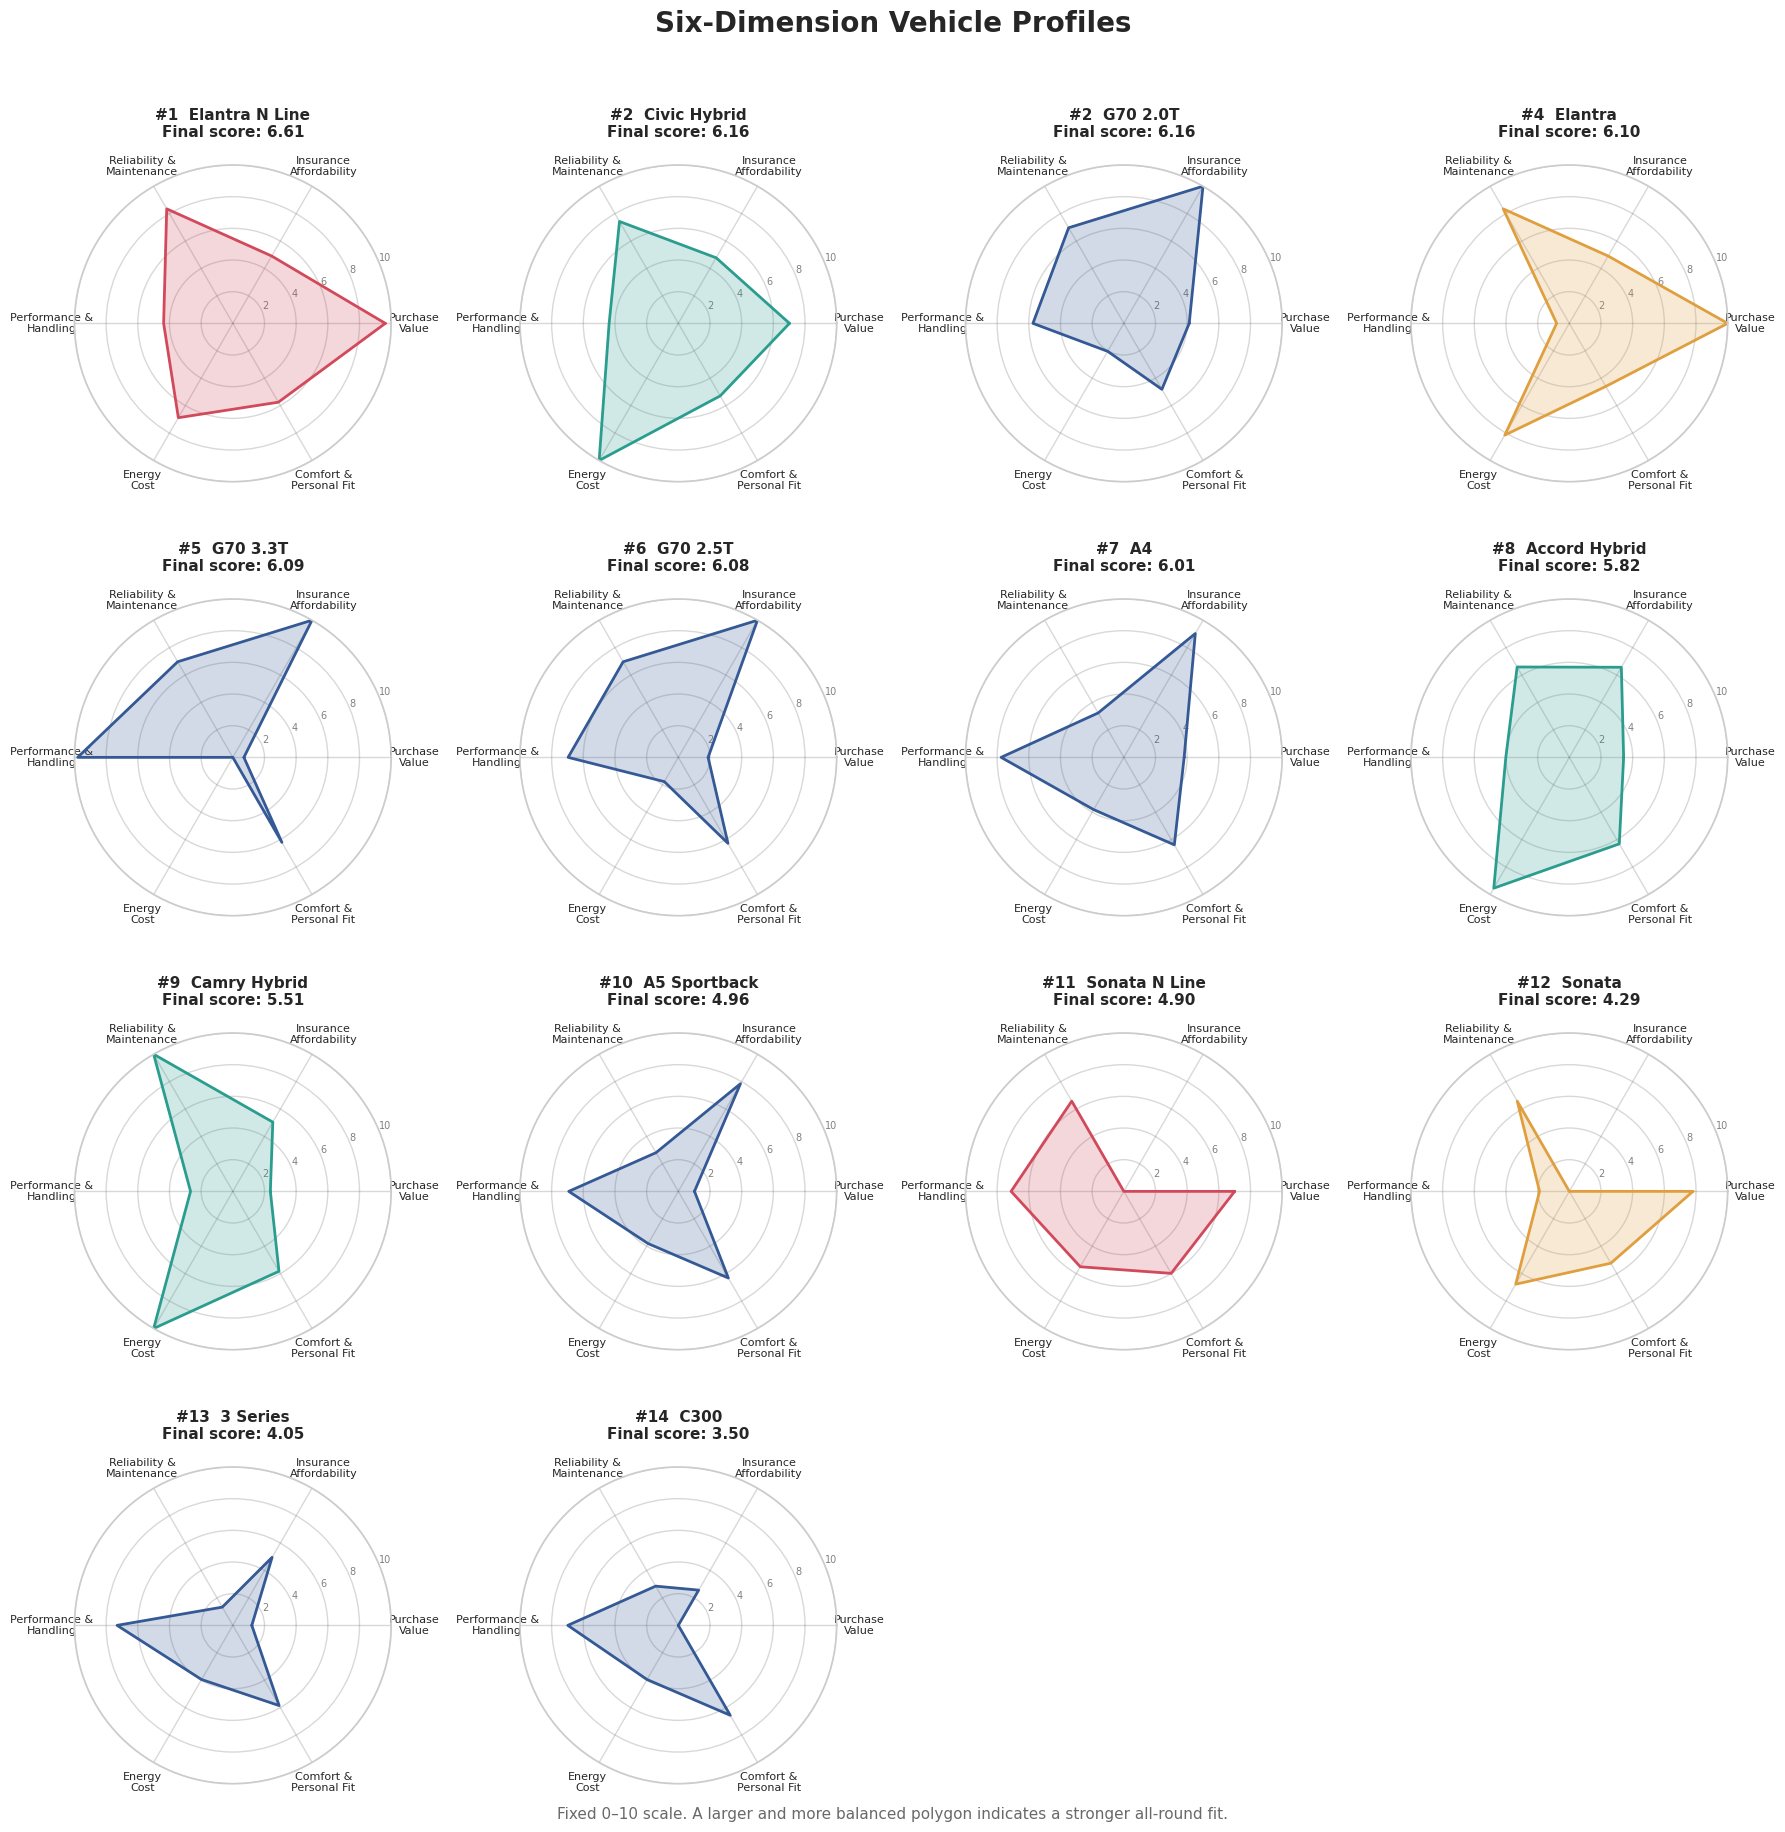

In [ ]:
# ============================================================
# Six-dimension radar charts — all 14 models
#
# Each vehicle receives its own radar chart.
# All charts use the same fixed 0–10 scale.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import math

radar_columns = [
    "purchase_value_score",
    "insurance_affordability_score",
    "reliability_maintenance_score",
    "performance_handling_score",
    "energy_use_cost_score",
    "comfort_personal_fit_score",
]

radar_labels = [
    "Purchase\nValue",
    "Insurance\nAffordability",
    "Reliability &\nMaintenance",
    "Performance &\nHandling",
    "Energy\nCost",
    "Comfort &\nPersonal Fit",
]

# Sort vehicles by final ranking
radar_df = (
    decision_df[
        [
            "analysis_model",
            "final_rank",
            "final_weighted_score",
        ] + radar_columns
    ]
    .sort_values(
        ["final_weighted_score", "analysis_model"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

number_of_axes = len(radar_columns)

angles = np.linspace(
    0,
    2 * np.pi,
    number_of_axes,
    endpoint=False,
).tolist()

# Close the radar polygon
closed_angles = angles + angles[:1]

number_of_models = len(radar_df)
number_of_columns = 4
number_of_rows = math.ceil(number_of_models / number_of_columns)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 18),
    subplot_kw={"polar": True},
)

axes = np.array(axes).flatten()

# Consistent colour by broad vehicle type
def choose_radar_colour(model):
    if model in [
        "3 Series",
        "A4",
        "A5 Sportback",
        "C300",
        "G70 2.0T",
        "G70 2.5T",
        "G70 3.3T",
    ]:
        return "#345995"       # Luxury / sport

    if "Hybrid" in model:
        return "#2A9D8F"       # Hybrid

    if "N Line" in model:
        return "#D1495B"       # N Line

    return "#E09F3E"           # Other mainstream

for axis, (_, row) in zip(axes, radar_df.iterrows()):
    values = row[radar_columns].astype(float).tolist()
    closed_values = values + values[:1]

    colour = choose_radar_colour(row["analysis_model"])

    axis.plot(
        closed_angles,
        closed_values,
        color=colour,
        linewidth=2,
    )

    axis.fill(
        closed_angles,
        closed_values,
        color=colour,
        alpha=0.22,
    )

    axis.set_xticks(angles)
    axis.set_xticklabels(
        radar_labels,
        fontsize=8,
    )

    axis.set_ylim(0, 10)
    axis.set_yticks([2, 4, 6, 8, 10])
    axis.set_yticklabels(
        ["2", "4", "6", "8", "10"],
        fontsize=7,
        color="grey",
    )

    axis.grid(
        color="grey",
        alpha=0.30,
    )

    axis.set_title(
        f'#{int(row["final_rank"])}  {row["analysis_model"]}\n'
        f'Final score: {row["final_weighted_score"]:.2f}',
        fontsize=11,
        fontweight="bold",
        pad=20,
    )

# Hide unused subplot positions
for axis in axes[number_of_models:]:
    axis.set_visible(False)

fig.suptitle(
    "Six-Dimension Vehicle Profiles",
    fontsize=20,
    fontweight="bold",
    y=1.01,
)

fig.text(
    0.5,
    0.005,
    (
        "Fixed 0–10 scale. A larger and more balanced polygon "
        "indicates a stronger all-round fit."
    ),
    ha="center",
    fontsize=11,
    color="dimgray",
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Weight sensitivity analysis
#
# Tests whether the final result changes substantially under
# five reasonable buyer-priority scenarios.
# ============================================================

sensitivity_scenarios = {
    "Current priorities": {
        "purchase_value_score": 0.20,
        "insurance_affordability_score": 0.25,
        "reliability_maintenance_score": 0.15,
        "performance_handling_score": 0.15,
        "energy_use_cost_score": 0.10,
        "comfort_personal_fit_score": 0.15,
    },

    "Cost focused": {
        "purchase_value_score": 0.25,
        "insurance_affordability_score": 0.30,
        "reliability_maintenance_score": 0.15,
        "performance_handling_score": 0.05,
        "energy_use_cost_score": 0.15,
        "comfort_personal_fit_score": 0.10,
    },

    "Performance focused": {
        "purchase_value_score": 0.15,
        "insurance_affordability_score": 0.20,
        "reliability_maintenance_score": 0.10,
        "performance_handling_score": 0.30,
        "energy_use_cost_score": 0.05,
        "comfort_personal_fit_score": 0.20,
    },

    "Comfort focused": {
        "purchase_value_score": 0.15,
        "insurance_affordability_score": 0.20,
        "reliability_maintenance_score": 0.10,
        "performance_handling_score": 0.15,
        "energy_use_cost_score": 0.10,
        "comfort_personal_fit_score": 0.30,
    },

    "Equal weights": {
        "purchase_value_score": 1 / 6,
        "insurance_affordability_score": 1 / 6,
        "reliability_maintenance_score": 1 / 6,
        "performance_handling_score": 1 / 6,
        "energy_use_cost_score": 1 / 6,
        "comfort_personal_fit_score": 1 / 6,
    },
}

# Validate every scenario
for scenario_name, weights in sensitivity_scenarios.items():
    assert np.isclose(sum(weights.values()), 1.0), (
        f"{scenario_name} weights do not add up to 100%."
    )

sensitivity_df = decision_df[
    ["analysis_model"] + radar_columns
].copy()

scenario_score_columns = []
scenario_rank_columns = []

for scenario_name, weights in sensitivity_scenarios.items():
    score_column = f"{scenario_name} score"
    rank_column = f"{scenario_name} rank"

    sensitivity_df[score_column] = sum(
        sensitivity_df[column] * weight
        for column, weight in weights.items()
    ).round(2)

    sensitivity_df[rank_column] = (
        sensitivity_df[score_column]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    scenario_score_columns.append(score_column)
    scenario_rank_columns.append(rank_column)

# Robustness summary
sensitivity_df["average_rank"] = (
    sensitivity_df[scenario_rank_columns].mean(axis=1)
).round(2)

sensitivity_df["best_rank"] = (
    sensitivity_df[scenario_rank_columns].min(axis=1)
)

sensitivity_df["worst_rank"] = (
    sensitivity_df[scenario_rank_columns].max(axis=1)
)

sensitivity_df["rank_range"] = (
    sensitivity_df["worst_rank"]
    - sensitivity_df["best_rank"]
)

# Compact ranking table
sensitivity_ranking_table = (
    sensitivity_df[
        ["analysis_model"]
        + scenario_rank_columns
        + [
            "average_rank",
            "best_rank",
            "worst_rank",
            "rank_range",
        ]
    ]
    .sort_values(
        ["average_rank", "worst_rank"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

sensitivity_ranking_table

,analysis_model,Current priorities rank,Cost focused rank,Performance focused rank,Comfort focused rank,Equal weights rank,average_rank,best_rank,worst_rank,rank_range
0,Elantra N Line,1,1,5,1,1,1.8,1,5,4
1,Civic Hybrid,2,3,6,5,2,3.6,2,6,4
2,A4,7,8,2,2,6,5.0,2,8,6
3,G70 2.0T,2,4,4,7,8,5.0,2,8,6
4,G70 3.3T,5,9,1,3,8,5.2,1,9,8
5,G70 2.5T,6,7,3,4,7,5.4,3,7,4
6,Elantra,4,2,10,8,3,5.4,2,10,8
7,Accord Hybrid,8,5,8,6,4,6.2,4,8,4
8,Camry Hybrid,9,6,12,9,5,8.2,5,12,7
9,A5 Sportback,10,10,7,10,11,9.6,7,11,4


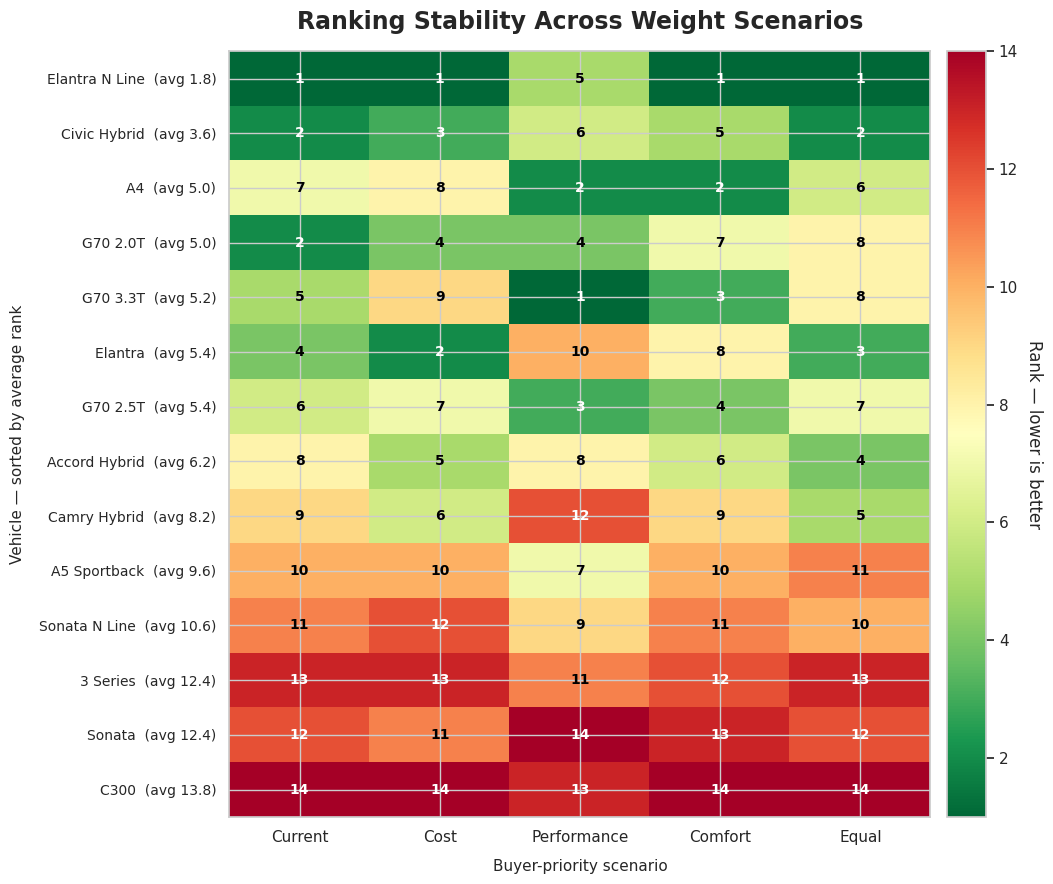

In [ ]:
# ============================================================
# Sensitivity ranking heatmap
# Lower rank = better
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

scenario_display_names = [
    "Current",
    "Cost",
    "Performance",
    "Comfort",
    "Equal",
]

heatmap_rank_columns = [
    "Current priorities rank",
    "Cost focused rank",
    "Performance focused rank",
    "Comfort focused rank",
    "Equal weights rank",
]

heatmap_df = (
    sensitivity_df[
        ["analysis_model", "average_rank"] + heatmap_rank_columns
    ]
    .sort_values(
        ["average_rank", "analysis_model"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

rank_matrix = heatmap_df[heatmap_rank_columns].to_numpy()

fig, axis = plt.subplots(figsize=(11, 9))

# Reverse colour scale so lower ranks appear greener
image = axis.imshow(
    rank_matrix,
    cmap="RdYlGn_r",
    vmin=1,
    vmax=14,
    aspect="auto",
)

axis.set_xticks(np.arange(len(scenario_display_names)))
axis.set_xticklabels(
    scenario_display_names,
    fontsize=11,
)

axis.set_yticks(np.arange(len(heatmap_df)))
axis.set_yticklabels(
    [
        f"{model}  (avg {average_rank:.1f})"
        for model, average_rank
        in zip(
            heatmap_df["analysis_model"],
            heatmap_df["average_rank"],
        )
    ],
    fontsize=10,
)

# Write rank inside every heatmap cell
for row_index in range(rank_matrix.shape[0]):
    for column_index in range(rank_matrix.shape[1]):
        rank_value = int(rank_matrix[row_index, column_index])

        text_colour = (
            "white"
            if rank_value <= 3 or rank_value >= 12
            else "black"
        )

        axis.text(
            column_index,
            row_index,
            str(rank_value),
            ha="center",
            va="center",
            color=text_colour,
            fontsize=10,
            fontweight="bold",
        )

axis.set_title(
    "Ranking Stability Across Weight Scenarios",
    fontsize=17,
    fontweight="bold",
    pad=16,
)

axis.set_xlabel(
    "Buyer-priority scenario",
    fontsize=11,
    labelpad=10,
)

axis.set_ylabel(
    "Vehicle — sorted by average rank",
    fontsize=11,
    labelpad=10,
)

colour_bar = fig.colorbar(
    image,
    ax=axis,
    pad=0.02,
)

colour_bar.set_label(
    "Rank — lower is better",
    rotation=270,
    labelpad=18,
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Final decision summary and CSV export
# ============================================================

dimension_name_map = {
    "purchase_value_score": "Purchase value",
    "insurance_affordability_score": "Insurance affordability",
    "reliability_maintenance_score": "Reliability & maintenance",
    "performance_handling_score": "Performance & handling",
    "energy_use_cost_score": "Energy-use cost",
    "comfort_personal_fit_score": "Comfort & personal fit",
}

vehicle_role_map = {
    "Elantra N Line": "Best robust overall choice",
    "Civic Hybrid": "Best efficiency-focused alternative",
    "G70 2.0T": "Affordable-entry luxury alternative",
    "Elantra": "Budget and operating-cost choice",
    "G70 3.3T": "Maximum-performance emotional choice",
    "G70 2.5T": "Most balanced luxury-performance G70",
    "A4": "Refined premium comfort choice",
    "Accord Hybrid": "Practical and spacious hybrid",
    "Camry Hybrid": "Reliability and efficiency specialist",
    "A5 Sportback": "Design-led premium choice",
    "Sonata N Line": "Emotional choice with insurance penalty",
    "Sonata": "Practical car with weak insurance fit",
    "3 Series": "Sporty premium choice with ownership trade-offs",
    "C300": "Comfortable luxury choice with poor overall value fit",
}

# Extract strongest and weakest two dimensions automatically
def identify_dimensions(row, highest=True):
    scores = {
        display_name: row[column]
        for column, display_name in dimension_name_map.items()
    }

    sorted_scores = sorted(
        scores.items(),
        key=lambda item: item[1],
        reverse=highest,
    )

    return "; ".join(
        f"{name} ({score:.2f})"
        for name, score in sorted_scores[:2]
    )

# Prepare robustness information
robustness_columns = sensitivity_df[
    [
        "analysis_model",
        "average_rank",
        "best_rank",
        "worst_rank",
        "rank_range",
    ]
].copy()

final_decision_summary = decision_df[
    [
        "analysis_model",
        "final_rank",
        "final_weighted_score",
    ] + list(dimension_name_map.keys())
].copy()

final_decision_summary = final_decision_summary.merge(
    robustness_columns,
    on="analysis_model",
    how="left",
    validate="one_to_one",
)

final_decision_summary["decision_role"] = (
    final_decision_summary["analysis_model"].map(vehicle_role_map)
)

final_decision_summary["strongest_dimensions"] = (
    final_decision_summary.apply(
        lambda row: identify_dimensions(row, highest=True),
        axis=1,
    )
)

final_decision_summary["weakest_dimensions"] = (
    final_decision_summary.apply(
        lambda row: identify_dimensions(row, highest=False),
        axis=1,
    )
)

# Robustness classification considers both average position
# and the worst position across all five scenarios.
def classify_robustness(row):
    if row["average_rank"] <= 4 and row["worst_rank"] <= 6:
        return "Robust leading choice"

    if row["average_rank"] <= 7 and row["worst_rank"] <= 9:
        return "Competitive but priority-sensitive"

    if row["average_rank"] <= 10:
        return "Conditional / niche choice"

    return "Consistently low overall fit"

final_decision_summary["robustness_assessment"] = (
    final_decision_summary.apply(
        classify_robustness,
        axis=1,
    )
)

# Sort by the original current-priority score
final_decision_summary = (
    final_decision_summary.sort_values(
        ["final_weighted_score", "analysis_model"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

# Display a readable conclusion table
display_columns = [
    "final_rank",
    "analysis_model",
    "final_weighted_score",
    "average_rank",
    "best_rank",
    "worst_rank",
    "robustness_assessment",
    "decision_role",
    "strongest_dimensions",
    "weakest_dimensions",
]

print("Final decision summary:")
display(
    final_decision_summary[display_columns].round(2)
)

# ------------------------------------------------------------
# Export results
# ------------------------------------------------------------

final_decision_summary.to_csv(
    "final_vehicle_decision_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

decision_df[
    ["analysis_model"]
    + list(dimension_name_map.keys())
    + ["final_weighted_score", "final_rank"]
].sort_values(
    "final_weighted_score",
    ascending=False,
).to_csv(
    "six_dimension_vehicle_scores.csv",
    index=False,
    encoding="utf-8-sig",
)

sensitivity_ranking_table.to_csv(
    "weight_sensitivity_analysis.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nExport completed:")
print("1. final_vehicle_decision_summary.csv")
print("2. six_dimension_vehicle_scores.csv")
print("3. weight_sensitivity_analysis.csv")

Final decision summary:


,final_rank,analysis_model,final_weighted_score,average_rank,best_rank,worst_rank,robustness_assessment,decision_role,strongest_dimensions,weakest_dimensions
0,1,Elantra N Line,6.61,1.8,1,5,Robust leading choice,Best robust overall choice,Purchase value (9.63); Reliability & maintenan...,Performance & handling (4.37); Insurance affor...
1,2,Civic Hybrid,6.16,3.6,2,6,Robust leading choice,Best efficiency-focused alternative,Energy-use cost (10.00); Reliability & mainten...,Performance & handling (4.37); Insurance affor...
2,2,G70 2.0T,6.16,5.0,2,8,Competitive but priority-sensitive,Affordable-entry luxury alternative,Insurance affordability (10.00); Reliability &...,Energy-use cost (2.04); Purchase value (4.13)
3,4,Elantra,6.10,5.4,2,10,Conditional / niche choice,Budget and operating-cost choice,Purchase value (10.00); Reliability & maintena...,Performance & handling (0.80); Comfort & perso...
4,5,G70 3.3T,6.09,5.2,1,9,Competitive but priority-sensitive,Maximum-performance emotional choice,Insurance affordability (10.00); Performance &...,Energy-use cost (0.00); Purchase value (0.70)
5,6,G70 2.5T,6.08,5.4,3,7,Competitive but priority-sensitive,Most balanced luxury-performance G70,Insurance affordability (10.00); Reliability &...,Energy-use cost (1.77); Purchase value (1.88)
6,7,A4,6.01,5.0,2,8,Competitive but priority-sensitive,Refined premium comfort choice,Insurance affordability (9.03); Performance & ...,Reliability & maintenance (3.24); Purchase val...
7,8,Accord Hybrid,5.82,6.2,4,8,Competitive but priority-sensitive,Practical and spacious hybrid,Energy-use cost (9.54); Reliability & maintena...,Purchase value (3.43); Performance & handling ...
8,9,Camry Hybrid,5.51,8.2,5,12,Conditional / niche choice,Reliability and efficiency specialist,Reliability & maintenance (10.00); Energy-use ...,Purchase value (2.37); Performance & handling ...
9,10,A5 Sportback,4.96,9.6,7,11,Conditional / niche choice,Design-led premium choice,Insurance affordability (7.85); Performance & ...,Purchase value (1.02); Reliability & maintenan...



Export completed:
1. final_vehicle_decision_summary.csv
2. six_dimension_vehicle_scores.csv
3. weight_sensitivity_analysis.csv
